# Welcome to Infrastructure Planning HS2026!

Welcome to the central in-class case study for Infrastructure Planning! 

While your group project focuses on different spatial and transport corridors, this notebook introduces the SBB MehrSpur Zürich–Winterthur rail project as our primary, fully coded guide. 

Throughout the course, we will use this notebook to demonstrate how to structure, model, and appraise a complex infrastructure expansion step-by-step in Python. You will see how macroscopic (4-step) transport modeling, Monte Carlo simulation and cost-benefit analysis, are directly implemented. 

Use this notebook as a reference template before working on your own group exercise assignments.

# Context

The Zürich–Winterthur corridor is a central rail bottleneck connecting Zurich, Airport/Glattal, and Winterthur for regional, long-distance, and freight transport. To expand capacity and reduce waiting times toward a 15-minute service frequency on the S-Bahn, SBB is implementing the MehrSpur project, comprising the ~8.3 km Brütten tunnel and major station upgrades. The planning question focuses on how to stage different intervention packages across a 40-year planning horizon.

---

# 02 — System model, infrastructure interventions, and plans

This notebook demonstrates how the transport model, infrastructure interventions and plans (i.e., portfolios of interventions) are implemented for the SBB MehrSpur case study. The notebook serves as a demonstrative tutorial, which you should adapt to your own case study.

As mentioned in the exercise sheets, you will be presented with different types of calculations and tasks:
- **Tutorials/Supporting task (optional):** building understanding, and not meant to be a report deliverable.
- **Mandatory/Expected task:** producing a definition, assumption, or result needed later in the project or as part of the final deliverable.
- **Advanced task (optional):** extends the model beyond the supplied example to develop additional analyses.


## Main learning objectives (see the marked tasks below)

In this notebook, we will focus primarily on:

1. understanding the underlying transport simulation by defining and inspecting its network, calculating OD matrices, modal split and traffic assignment.
2. identifying the parameters that control travel demand, mode choice, physical indicators, benefits and costs.
3. defining infrastructure stages and their impacts, visualize such modifications on the transport network.
4. defining simple static plans for deploying portfolios of interventions (staged or not) and visualise their evolution over time.


## Estimated time for Notebook 02

> - **Execution time:** the complete transport simulations for this example take several minutes to execute. Notebook 03 trains a surrogate model and prepares a response table for the analysis in subsequent notebooks so that the simulations do not have to be re-executed every time. The optional sensitivity sweep has its own execution flag.
> - **Reading and understanding:** allow approximately **1-2 hours** to work through this notebook example (this does not include time you may spend adapting it to your own case study project).
> - **Case-study adaptation:** significant additional time will be required for editing assumptions, implementing changes, validating results, and documenting decisions.
>
> Plan your work accordingly. Execution time does not include time spent reading, interpreting results, troubleshooting, or modifying the notebook.

## Scope

This notebook focuses on deterministic analysis, meaning that we do not analyse the performance of plans under uncertainty or potential future scenarios here. Indicators are used to evaluate outcomes. We use fixed nominal assumptions and inspect two snapshots in the simulation time horizon: Year 1 (establishing baseline conditions) and Year 40 (comparing indicators given different alternative plans). The plans describe when different infrastructure stages would be deployed.

## Setup

Static figures and full result tables save automatically to `figures/02_system_modeling/` (PNG) and `results/02_system_modeling/` (CSV), including those produced by dashboards. Reruns overwrite the same filenames. Set `SAVE_OUTPUTS = False` in Setup and rerun it to disable exports. Interactive widgets and maps themselves are not exported.

Use the supplied Python 3.11 / NumPy 1.26 environment. Run this notebook from the repository root or the `notebooks` folder.

**After saving changes to `parameters.py`, `stages.py`, `adaptive_planning.py` or model scripts: restart the kernel and Run All.** This loads one consistent configuration and discards old results. Slider experiments and provisional map edits stay in the current kernel; use their Run buttons and the indicated comparison cells. Save any provisional edits you want to keep before restarting.

The setup cell uses the installed environment. Set `INSTALL_REQUIREMENTS = True` only when installing dependencies, then restart the kernel and return the flag to `False`.

**If a dashboard stops responding:** first check whether the kernel is busy with another calculation, then use the dashboard's Refresh control. If the kernel is idle but the view stays blank, rerun that dashboard's cell. Recreating the Section 3.2 editor discards provisional edits; save them first, or recreate only its comparison view. Restart the kernel and Run All if the kernel has died or a fresh dashboard still fails. A restart discards unsaved working edits.


In [1]:
import sys
import os
import time
from pathlib import Path

from IPython.display import HTML, display

# Install dependencies only when preparing the environment.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INSTALL_REQUIREMENTS = False
if INSTALL_REQUIREMENTS:
    %pip install --quiet -r "$PROJECT_ROOT/requirements.txt"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lonboard
from joblib import Parallel, delayed

# 1. Set up project directories
CODE_DIR = PROJECT_ROOT / "code"
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

# 2. Import project modules
import parameters as p
import stages as stages_module
import simulation_engine as m
import transport_model_interface as tmi
import adaptive_planning
from additional import uncertainty as uc
from additional import notebook_exports as exports
from parameters import N_YEARS, DISCOUNT_RATE

# Notebook configuration
SAVE_OUTPUTS = True
exports.configure(PROJECT_ROOT, "02_system_modeling", enabled=SAVE_OUTPUTS)
_NB_START = time.perf_counter()
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)


# Part 1 — How the system model works

## 1.1 What are we modelling? (tutorial/supporting task)

The **transport model** represents the transport system of the Canton of Zürich and is used to evaluate the performance of alternative strategic plans.

The model represents travel demand during the evening peak hour (17:00–18:00) within the Canton of Zürich, using 1,223 spatial zones based on the Swiss National Model (NPVM). In our in-class example, we reduce the geographical extension to a cordon that focuses on our study area, i.e. the Zürich–Winterthur corridor. 

The model is based in the traditional four-step transport modelling framework, comprising trip generation, trip distribution, mode choice, and traffic assignment. Even though, in this course, only the last 2 steps are run. Trip generation and distribution are largely based on the NPVM Origin-Destination (OD) matrices.

In this model, travellers choose among **five modes**: Car, PT with walk access, PT with bicycle access, Bicycle, and Walk. Throughout this analysis, **PT** refers collectively to the two public transport alternatives: PT accessed on foot and PT accessed by bicycle.

For each OD pair, the model answers:

1. How much travel demand needs to be served?
2. How attractive are the available modes (Car, PT with walk access, PT with bicycle access, Bicycle, Walk) based on estimated network travel times?
3. What share of travel demand is taken using which mode?
4. What transport indicators, capacity constraints, and societal costs follow from these choices?

The main components are:

| Component | Representation | Main output |
|---|---|---|
| Network | [Prepared road network, nodes and connectors](../code/transport_model_interface.py) | Route topology and link attributes |
| Travel demand | [Prepared peak-hour OD demand for the 1,223 model zones](../code/transport_core/zoning.py) | Demand by OD pair |
| Mode attractiveness/disutility | [Mode-specific travel time and distance skims](../code/transport_core/travel_times.py) | Utility by mode and OD pair |
| Mode choice | [Multinomial-logit mode choice](../code/transport_core/mode_choice_zurich.py) | Car, PT with walk access, PT with bicycle access, Bicycle, and Walk modal split |
| Car traffic assignment | [Coupled MSA assignment and mode-choice feedback](../code/transport_model_interface.py) | Traffic volume, V/C (the volume-to-capacity ratio, which represents congestion), and congested time by road link |
| Infrastructure interventions/stages | [Package definitions](../code/stages.py) and [intervention application](../code/transport_core/interventions.py) | Changed modal split, assignment and physical indicators |
| Impact calculation | [Annual physical indicators](../code/simulation_engine.py) and [annual societal costs](../code/simulation_engine.py) | Annual societal costs |

Simply put, a model run is structured as follows: travel demand is split into multiple transport modes, roads get slower under congestion, and slower car travel can then change the original mode choices.

1. **Travel demand, travel times, and interventions.** Spatial travel demand indicates how much demand goes from each origin to each destination. A *skim* is the corresponding travel time skim or distance skim between every OD pair, for one mode. Interventions, such as a rail upgrade, make some modes faster or more convenient.
2. **Split travel demand across modes.** Those times and other costs and considerations are turned into utilities (how attractive each option is to a traveler). A multinomial logit model allocates travel demand to Car, PT with walk access, PT with bicycle access, Bicycle, and Walk.
3. **Assign cars to roads.** The initial *car traffic assignment* answers only *which routes* car travel demand uses based on free-flow travel times, and it estimates the traffic volume on each link. It does not yet say how slow those links have become from the traffic on those links.
4. **Turn congestion into congested time.** The Bureau of Public Roads (BPR) formula converts each link's traffic volume into a congested travel time: a busier road, relative to its capacity, takes longer. Congested travel time includes free-flow time; the difference is road delay. V/C is the volume-to-capacity ratio.
5. **Update car travel time skims.** Adding the congested times along each used route produces *updated car travel time skims* that now consider congestion.
6. **Repeat mode choice and assignment.** If driving has become slower, some people switch to other modes. Fewer (or more) cars then change car traffic assignment and congestion again. The model therefore loops through mode choice → car traffic assignment → BPR congested time → updated car travel time skims → mode choice.
7. **Estimate intervention impacts.** The loop stops at the configured road-relative-gap threshold or iteration limit. Physical and societal indicators are then calculated; the road gap does not independently test modal-share convergence.

The loop in step 6 is an important feedback: congestion can change modal split, which in turn can change congestion. Later in this notebook a first dashboard holds car travel demand fixed, so you can inspect car traffic assignment and congested time on their own. A second dashboard then closes the loop and lets congestion feed back into mode choice, which is how the main simulation works.

This notebook compares deterministic nominal Year-1 and Year-40 snapshots. Uncertainty scenarios and annual plan appraisal follow in later notebooks.

For more detailed technical documentation about the model:

- To understand how the MehrSpur simulation and 40-year plans work go to [`code/README.md`](../code/README.md)
- Read the [transport-core guide](../code/transport_core/README.md) for the shared model components and input files. Passenger-demand changes multiply every baseline OD cell equally; mode choice and congestion then respond to the changed load.

The [Phase 2 exercise folder](../docs/phase-2-system-modeling/) contains the released exercise sheet. The marked tasks below support the notebook exercises.


## 1.2 Input Data and Simulation Setup (tutorial/supporting task)

This section verifies that all required input datasets (FSM zone definitions, baseline travel time skims, travel distance skims, and peak-hour travel demand) are properly loaded.

### Structure of the Transport Model in this Notebook
* **Multimodal Mode Choice:** Evaluates travel choices across five alternatives (*Car*, *Walk*, *Bicycle*, *PT with walk access*, and *PT with bicycle access*) using a calibrated Multinomial Logit model. **PT** indicates two public-transport alternatives: PT with walk access and PT with bicycle access.
* **Corridor Extraction:** Filters Canton-wide matrices to travel demand within and intersecting the Zürich–Winterthur corridor to calculate physical indicators (travel demand, modal split, vehicle-kilometers, travel times, and $\text{CO}_2$ emissions).
* **Infrastructure Interventions:** Represents project stages by applying targeted percentage changes to baseline travel times, waiting times, and transfer time as specified in `stages.py`.


In [2]:
# 1. Check data readiness
transport_status = tmi.transport_input_status(PROJECT_ROOT)
TRANSPORT_FLAGS = tmi.readiness_flags(transport_status)

exports.save_outputs("1_2_transport_readiness", tables={"": transport_status})
display(transport_status)
display(HTML(tmi.readiness_message(transport_status)))

# 2. Load the transport context
ctx = None
TRANSPORT_LOAD_ERROR = None

if TRANSPORT_FLAGS["mode_choice"]:
    try:
        ctx = tmi.load_transport_context(PROJECT_ROOT, allow_missing_detailed_network=True)
    except Exception as error:
        TRANSPORT_LOAD_ERROR = f"{type(error).__name__}: {error}"
        display(HTML(
            "<div style='padding:10px;border-left:5px solid #b71c1c;background:#ffebee'>"
            "<b>The files exist, but the transport model could not load them:</b><br>"
            f"<code>{TRANSPORT_LOAD_ERROR}</code>"
            "</div>"
        ))
else:
    display(HTML(
        "<div style='padding:10px;border-left:5px solid #c47f00;background:#fff8e1'>"
        "<b>Cannot load model:</b> Required input files are missing from <code>data/transport/prepared/</code>."
        "</div>"
    ))


,item,required,present,relative_path,purpose
0,Zones,True,True,data\transport\prepared\zones.parquet,Spatial zones & attributes
1,Passenger & Background Demand,True,True,data\transport\prepared\demand.pkl.gz,OD matrices
2,Multimodal Skims,True,True,data\transport\prepared\skims.pkl.gz,Travel times & distances
3,Intervention Lookups,True,True,data\transport\prepared\lookups.pkl.gz,Municipality and stop selectors
4,Road Network,True,True,data\transport\prepared\assignment_network.pkl,Road links and nodes
5,Mode-choice Parameters,True,True,data\transport\config\mode_choice.json,Logit coefficients


[OK] Automatically loaded detailed corridor network from limmattal_erweitert_detailed_network.pkl


## 1.3 Corridor & Road Network Setup (tutorial/supporting task + mandatory task)

This map shows the **motor-vehicle assignment network** at the cantonal scale before traffic assignment. The background map also shows paths and restricted roads that cars cannot use, so some visible gaps are intentional.

You can select a link characteristic from the dropdown menu and inspect it. Useful distinctions:

- free-flow time is the time before congestion.
- directional capacity is an hourly link property, not the assigned traffic volume.
- lanes, speed and road class describe supply.
- no route choice, BPR congested time or equilibrium calculation has run yet.


In [3]:
FULL_NETWORK_MAP = None
FULL_NETWORK_MAP_ERROR = None

if ctx is not None:
    try:
        FULL_NETWORK_MAP = tmi.full_network_explorer(ctx)

        if FULL_NETWORK_MAP is not None:
            display(FULL_NETWORK_MAP)
        else:
            display(HTML(
                "<div style='padding:10px;border-left:5px solid #c47f00;"
                "background:#fff8e1'>"
                "<b>Full-network map unavailable.</b><br>"
                "The transport context was loaded, but the map function "
                "did not return a visualization."
                "</div>"
            ))

    except Exception as error:
        FULL_NETWORK_MAP_ERROR = f"{type(error).__name__}: {error}"

        display(HTML(
            "<div style='padding:10px;border-left:5px solid #b71c1c;"
            "background:#ffebee'>"
            "<b>The transport context loaded successfully, but the "
            "full-network map could not be created.</b><br>"
            f"<code>{FULL_NETWORK_MAP_ERROR}</code><br><br>"
            "Check that the geospatial and visualization dependencies "
            "(including <code>geopandas</code>, <code>lonboard</code>, and "
            "<code>ipywidgets</code>) are installed in the active notebook kernel."
            "</div>"
        ))

else:
    reason = (
        TRANSPORT_LOAD_ERROR
        if TRANSPORT_LOAD_ERROR is not None
        else "The transport context is not available."
    )

    display(HTML(
        "<div style='padding:10px;border-left:5px solid #c47f00;"
        "background:#fff8e1'>"
        "<b>Full-network map skipped.</b><br>"
        "Complete the transport-model preflight and resolve the loading "
        "problem before running this cell.<br>"
        f"<code>{reason}</code>"
        "</div>"
    ))

We've now seen the network at the cantonal level. However, we want to reduce it so that it fits our specific area of interest. This allows for faster computation, at the cost of some simplifications.

In this example, we only simulate traffic along the **MehrSpur corridor** (Zürich–Winterthur) instead of the entire Canton of Zürich road network. This is to keep the traffic assignment fast and responsive. We therefore clip the network to the MehrSpur core municipalities plus the configured 500 m spatial buffer.

**You are now expected to define a road network for your specific case study area.**

**IMPORTANT: clipping the network by selecting the interested Municipalities is just ONE way of reducing the road network. You can attempt more advanced approaches that further simplify the network, given your infrastructure interventions** 

This clipped boundary is called a **cordon**. Routing can retain existing road links outside that boundary to connect internal zones; this does not extend the passenger-demand boundary. Reporting includes trips with at least one endpoint in the buffered corridor, unless a table explicitly identifies another scope. To handle travel demand that starts or ends outside the cordon, the model identifies boundary crossings and selects direction-compatible **gates** (entry and exit points), using road capacity, a configured minimum separation, and a maximum gate count.

The Canton-wide travel demand (i.e. the OD pairs) is then simplified into four categories:
1. **Internal → Internal**: Travel demand entirely within the MehrSpur corridor.
2. **Gate → Internal**: Inbound travel demand entering the corridor from the rest of the Canton.
3. **Internal → Gate**: Outbound travel demand leaving the corridor.
4. **Gate → Gate**: Pass-through traffic crossing the corridor (using the assumed 5% pass-through share).

Enhancing network for Limmattal_zurich...
[OK] Reusing detailed corridor network from limmattal_erweitert_detailed_network.pkl


c:\Users\janik\IP-HS26-BikeHighway-jmx\code\transport_model_interface.py:1764: UserWarning: Limmattal_zurich cordon: excluded 21 disconnected boundary candidates and 42 unreachable entry/exit directions. Retained 59 additional existing links to connect internal zone anchors. See corridor.metadata for the affected node and zone IDs.
  return build_corridor_context(context, name=project_name, **kwargs)


Reporting scope: 416 zones in the buffered corridor.
  • Calculating the Stage 0 (Stage 0 – Baseline Network) baseline modal split with the reference travel time skims...

✅ Stage 0 baseline modal split calculated successfully!


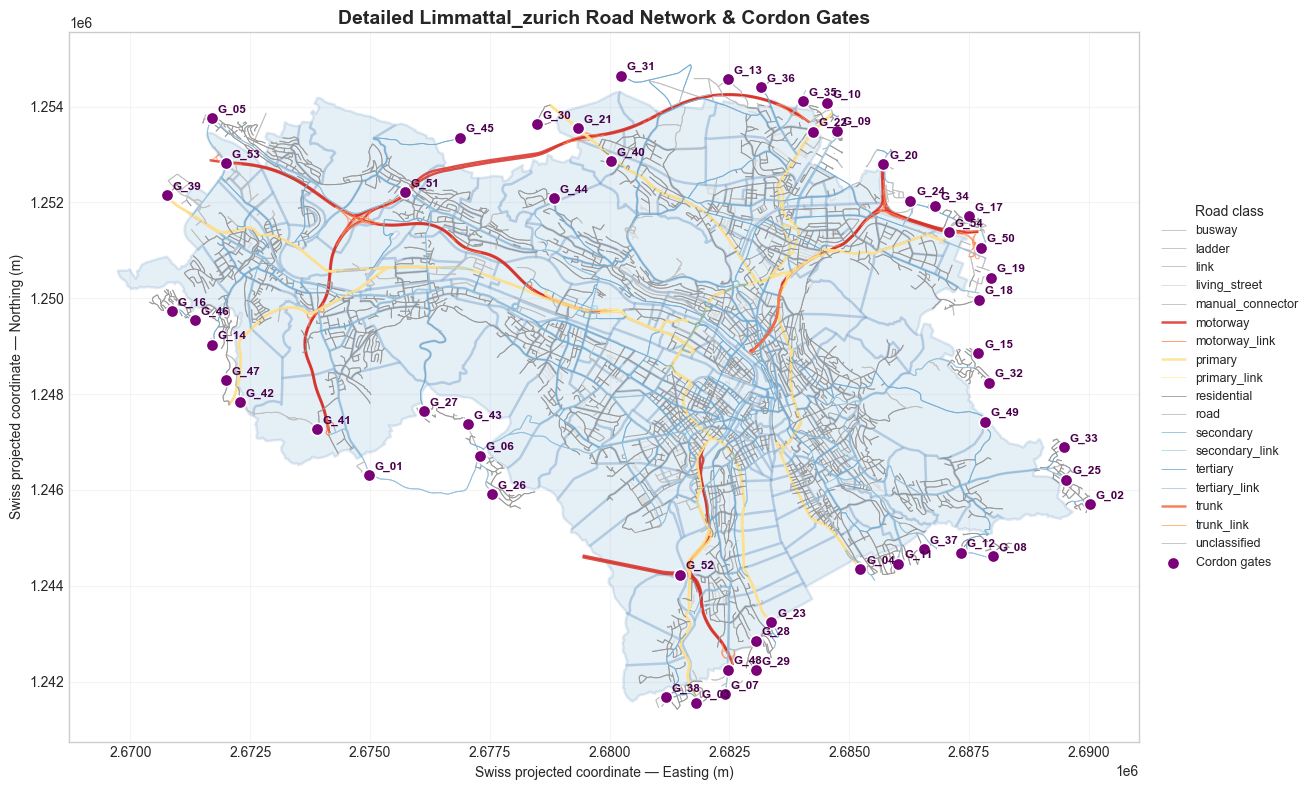

In [4]:
# Gates sind vor allem in Stadt Zürich. Das interessiert uns ja nicht so sehr. --> Entweder Gates mehr im Limmattal fokussieren oder Stadt aufteilen.

# 1. Enhance the baseline network with high-detail OpenStreetMap roads
project_name = "Limmattal_zurich"
corridor_municipalities = p.CORRIDOR_MUNICIPALITIES
cache_file = tmi.configured_detailed_network_path(PROJECT_ROOT, must_exist=False)
if cache_file is None:
    cache_file = PROJECT_ROOT / "data" / "processed" / f"{project_name.lower()}_detailed_network.pkl"

if ctx is None:
    raise RuntimeError(
        "The transport context is not available. "
        "Complete the transport-model preflight before running this cell."
    )

print(f"Enhancing network for {project_name}...")

# Use the cached detailed network when available.
# Set the flag below to True only to download and rebuild the detailed roads.
tmi.ASSIGNMENT_SETTINGS["force_regenerate_corridor_network"] = False

ctx = tmi.load_detailed_corridor_network(
    ctx,
    corridor_municipalities=corridor_municipalities,
    cache_path=cache_file,
    allow_download=True,
)

# Build the corridor context used by maps, gates, and diagnostic tables.
MEHRSPUR = tmi.build_corridor(
    ctx,
    project_name,
    corridor_municipalities=corridor_municipalities,
    max_gates=40,
    gate_separation_m=500.0,
)

# Shared road-relative-gap settings for all native calculations below.
ASSIGNMENT_OPTIONS = tmi.resolve_assignment_settings()


# 2. Run Baseline Simulation (Stage 0 only) we will look at the "stages" 
# in more detail in later parts of this notebook. For now, just consider 
# "Stage 0" as the current baseline network with no additional infrastructure 
# or policy interventions. 
# Car traffic assignment is introduced separately below, first with fixed demand
# and then with congestion-to-mode-choice feedback.
stages = stages_module.get_stages(p.NOMINAL_PARAMS)
corridor_zones = list(MEHRSPUR.zone_ids)
print(f"Reporting scope: {len(corridor_zones)} zones in the buffered corridor.")


print(
    f"  • Calculating the Stage 0 ({stages[0]['name']}) "
    "baseline modal split with the reference travel time skims..."
)

res_stage0 = tmi.run_transport_mode_choice(
    ctx,
    stage=0,
    stage_specs=stages,
    corridor_zone_ids=corridor_zones,
)
metrics_stage0 = tmi.extract_corridor_metrics(
    ctx, res_stage0, corridor_zone_ids=corridor_zones
)

print("\n✅ Stage 0 baseline modal split calculated successfully!")


# 3. Visualize the Cordon, Road Network, and Gates (Stage 0 Baseline)
if res_stage0 is not None:
    # Interactive WebGL dashboard:
    # map, selectable road attributes, gates, network detail, and OD summaries.
    MEHRSPUR_DASHBOARD = tmi.corridor_dashboard(
        ctx,
        MEHRSPUR,
        demand_matrix=res_stage0.drive_od,
    )
    display(MEHRSPUR_DASHBOARD)

    # Static Stage 0 network plot.
    tmi.static_network_plot(
        context=ctx,
        mode_result=res_stage0,
        corridor_municipalities=corridor_municipalities,
        project_name=project_name,
    )
else:
    display(HTML(
        "<div style='padding:10px;border-left:5px solid #c47f00;"
        "background:#fff8e1'>"
        "<b>Baseline visualization skipped.</b><br>"
        "The Stage 0 simulation did not return a result."
        "</div>"
    ))

### Cordon gates

Candidate gates occur at road crossings of the cordon boundary. Selection filters disconnected candidates and unreachable entry/exit directions, then uses capacity, spacing and a maximum count. Zone connectors are excluded from gate candidates. External demand is allocated to the nearest direction-compatible gate.

The table below checks boundary coverage, retained demand and gate concentration. Stable demand totals alone do not establish stable congestion: internal, inbound and outbound demand are preserved by construction. Inspect whether the important boundary roads are represented. The unrestricted option includes all eligible candidates, rather than all raw candidates before connectivity filtering.


In [5]:
# Inspect gate coverage and demand concentration

GATE_CONFIGURATIONS = [
    {"max_gates": 15, "gate_separation_m": 1000.0},
    {"max_gates": 30, "gate_separation_m": 800.0},
    {"max_gates": 40, "gate_separation_m": 500.0},
    {"max_gates": 100, "gate_separation_m": 500.0},
    {"max_gates": 10_000, "gate_separation_m": 0.0},  # all candidate nodes
]

gate_test_rows = []
gate_test_contexts = {}

for config in GATE_CONFIGURATIONS:
    corridor = tmi.build_corridor(
        ctx,
        project_name,
        corridor_municipalities=corridor_municipalities,
        max_gates=config["max_gates"],
        gate_separation_m=config["gate_separation_m"],
    )

    reduced_od, breakdown = tmi.collapse_od_to_gates(
        ctx.baseline_od,
        ctx,
        corridor,
    )

    totals = tmi.gate_totals(reduced_od, corridor)
    total_gate_demand = totals["cordon_total"].sum()

    gate_test_rows.append({
        "max_gates": config["max_gates"],
        "separation_m": config["gate_separation_m"],
        "candidate_nodes": corridor.metadata["candidate_boundary_nodes"],
        "selected_gates": corridor.metadata["selected_gates"],
        "entry_gates": corridor.metadata["entry_gates"],
        "exit_gates": corridor.metadata["exit_gates"],
        "retained_trips: % of total cantonal trips": round(100.0* reduced_od.to_numpy(dtype=float).sum()
                                  / max(ctx.baseline_od.to_numpy(dtype=float).sum(), 1e-9),2,), 
                                  "largest_gate_share": (
            totals["cordon_total"].max() / total_gate_demand
            if total_gate_demand > 0
            else 0.0
        ),
        "manual_connector_gates": (
            corridor.gates["highway"]
            .astype(str)
            .eq("manual_connector")
            .sum()
        ),
    })

    gate_test_contexts[
        (config["max_gates"], config["gate_separation_m"])
    ] = corridor

GATE_SENSITIVITY = pd.DataFrame(gate_test_rows)
exports.save_outputs("1_3_gate_sensitivity", tables={"": GATE_SENSITIVITY})
display(GATE_SENSITIVITY)

c:\Users\janik\IP-HS26-BikeHighway-jmx\code\transport_model_interface.py:1764: UserWarning: Limmattal_zurich cordon: excluded 21 disconnected boundary candidates and 42 unreachable entry/exit directions. Retained 59 additional existing links to connect internal zone anchors. See corridor.metadata for the affected node and zone IDs.
  return build_corridor_context(context, name=project_name, **kwargs)
c:\Users\janik\IP-HS26-BikeHighway-jmx\code\transport_model_interface.py:1764: UserWarning: Limmattal_zurich cordon: excluded 21 disconnected boundary candidates and 42 unreachable entry/exit directions. Retained 59 additional existing links to connect internal zone anchors. See corridor.metadata for the affected node and zone IDs.
  return build_corridor_context(context, name=project_name, **kwargs)
c:\Users\janik\IP-HS26-BikeHighway-jmx\code\transport_model_interface.py:1764: UserWarning: Limmattal_zurich cordon: excluded 21 disconnected boundary candidates and 42 unreachable entry/exit 

,max_gates,separation_m,candidate_nodes,selected_gates,entry_gates,exit_gates,retained_trips: % of total cantonal trips,largest_gate_share,manual_connector_gates
0,15,1000.0,170,15,11,12,49.24,0.184874,0
1,30,800.0,170,30,26,27,49.31,0.151897,0
2,40,500.0,170,40,35,35,49.40,0.134561,0
3,100,500.0,170,51,46,46,49.47,0.133993,0
4,10000,0.0,170,149,129,131,49.41,0.090143,0


If the boundary representation needs adjustment, edit the gate-creation settings in `code/transport_model_interface.py`, save, restart the kernel and Run All. The following map displays all eligible gate candidates.


In [6]:
ALL_GATE_CANDIDATES = gate_test_contexts[(100, 500.0)]
display(tmi.corridor_explorer(ALL_GATE_CANDIDATES))

# Variante mit 40 Gates
display(tmi.corridor_explorer(gate_test_contexts[(40, 500.0)]))


## 1.4 Baseline Travel Demand & Desire Lines (tutorial/supporting task + mandatory task)

To understand where people travel along the Zürich–Winterthur corridor, we visualize **desire lines**  and **OD-matrices** at various levels of spatial resolution. 

Below, for instance, you can visualize how travel demand is distributed if we aggregate it by Municipality and therefore see which ones exhibit the strongest demand.

> **OD-inspection and model validation**
>
> The following analyses help assess whether the model produces plausible travel patterns before its outputs are used in later stages. Compare internal, inbound, outbound, and pass-through demand with independent evidence, such as observed transport data, official statistics, previous studies, CBA assumptions, or projects from earlier course editions.
>

**IMPORTANT: these values represent peak-hour evening travel demand in the Canton of Zurich, i.e. only travel demand on a "regular" weekday between 17:00-18:00**

Here below, you can start inspecting the data by analysing the travel demand between pairs of municipalities (i.e., OD pairs).

In [7]:
MUNICIPALITY_OD_FIGURE = tmi.municipality_od_explorer(
    ctx,
    p.CORRIDOR_MUNICIPALITIES,
)

display(MUNICIPALITY_OD_FIGURE)

#### Desire-line map

The desire-line map shows the spatial relationship between origins and destinations. Desire lines are not routes that go through the road network. They show where demand originates and ends but not which roads travellers use.

The category and flow-range controls can be used to focus on specific movements. For browser performance, only the largest selected flows are displayed. This visualization limit does not remove travel demand from the OD matrix or from the transport simulation.

In this case below, centroids of municipal polygons are used as references for connecting desire lines.

In [8]:
MUNICIPALITY_FLOW_MAP = tmi.municipality_flow_map_explorer(
    ctx,
    p.CORRIDOR_MUNICIPALITIES,
    min_trips=1,
    max_flows=300,
    trip_bin_edges=[
        1,
        10,
        25,
        50,
        100,
        250,
        500,
        1_000,
        np.inf,
    ],
)

display(MUNICIPALITY_FLOW_MAP)

Desire lines help us understand the general structure of demand between pairwise locations. However, you might want to go into more detail about the amount and distribution of travel demand.

We can, for instance, differentiate between:
- travel demand between internal zones.
- travel demand entering through a gate.
- travel demand leaving through a gate.
- an estimated share of pass-through travel demand between gates.

External origins and destinations are assigned to their nearest direction-compatible gate.
This breakdown contains peak-hour passenger trips. Prepared background vehicles and synthetic road-loading uplift are added later during road assignment and are not part of this passenger OD table.


In [9]:
# Collapse the canton-wide baseline OD matrix into internal zones and cordon gates
# and distinguish between travel demand that is internal to the cordon 
# and that which crosses the cordon.
BASELINE_CORDON_OD, BASELINE_CORDON_BREAKDOWN = tmi.collapse_od_to_gates(
    ctx.baseline_od,
    ctx,
    MEHRSPUR,
    passthrough_fraction=tmi.DEFAULT_PASSTHROUGH_FRACTION,
)

exports.save_outputs("1_4_cordon_demand", tables={
    "breakdown": BASELINE_CORDON_BREAKDOWN, "od": BASELINE_CORDON_OD,
})
display(BASELINE_CORDON_BREAKDOWN)

print("The following is a snapshot of the corridor-level flows:")
display(BASELINE_CORDON_OD.head())

,category,trips,share_of_retained
0,internal -> internal,229879.259194,0.706217
1,gate -> internal,43094.998128,0.132393
2,internal -> gate,44228.519545,0.135875
3,gate -> gate (pass-through),8305.383526,0.025515


The following is a snapshot of the corridor-level flows:


,13101001,13101005,13101010,13501002,16101002,16101004,16101006,16101007,19101001,19101002,...,G31,G32,G33,G34,G35,G36,G37,G38,G39,G40
13101001,98.385493,17.995448,1.764911,0.613867,0.072127,0.117422,0.140170,0.126765,0.079732,0.003761,...,0.0,0.0,0.0,0.152388,1.457464,0.202599,0.0,0.0,0.195449,0.0
13101005,18.140541,44.981929,1.674262,0.716081,0.081211,0.096046,0.143870,0.096616,0.091728,0.008196,...,0.0,0.0,0.0,0.181947,1.827758,0.245965,0.0,0.0,0.228091,0.0
13101010,1.875340,1.673304,43.652165,3.453848,0.050932,0.054499,0.088273,0.077367,0.060062,0.004753,...,0.0,0.0,0.0,0.128960,1.787170,0.294710,0.0,0.0,0.360150,0.0
13501002,0.654832,0.723409,3.444418,35.176609,0.072643,0.075311,0.105238,0.092407,0.096829,0.013826,...,0.0,0.0,0.0,0.202543,1.809363,0.340258,0.0,0.0,0.422813,0.0
16101002,0.074285,0.085445,0.084797,0.075779,23.885118,23.311358,16.015423,1.884354,0.118887,0.014538,...,0.0,0.0,0.0,0.281293,1.656522,0.221558,0.0,0.0,0.344916,0.0


## 1.5 Baseline Modal Split (mandatory task + tutorial/supporting task)

Travellers choose among **five modes**: Car, PT with walk access, PT with bicycle access, Bicycle, and Walk.

Before simulating infrastructure interventions (such as the Brüttenertunnel, reduced waiting times associated with a 15-minute service frequency, and station mobility hubs), we inspect the baseline modal split (Stage 0) for peak-hour travel demand within the MehrSpur corridor.

The multinomial logit model determines mode choice (Car, PT with walk access, PT with bicycle access, Bicycle, Walk) based on generalized travel costs (in-vehicle time, waiting time, access/egress, and transfer time).

**Trip-based vs. PKM-based (Distance-weighted) Modal Split**

In regional transport models, a 2 km local walk to the bakery counts as exactly "one trip"—the same as a 25 km commute on the InterCity train. If we evaluate the whole corridor using pure trip counts, the massive volumes of local walking and bicycle travel heavily dilute the performance of the railway.

To isolate the "strategic" signal of our interventions (like the Brüttenertunnel), our primary evaluation indicator uses **Passenger-Kilometers (PKM) filtered for trips > 5 km**. This better weights long-distance motorised travel demand for our particular application where the railway competes with other long-distance transport infrastructure (e.g., the A1 highway), giving us a more appropriate indicator for project success. 

Below, we compare the raw Trip-based share against the distance-weighted share. Every mode uses the same car-road OD distance as a comparison weight, filtered at ≥5 km; this is a strategic mode-choice indicator, not measured mode-specific route-kilometres.


PT Walk Trips: 47686
PT Bike Trips: 17718
PT Total: 65404
PT Total (original): 65404
Limmattal/Zürich Corridor Baseline Modal Split:


,Mode,Trips (Raw),Trip Share,PKM Share (≥2 km)
0,Car,"94,256",29.7%,61.0%
1,Public Transport,"65,404",20.6%,26.8%
2,Bicycle,"48,722",15.4%,8.1%
3,Walking,"108,821",34.3%,4.1%



Modal Split for Key Corridor Relations (Trip-based):


,OD relation,total_trips,car_trips,pt_trips,bike_trips,walk_trips,car_share,pt_share,bike_share,walk_share
0,Zürich → Limmattal,"4,571","2,401","1,282",605,284,52.5%,28.0%,13.2%,6.2%
1,Limmattal → Zürich,"4,321","2,324","1,072",636,289,53.8%,24.8%,14.7%,6.7%


,OD relation,total_trips,car_trips,pt_trips,bike_trips,walk_trips,car_share,pt_share,bike_share,walk_share
0,Zürich → Schlieren,"1,818",770,566,306,177,42.3%,31.1%,16.8%,9.7%
1,Schlieren → Zürich,"1,776",790,471,334,182,44.5%,26.5%,18.8%,10.2%
2,Zürich → Dietikon,984,644,275,65,0,65.4%,27.9%,6.6%,0.0%
3,Dietikon → Zürich,939,661,216,62,0,70.4%,23.0%,6.6%,0.0%
4,Schlieren → Dietikon,616,307,50,118,141,49.8%,8.2%,19.2%,22.9%
5,Dietikon → Schlieren,594,293,51,114,136,49.4%,8.6%,19.2%,22.8%


,Relation,Total Trips,Car Share,PT Share,Bicycle Share,Walking Share
0,Internal,"229,879",17.7%,19.4%,18.3%,44.7%
1,Inbound,"43,095",62.4%,22.4%,8.0%,7.3%
2,Outbound,"44,229",60.6%,25.2%,7.4%,6.9%
3,External-External,"341,671",41.4%,5.5%,10.3%,42.8%


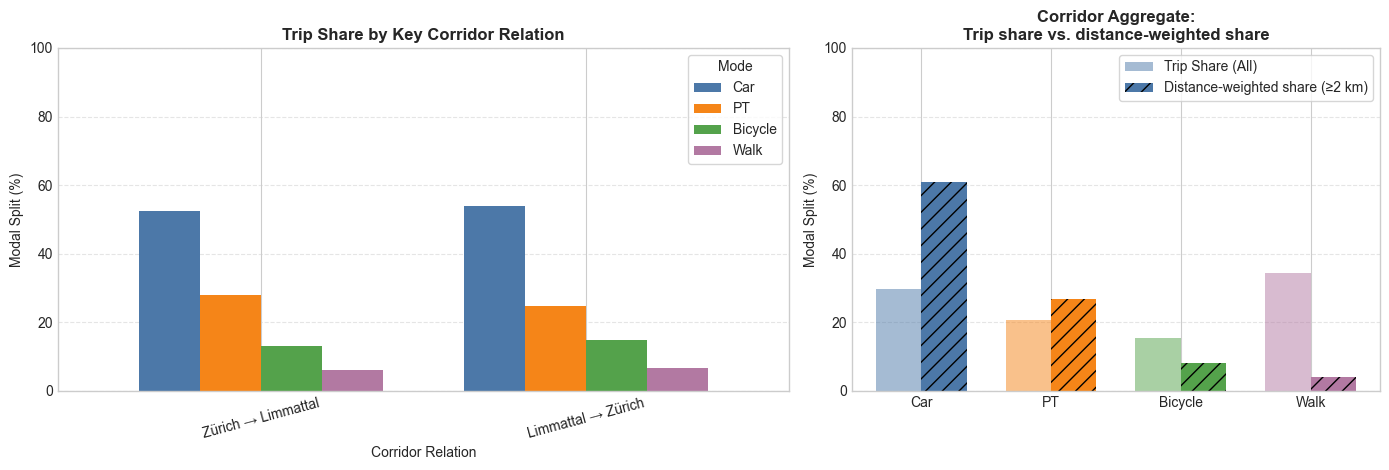

Threshold: 0.0 km | Car: 57.9985% | PT: 26.2497% | Bike: 8.8851% | Walk: 6.8667%
Threshold: 2.0 km | Car: 60.9524% | PT: 26.8257% | Bike: 8.1461% | Walk: 4.0758%
Threshold: 5.0 km | Car: 65.6101% | PT: 26.9526% | Bike: 5.7620% | Walk: 1.6753%
Threshold: 10.0 km | Car: 70.4308% | PT: 26.9997% | Bike: 2.1908% | Walk: 0.3787%
VALIDATION RESULTS
----------------------------
Sum of modal shares: 1.0
All modal shares between 0 and 1: True
Total trips by mode: 658873
Total passenger demand: 658873
Trips equal total demand: True
OD trips match demand: True
All probabilities between 0 and 1: True
OD probabilities sum to 1: True


In [12]:
# Mehr Regions machen um den Modal Split zu unterteilen?
# Short Trips >5km gut so? (unser Perimeter ist sehr viel kleiner)
#-----------------------
# 1. Overall MehrSpur corridor internal modal split (Trip vs PKM Comparison)
# The metrics dictionary automatically computes both pure trips and spatially filtered PKM.

metrics_stage0 = tmi.extract_corridor_metrics(
    ctx,
    res_stage0,
    corridor_zone_ids=corridor_zones,
    min_distance_km=p.MIN_STRATEGIC_PKM_DISTANCE
)

# Separate PT access modes
od = res_stage0.od_by_mode

# Same corridor boundary as the existing modal split
zone_labels = od["pt_walk"].index.astype(str).to_numpy()
internal = np.isin(zone_labels, np.asarray(corridor_zones, dtype=str))
corridor_mask = internal[:, None] | internal[None, :]

pt_walk_trips = od["pt_walk"].to_numpy(dtype=float)[corridor_mask].sum()
pt_bike_trips = od["pt_bike"].to_numpy(dtype=float)[corridor_mask].sum()

total_trips = metrics_stage0["total_trips"]

pt_walk_trip_share = pt_walk_trips / total_trips
pt_bike_trip_share = pt_bike_trips / total_trips

print("PT Walk Trips:", round(pt_walk_trips))
print("PT Bike Trips:", round(pt_bike_trips))
print("PT Total:", round(pt_walk_trips + pt_bike_trips))
print("PT Total (original):", round(metrics_stage0["pt_trips"]))
split_data = [
    {
        "Mode": "Car",
        "Trips (Raw)": metrics_stage0["car_trips"],
        "Trip Share": metrics_stage0["car_share_trips"],
        "PKM Share (>2km)": metrics_stage0["car_share"],
    },
    {
        "Mode": "Public Transport",
        "Trips (Raw)": metrics_stage0["pt_trips"],
        "Trip Share": metrics_stage0["pt_share_trips"],
        "PKM Share (>2km)": metrics_stage0["pt_share"],
    },
    {
        "Mode": "Bicycle",
        "Trips (Raw)": metrics_stage0["bike_trips"],
        "Trip Share": metrics_stage0["bike_share_trips"],
        "PKM Share (>2km)": metrics_stage0["bike_share"],
    },
    {
        "Mode": "Walking",
        "Trips (Raw)": metrics_stage0["walk_trips"],
        "Trip Share": metrics_stage0["walk_share_trips"],
        "PKM Share (>2km)": metrics_stage0["walk_share"],
    },
]

corridor_split = pd.DataFrame(split_data)
exports.save_outputs("1_5_baseline_modal_split", tables={"corridor": corridor_split})
print("Limmattal/Zürich Corridor Baseline Modal Split:")
display(corridor_split.style.format({
    "Trips (Raw)": "{:,.0f}", 
    "Trip Share": "{:.1%}", 
    "PKM Share (>2km)": "{:.1%}"
}).relabel_index([c.replace(">2km", "≥2 km") for c in corridor_split], axis="columns")) 

# 2. Modal split for key corridor relations (Raw Trips)
key_pairs = [
    ("Zürich", "Limmattal"),
    ("Limmattal", "Zürich")
]
od_split = tmi.corridor_od_summary(ctx, res_stage0, key_pairs, macro_regions=p.CORRIDOR_REGIONS)
exports.save_outputs("1_5_baseline_modal_split", tables={"od_relations": od_split})
print("\nModal Split for Key Corridor Relations (Trip-based):")
display(od_split.style.format({
    "total_trips": "{:,.0f}",
    "car_trips": "{:,.0f}",
    "pt_trips": "{:,.0f}",
    "bike_trips": "{:,.0f}",
    "walk_trips": "{:,.0f}",
    "car_share": "{:.1%}",
    "pt_share": "{:.1%}",
    "bike_share": "{:.1%}",
    "walk_share": "{:.1%}",
}))


# Modal Split zwischen Zürich, Schlieren und Dietikon

# Gemeinden definieren
municipality_regions = {
    "Zürich": ["Zürich"],
    "Schlieren": ["Schlieren"],
    "Dietikon": ["Dietikon"]
}

# OD-Relationen in beide Richtungen
municipality_pairs = [
    ("Zürich", "Schlieren"),
    ("Schlieren", "Zürich"),
    ("Zürich", "Dietikon"),
    ("Dietikon", "Zürich"),
    ("Schlieren", "Dietikon"),
    ("Dietikon", "Schlieren")
]

# Modal Split berechnen
municipality_split = tmi.corridor_od_summary(
    ctx,
    res_stage0,
    municipality_pairs,
    macro_regions=municipality_regions
)

# Tabelle anzeigen
display(municipality_split.style.format({
    "total_trips": "{:,.0f}",
    "car_trips": "{:,.0f}",
    "pt_trips": "{:,.0f}",
    "bike_trips": "{:,.0f}",
    "walk_trips": "{:,.0f}",
    "car_share": "{:.1%}",
    "pt_share": "{:.1%}",
    "bike_share": "{:.1%}",
    "walk_share": "{:.1%}"
}))

# Tabelle speichern
exports.save_outputs(
    "1_5_municipality_comparison",
    tables={"municipalities": municipality_split}
)


# Modal Split nach Verkehrsbeziehung
# Internal, Inbound, Outbound, External-External

od = res_stage0.od_by_mode

# Zonen innerhalb unseres definierten Korridors
internal_zones = set(map(str, corridor_zones))

# Verkehrsmittel (PT zusammengefasst)
modes = {
    "Car": od["drive"],
    "PT": od["pt_walk"] + od["pt_bike"],
    "Bicycle": od["bike"],
    "Walking": od["walk"]
}

# OD-Matrizen auf gleiche Zonen ausrichten
reference = od["drive"]
origins = reference.index.astype(str).to_numpy()
destinations = reference.columns.astype(str).to_numpy()

origin_internal = np.isin(origins, list(internal_zones))
destination_internal = np.isin(destinations, list(internal_zones))

# Kategorien nach Start- und Zielort
categories = {
    "Internal": (
        origin_internal[:, None] &
        destination_internal[None, :]
    ),
    "Inbound": (
        ~origin_internal[:, None] &
        destination_internal[None, :]
    ),
    "Outbound": (
        origin_internal[:, None] &
        ~destination_internal[None, :]
    ),
    "External-External": (
        ~origin_internal[:, None] &
        ~destination_internal[None, :]
    )
}

# Modal Shares berechnen
rows = []

for category, mask in categories.items():
    trips = {
        mode: float(matrix.to_numpy(dtype=float)[mask].sum())
        for mode, matrix in modes.items()
    }

    total = sum(trips.values())

    rows.append({
        "Relation": category,
        "Total Trips": total,
        "Car Share": trips["Car"] / total if total else np.nan,
        "PT Share": trips["PT"] / total if total else np.nan,
        "Bicycle Share": trips["Bicycle"] / total if total else np.nan,
        "Walking Share": trips["Walking"] / total if total else np.nan
    })

relation_split = pd.DataFrame(rows)

# Tabelle anzeigen
display(relation_split.style.format({
    "Total Trips": "{:,.0f}",
    "Car Share": "{:.1%}",
    "PT Share": "{:.1%}",
    "Bicycle Share": "{:.1%}",
    "Walking Share": "{:.1%}"
}, na_rep="–"))

# Exportieren
exports.save_outputs(
    "1_5_modal_split_by_relation",
    tables={"relations": relation_split}
)

# 3. Modal split charts: (1) Key corridor relations vs. (2) Aggregate Corridor Baseline
mode_names = ["Car", "PT", "Bicycle", "Walk"]
mode_cols = ["car_share", "pt_share", "bike_share", "walk_share"]
colors = ["#4c78a8", "#f58518", "#54a24b", "#b279a2"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1.8, 1.3]})

# --- Left Plot: OD pair-level modal split ---
plot_data = od_split.set_index("OD relation")[mode_cols].mul(100)
plot_data.columns = mode_names
plot_data.plot(kind="bar", ax=axes[0], color=colors, width=0.75, edgecolor="none")
axes[0].set_title("Trip Share by Key Corridor Relation", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Corridor Relation", fontsize=10)
axes[0].set_ylabel("Modal Split (%)", fontsize=10)
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(title="Mode", frameon=True)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# --- Right Plot: PKM vs Trip Share Comparison ---
x_indices = np.arange(len(mode_names))
width = 0.35

axes[1].bar(x_indices - width/2, corridor_split["Trip Share"].mul(100), width, label='Trip Share (All)', color=[c for c in colors], alpha=0.5)
axes[1].bar(x_indices + width/2, corridor_split["PKM Share (>2km)"].mul(100), width, label='Distance-weighted share (≥2 km)', color=colors, hatch="//")

axes[1].set_title("Corridor Aggregate:\nTrip share vs. distance-weighted share", fontsize=12, fontweight="bold")
axes[1].set_xticks(x_indices)
axes[1].set_xticklabels(mode_names)
axes[1].set_ylabel("Modal Split (%)", fontsize=10)
axes[1].set_ylim(0, 100)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
axes[1].legend(loc="upper right", frameon=True)

plt.tight_layout()
exports.save_outputs("1_5_baseline_modal_split", figure=fig)
plt.show()

for threshold in [0.0, 2.0, 5.0, 10.0]:
    metrics_test = tmi.extract_corridor_metrics(
        ctx,
        res_stage0,
        corridor_zone_ids=corridor_zones,
        min_distance_km=threshold
    )

    print(
        f"Threshold: {threshold} km | "
        f"Car: {metrics_test['car_share']:.4%} | "
        f"PT: {metrics_test['pt_share']:.4%} | "
        f"Bike: {metrics_test['bike_share']:.4%} | "
        f"Walk: {metrics_test['walk_share']:.4%}"
    )




# Validation of Baseline Modal Split (Stage 0)

import numpy as np

od = res_stage0.od_by_mode

modes = ["drive", "pt_walk", "pt_bike", "bike", "walk"]

# 1. Total trips by mode
mode_trips = {
    mode: od[mode].to_numpy(dtype=float).sum()
    for mode in modes
}

total_mode_trips = sum(mode_trips.values())

# 2. Total passenger demand
total_demand = ctx.baseline_od.to_numpy(dtype=float).sum()

# 3. Check shares
shares = {
    mode: trips / total_mode_trips
    for mode, trips in mode_trips.items()
}

print("VALIDATION RESULTS")
print("----------------------------")

print("Sum of modal shares:", sum(shares.values()))

print("All modal shares between 0 and 1:",
      all(0 <= x <= 1 for x in shares.values()))

print("Total trips by mode:", round(total_mode_trips))
print("Total passenger demand:", round(total_demand))

print("Trips equal total demand:",
      np.isclose(total_mode_trips, total_demand))

# 4. OD-specific checks
aligned = [
    od[mode].reindex(
        index=ctx.baseline_od.index,
        columns=ctx.baseline_od.columns
    ).to_numpy(dtype=float)
    for mode in modes
]

od_sum = np.sum(aligned, axis=0)
demand = ctx.baseline_od.to_numpy(dtype=float)

print("OD trips match demand:",
      np.allclose(od_sum, demand, atol=1e-5))

# Implied probabilities for OD pairs with demand
valid = demand > 0

probabilities = np.stack(aligned, axis=0)[:, valid] / demand[valid]

print("All probabilities between 0 and 1:",
      np.all((probabilities >= -1e-8) &
             (probabilities <= 1 + 1e-8)))

print("OD probabilities sum to 1:",
      np.allclose(probabilities.sum(axis=0), 1.0, atol=1e-5))


> **Modal-split validation**
>
> After reviewing these results, you can further inspect the modal split for different travel-demand categories, such as internal, inbound, outbound, and pass-through travel demand for your case study area. 
>
> Compare the resulting total travel demand, specific OD-pair travel demand and modal split with available reference values, including observed transport data, official statistics, previous studies, and results from earlier course editions.
>
> Consider whether differences are plausible given trip distance, spatial context, transport availability, and the model assumptions. Any relevant discrepancy should be investigated and documented, as modal split directly influences network travel demand, congestion, travel-time benefits, emissions, and the subsequent CBA.

### Tutorial/Supporting Task:

### Exploration: Utilities, Demand, and Modal Split (tutorial/supporting task)

> Below is an explanation of how modal splits are computed. You can play with the interactive widget below, in order to get a sense of the relevance and role of key parameters, which we will use in later computations and notebooks.

Travelers choose modes based on **utility** ($U$), a score of relative attractiveness where a higher (less negative) value means greater desirability. It is estimated based on trip attributes and attribute-specific (beta) coefficients that convert those attributes into utility units.

$$U_m = \beta_m + \beta_{TT} \cdot TT_m + \beta_{\text{cost}} \cdot C_m$$

- $TT_m$: travel time of mode $m$ on the origin–destination trip the traveller is considering (for example driving A→B vs taking PT A→B). Each competing option has its own $TT_m$.
- $\beta_{TT}$: how travel time influences a traveler's perceived utility of a trip. It is typically negative, such that a longer $TT_m$ lowers $U_m$. A more negative value means people switch away from slower modes more readily.
- $C_m$: monetary cost of that mode $m$ (e.g., fuel for car, fare for PT). Walk and bicycle modes typically have no associated cost.
- $\beta_{\text{cost}}$: how strongly travellers dislike paying. It is also negative, so a higher $C_m$ lowers $U_m$. A more negative value means people are more price-sensitive.

The beta coefficients are estimated using real-world survey data on mode choices made by travelers. In this course, these coefficients are provided to the students as inputs. Together, the utility equation puts trip attributes (such as minutes and francs) onto the same utility scale, which is how a cheaper but slower mode can be considered alongside a faster, more expensive one.

The **Multinomial Logit Model** then converts these utilities into choice probabilities, whereby a mode with a higher $P$ is more likely to be chosen:

$$P_m = \frac{\exp(U_m)}{\sum_{k} \exp(U_k)}$$

---

#### What is the $\beta_m$ parameter and how does it affect the results?
* **Intrinsic Preference ($\beta_m$)**: The constant $\beta_m$ (sometimes referred to as the alternative-specific constant, ASC) captures all unobserved factors (i.e., not captured by travel time and cost) related to the mode $m$ (e.g., comfort, flexibility, privacy, weather protection, or prestige).
* **Impact on Modal Split**: As logit probabilities depend exponentially on utility (the $\exp(U_m)$ term in the $P_m$ equation above), increasing $\beta_m$ directly raises mode $m$'s attractiveness relative to all alternatives, pulling travel demand away from competing modes across the corridor.

Use the demand and PT preference sliders below to compare trip totals and modal shares. Part 2 explores PT preference and e-bike technology. Part 3 introduces infrastructure stages.

In [11]:
if callable(globals().get("dashboard_state", {}).get("close")):
    dashboard_state["close"]()

# Interactive mode-choice & parameter sensitivity dashboard — Stage 0 only
corridor_zones = list(MEHRSPUR.zone_ids)

stage_0_specs = {
    0: stages[0],}

dashboard_ui, dashboard_state = tmi.mode_choice_dashboard(
    ctx,
    # Keep Stage 0 fixed for now, we will later explore the impact of stages.
    # If you want to come back to this dashboard later, 
    # you can set the display back by writing 'stages' instead of 'stage_0_specs'.
    stage_specs=stage_0_specs,  #here 'stages'
    corridor_zone_ids=corridor_zones,)

display(dashboard_ui)


The demand slider scales all OD flows equally. With fixed skims and preferences, it changes trip totals but leaves modal shares unchanged. The **PT ASC shift** changes the attractiveness of both PT alternatives relative to car, cycling and walking; a positive shift increases PT use.

Sliders update when released. Demand-only changes reuse the current modal split; changing PT ASC recalculates mode choice with fixed skims. Use **Refresh** to redraw the current setting. Section 1.6 adds congestion feedback.


## 1.6 Traffic assignment and congestion feedback (tutorial/supporting task + mandatory task + advanced task)

Car traffic assignment loads the **latest car travel demand from mode choice**, plus fixed background road traffic, onto the reduced MehrSpur network. Car travel demand is converted to vehicles using the configured occupancy factor. Internal, inbound, outbound, and assumed pass-through movements enter through the same zone-and-gate OD matrix.

The local solver uses the All-or-Nothing (AoN) shortest paths and the **Method of Successive Averages (MSA)** algorithms. MSA is an algorithm used in the transport model that makes use of the following **Bureau of Public Roads (BPR)** function that converts link-level traffic volumes and capacity into link-specific congested travel times:

$$t_a = t_{a,0} \left[ 1 + \alpha_a \left( \frac{v_a}{c_a} \right)^{\beta_a} \right]$$

* $t_a$: Congested link travel time of the link $a$
* $t_{a,0}$: Free-flow travel time of the link $a$
* $v_a / c_a$: Volume-to-capacity ($V/C$) ratio of the link $a$
* $\alpha_a, \beta_a$: Calibrated BPR link parameters (typically $\alpha = 0.15, \beta = 4.0$)

In each MSA iteration, travel demand is loaded onto the current shortest paths and averaged with traffic volumes from earlier iterations using a $1/k$ step, where $k$ refers to the iteration number of the MSA loop. The $1/k$ step is how much of the new shortest-path assignment you mix in at that iteration.

The solver stops when the **road relative gap is at most 2%**, after at least eight iterations, or reaches the maximum of 64 iterations. It checks every four iterations. The controls let you change the gap target, iteration cap, OD cutoff and pass-through assumption. The default cutoff is zero.

The road relative gap compares the travel cost of the current link flows with shortest-route travel cost for the **same assigned OD demand**:

$$RG = \frac{\sum_a v_a t_a - \sum_{od} q_{od} c^{\mathrm{shortest}}_{od}}{\sum_a v_a t_a}.$$

A 2% gap means that approximately 2% of current aggregate road travel cost remains above that shortest-route benchmark. It is a route-assignment stopping criterion, not proof that the entire mode-choice system is in equilibrium. In the coupled calculation, the comparison uses the feasible averaged OD demand represented by the current link flows.

The internal **relative L1 flow change** instead measures how much traffic volume moved since the previous iteration. MSA's shrinking step can make that change small even when routes remain inefficient, so L1 is not the stopping criterion or the convergence plot here. Unserved demand is reported separately: a small gap does not prove that every OD pair is reachable.

The dashboard controls only affect the interactive runs in this section. To change the defaults used by the rest of the notebook, edit `ASSIGNMENT_SETTINGS` in [`transport_model_interface.py`](../code/transport_model_interface.py).

The first dashboard deliberately keeps car travel demand fixed so that you can inspect the car traffic assignment mechanism itself. Use the map selector and clickable links to examine assigned traffic volume, $V/C$, congested time, speed, and capacity. The later coupled dashboard closes the feedback loop and shows how congestion can also change modal split.

In [13]:

# Assignment uses the nominal baseline; demand-slider experiments remain separate.
mode_result = res_stage0

print(
    "Assignment has not started. Use the controls below and click "
    "'Run corridor MSA assignment' to begin."
)

# Keeping the notebook cell small: demand preparation, MSA, diagnostics,
# convergence chart, audit tables, and the interactive map live in tmi.
ASSIGNMENT_MODE_STATE = {"result": mode_result}
ASSIGNMENT_UI, ASSIGNMENT_STATE = tmi.assignment_dashboard(
    ctx,
    MEHRSPUR,
    ASSIGNMENT_MODE_STATE,
    modal_feedback=False,  # isolate car traffic assignment first
)
display(ASSIGNMENT_UI)


Assignment has not started. Use the controls below and click 'Run corridor MSA assignment' to begin.


### Checking the MSA iteration limit and stopping threshold (tutorial/supporting task)

The following small experiment perturbs demand and repeats fixed-demand road assignment. It plots the **road relative gap**, using the same definition as the coupled solver and surrogate reference training. Each run stops at the configured 2% target or iteration cap; the curve shows only runs that reached each checked iteration.

Use the median, interquartile range and share of runs reaching each threshold to discuss computational effort. These are numerical stress tests, not future scenarios or calibration against traffic counts.

> This can take several minutes. `N_CONVERGENCE_RUNS` controls the number of examples.


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   2 out of   6 | elapsed:   30.9s remaining:  1.0min
[Parallel(n_jobs=4)]: Done   3 out of   6 | elapsed:   31.0s remaining:   31.0s
[Parallel(n_jobs=4)]: Done   4 out of   6 | elapsed:   37.4s remaining:   18.6s
[Parallel(n_jobs=4)]: Done   6 out of   6 | elapsed:  1.0min finished


,iteration,median,q25,q75,observed_runs
0,8,0.038,0.032,0.043,6
1,12,0.030,0.024,0.031,6
2,16,0.020,0.019,0.021,6
3,20,0.016,0.016,0.018,3


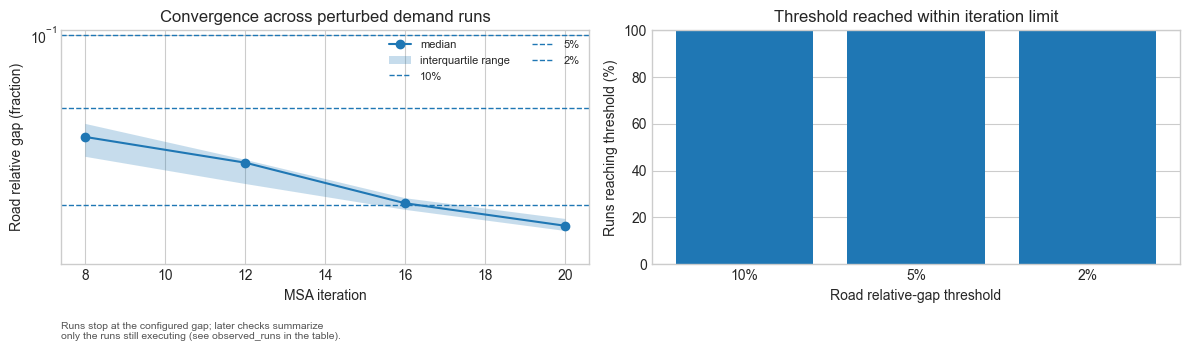

In [14]:
# Parallel numerical stability test for the fixed-demand MSA calculation.

N_CONVERGENCE_RUNS = 6
CONVERGENCE_MAX_ITERATIONS = ASSIGNMENT_OPTIONS["max_iterations"]
CONVERGENCE_THRESHOLDS = (0.10, 0.05, 0.02)
N_CONVERGENCE_JOBS = min(4, max(1, (os.cpu_count() or 2) - 1))

MSA_CONVERGENCE = tmi.assignment_convergence_test(
    ctx,
    MEHRSPUR,
    mode_result,
    n_runs=N_CONVERGENCE_RUNS,
    max_iterations=CONVERGENCE_MAX_ITERATIONS,
    thresholds=CONVERGENCE_THRESHOLDS,
    n_jobs=N_CONVERGENCE_JOBS,
)

exports.save_outputs("1_6_msa_convergence", tables=MSA_CONVERGENCE)
display(
    MSA_CONVERGENCE["summary"].style.format({
        "median": "{:.3f}",
        "q25": "{:.3f}",
        "q75": "{:.3f}",
    })
)

MSA_CONVERGENCE_FIGURE = tmi.plot_assignment_convergence_test(
    MSA_CONVERGENCE,
    thresholds=CONVERGENCE_THRESHOLDS,
)
exports.save_outputs("1_6_msa_convergence", figure=MSA_CONVERGENCE_FIGURE)
display(MSA_CONVERGENCE_FIGURE)

The chart contains checked road-relative-gap values. Runs that stop earlier do not contribute to later-iteration summaries. A run that reaches the iteration cap before the target is reported as unconverged; increasing the cap is a separate modeling choice.


### Closing the loop: modal split inside the MSA iteration

The fixed-demand dashboard above updates road routes and link travel times, but it assigns traffic based on an OD matrix that was estimated only once from uncongested travel time skims. Congestion is therefore not yet considered within the choice set of a traveller deciding between public transport, bicycle, walking, or a PT access alternative. The following workflow includes congestion effects in the consideration using the same MSA sequence:

1. The BPR function is used to update every road-link travel time from the current traffic volume.
2. The shortest paths algorithm produces the subsequent link traffic-volume target.
3. Travel times between every internal zone and direction-compatible cordon gate are recorded at both free flow and current congestion levels.
4. The nonnegative difference between congested and free-flow local shortest-path times is added to the reference 1,223-zone car skim. Journey components outside the local assignment network remain fixed.
5. The five-alternative logit model recomputes Car, Walk, Bicycle, PT with walk access, and PT with bicycle access travel demand. Updated car travel demand is collapsed to gates and averaged with the same $1/k$ MSA step as link traffic volume.

This is still a local-network approximation: travel times change on links in the local assignment network, including retained connecting links outside the cordon. Journey components beyond this network remain fixed. As the routes between different OD pairs traverse different internal zones and gates, the travel times between these OD pairs are thus updated based on zone- and gate-specific congested times.

In [19]:
# Run the same assignment controls with congestion-to-mode-choice feedback.
COUPLED_ASSIGNMENT_UI, COUPLED_ASSIGNMENT_STATE = tmi.assignment_dashboard(
    ctx,
    MEHRSPUR,
    ASSIGNMENT_MODE_STATE,
    modal_feedback=True,
)
display(COUPLED_ASSIGNMENT_UI)

diag = coupled_assignment.diagnostics

print("Iterations:", diag.get("iterations"))
print("Stopping rule met:", diag.get("stopping_rule_met"))
print("Termination reason:", diag.get("termination_reason"))

print("Final road gap:",
      diag.get("final_road_relative_gap_feasible_averaged_od"))

Iterations: 20
Stopping rule met: True
Termination reason: converged
Final road gap: 0.016561605572813772


Compare fixed-demand MSA with coupled congestion–mode-choice feedback using the same assignment settings. The next cell reuses dashboard results only when their inputs match the shared configuration; otherwise it calculates the missing comparison. Thus the changed assumption is whether congestion feeds back into mode choice.


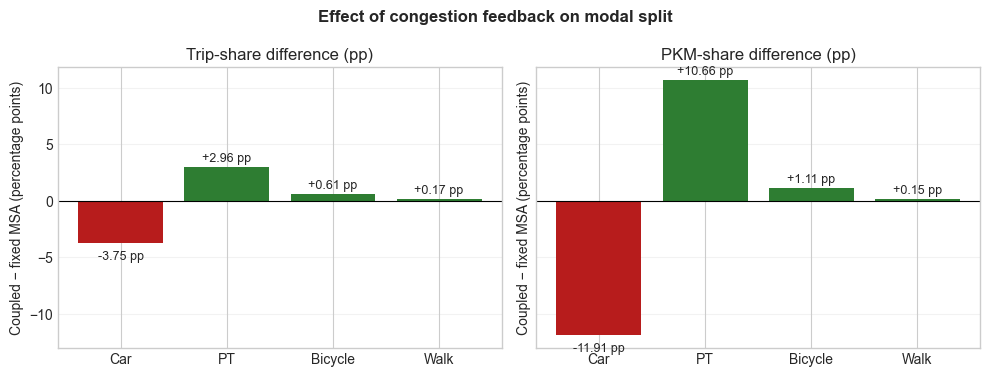

Non-negative traffic flows: True
Non-negative travel times: True
Total congestion delay (hours): 7043.35
Non-negative congestion delay: True
Non-negative V/C ratios: True
Maximum V/C ratio: 4.03
Maximum link travel time (min): 10.69


In [18]:
# Compare the same baseline, network and solver settings with/without feedback.
_assignment_mode_result = ASSIGNMENT_MODE_STATE.get("result")
if _assignment_mode_result is None:
    raise RuntimeError("Run the Stage 0 mode-choice calculation before this cell.")

def matching_dashboard(state, coupled):
    result = state.get("result")
    return (
        result is not None
        and state.get("context") is ctx
        and state.get("corridor") is MEHRSPUR
        and state.get("mode_cache_key") == tuple(_assignment_mode_result.cache_key)
        and bool(result.diagnostics.get("modal_feedback", False)) == coupled
        and tmi.assignment_settings_match(result.diagnostics, ASSIGNMENT_OPTIONS,
                                         passthrough_fraction=tmi.DEFAULT_PASSTHROUGH_FRACTION)
    )

def comparison_assignment(state, coupled):
    if matching_dashboard(state, coupled):
        return state["result"]
    print(f"Calculating {'coupled' if coupled else 'fixed-demand'} assignment with shared settings...")
    runner = tmi.run_coupled_corridor_assignment if coupled else tmi.run_corridor_assignment
    result = runner(ctx, MEHRSPUR, _assignment_mode_result,
        passthrough_fraction=tmi.DEFAULT_PASSTHROUGH_FRACTION,
        **tmi.assignment_solver_kwargs(ASSIGNMENT_OPTIONS, coupled=coupled))
    # Keep the interactive dashboard's own selected result separate.
    return result

fixed_assignment = comparison_assignment(ASSIGNMENT_STATE, False)
coupled_assignment = comparison_assignment(COUPLED_ASSIGNMENT_STATE, True)

# -------------------------------------------------------------------------
# 1. Difference in modal split
# Values are percentage-point changes: coupled minus fixed-demand MSA.
# -------------------------------------------------------------------------

fixed_mode = (
    fixed_assignment.mode_result
    if fixed_assignment.mode_result is not None
    else ASSIGNMENT_MODE_STATE["result"]
)
coupled_mode = coupled_assignment.mode_result

if coupled_mode is None:
    raise RuntimeError("The coupled assignment contains no updated mode-choice result.")

zone_ids = (
    corridor_zones
    if "corridor_zones" in globals()
    else MEHRSPUR.zone_ids
)

fixed_metrics = tmi.extract_corridor_metrics(
    ctx, fixed_mode, corridor_zone_ids=zone_ids
)
coupled_metrics = tmi.extract_corridor_metrics(
    ctx, coupled_mode, corridor_zone_ids=zone_ids
)

modes = {
    "Car": "car",
    "PT": "pt",
    "Bicycle": "bike",
    "Walk": "walk",
}

modal_difference = pd.DataFrame({
    "Trip-share difference (pp)": {
        mode: 100 * (
            coupled_metrics[f"{key}_share_trips"]
            - fixed_metrics[f"{key}_share_trips"]
        )
        for mode, key in modes.items()
    },
    "PKM-share difference (pp)": {
        mode: 100 * (
            coupled_metrics[f"{key}_share"]
            - fixed_metrics[f"{key}_share"]
        )
        for mode, key in modes.items()
    },
})

exports.save_outputs("1_6_feedback_modal_difference", tables={"": modal_difference})
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)

for axis, column in zip(axes, modal_difference.columns):
    values = modal_difference[column]
    colours = ["#2e7d32" if value >= 0 else "#b71c1c" for value in values]

    bars = axis.bar(values.index, values, color=colours)
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set_title(column)
    axis.set_ylabel("Coupled − fixed MSA (percentage points)")
    axis.grid(axis="y", alpha=0.25)

    for bar, value in zip(bars, values):
        axis.annotate(
            f"{value:+.2f} pp",
            (bar.get_x() + bar.get_width() / 2, value),
            xytext=(0, 4 if value >= 0 else -12),
            textcoords="offset points",
            ha="center",
            fontsize=9,
        )

fig.suptitle("Effect of congestion feedback on modal split", fontweight="bold")
fig.tight_layout()
exports.save_outputs("1_6_feedback_modal_difference", figure=fig)
plt.show()


# -------------------------------------------------------------------------
# 2. Relative difference in link-assignment results
# Only percentage-change attributes are retained in the map.
# -------------------------------------------------------------------------

def indexed_links(links):
    """Create a stable comparison key for directed links."""
    frame = links.copy().reset_index(drop=True)

    if (
        "edge_id" in frame
        and frame["edge_id"].notna().all()
        and not frame["edge_id"].astype(str).duplicated().any()
    ):
        frame["_comparison_key"] = frame["edge_id"].astype(str)
    else:
        occurrence = frame.groupby(
            ["source", "target"], sort=False
        ).cumcount().astype(str)

        frame["_comparison_key"] = (
            frame["source"].astype(str)
            + " → "
            + frame["target"].astype(str)
            + " #"
            + occurrence
        )

    return frame.set_index("_comparison_key", drop=False)


def relative_change(after, before):
    """Percentage change; undefined where the fixed-MSA value is zero."""
    after = pd.to_numeric(after, errors="coerce").to_numpy(dtype=float)
    before = pd.to_numeric(before, errors="coerce").to_numpy(dtype=float)

    return np.divide(
        100 * (after - before), np.abs(before),
        out=np.full_like(before, np.nan), where=np.abs(before) > 1e-9,
    )


fixed_links = indexed_links(fixed_assignment.links)
coupled_links = indexed_links(coupled_assignment.links)

common_links = fixed_links.index.intersection(coupled_links.index)
if common_links.empty:
    raise RuntimeError("The two assignments contain no matching directed links.")

# Retain identifiers, geometry, and percentage differences only.
identifier_columns = [
    column
    for column in (
        "_comparison_key", "edge_id", "source", "target", "highway", "geometry"
    )
    if column in coupled_links
]

link_differences = coupled_links.loc[
    common_links, identifier_columns
].copy()

comparison_metrics = {
    "flow_difference_pct": "flow_vehicles",
    "vc_difference_pct": "volume_capacity_ratio",
    "time_difference_pct": "time_min",
    "speed_difference_pct": "assigned_speed_kph",
}

for output_column, source_column in comparison_metrics.items():
    link_differences[output_column] = relative_change(
        coupled_links.loc[common_links, source_column],
        fixed_links.loc[common_links, source_column],
    )

exports.save_outputs("1_6_feedback_link_differences", tables={
    "": link_differences.drop(columns="geometry", errors="ignore"),
})
NETWORK_FEEDBACK_DIFFERENCE_MAP = tmi.network_explorer(
    link_differences,
    {
        "Traffic-volume difference (%)": {
            "column": "flow_difference_pct",
        },
        "Volume/capacity difference (%)": {
            "column": "vc_difference_pct",
        },
        "Congested-time difference (%)": {
            "column": "time_difference_pct",
        },
        "Assigned-speed difference (%)": {
            "column": "speed_difference_pct",
        },
    },
    gates=MEHRSPUR.gates,
    polygon=MEHRSPUR.polygon_gdf,
    title=(
        "Coupled modal-feedback MSA minus fixed-demand MSA — "
        "relative link differences only"
    ),
    height=650,
)

display(NETWORK_FEEDBACK_DIFFERENCE_MAP)


# Validation of coupled assignment – Task 1.6

import numpy as np
import pandas as pd

links = coupled_assignment.links

# Check traffic flows
flows = pd.to_numeric(links["flow_vehicles"], errors="coerce")
print("Non-negative traffic flows:",
      np.isfinite(flows).all() and (flows >= 0).all())

# Check congested travel times
times = pd.to_numeric(links["time_min"], errors="coerce")
print("Non-negative travel times:",
      np.isfinite(times).all() and (times >= 0).all())

# Check overall congestion delay
delay = coupled_assignment.diagnostics["total_delay_hours"]
print("Total congestion delay (hours):", round(delay, 2))
print("Non-negative congestion delay:",
      np.isfinite(delay) and delay >= 0)

# Check V/C ratios
vc = pd.to_numeric(links["volume_capacity_ratio"], errors="coerce")
print("Non-negative V/C ratios:",
      np.isfinite(vc).all() and (vc >= 0).all())

print("Maximum V/C ratio:", round(vc.max(), 2))
print("Maximum link travel time (min):", round(times.max(), 2))


We can inspect how uniform changes in total passenger OD demand affect congestion and mode choice. Prepared background road traffic stays fixed. Every case uses the same road-gap target and iteration cap; easy cases can finish sooner.

> The four examples can take several minutes.


In [17]:
DEMAND_MULTIPLIERS_COMBINED = [0.6, 1.0, 1.4, 1.8]
COMBINED_MSA_ITERATIONS = ASSIGNMENT_OPTIONS["max_iterations"]

# Run one independent demand scenario per process.
N_JOBS = min(
    len(DEMAND_MULTIPLIERS_COMBINED),
    max(1, (os.cpu_count() or 2) - 1),
)

mode_result = ASSIGNMENT_MODE_STATE.get("result")

if mode_result is None:
    raise RuntimeError(
        "Run the Stage 0 mode-choice calculation before this cell."
    )


def run_combined_case(demand_multiplier):
    """Run one coupled MSA scenario and return lightweight outputs."""

    result = tmi.run_coupled_corridor_assignment(
        ctx,
        MEHRSPUR,
        mode_result,
        demand_multiplier=demand_multiplier,
        **tmi.assignment_solver_kwargs(ASSIGNMENT_OPTIONS),
    )

    history = result.history.copy()
    history["demand_multiplier"] = demand_multiplier

    return history, result.diagnostics


# ---------------------------------------------------------------------------
# 1. Run the demand scenarios in parallel
# ---------------------------------------------------------------------------

started = time.perf_counter()

parallel_results = Parallel(
    n_jobs=N_JOBS,
    backend="loky",
)(
    delayed(run_combined_case)(multiplier)
    for multiplier in DEMAND_MULTIPLIERS_COMBINED
)

combined_elapsed = time.perf_counter() - started

combined_history = pd.concat(
    [history for history, _ in parallel_results],
    ignore_index=True,
)

combined_diagnostics = pd.DataFrame([
    {
        "demand_multiplier": multiplier,
        **diagnostics,
    }
    for multiplier, (_, diagnostics) in zip(
        DEMAND_MULTIPLIERS_COMBINED,
        parallel_results,
    )
])

exports.save_outputs("1_6_demand_scenarios", tables={
    "history": combined_history, "diagnostics": combined_diagnostics,
})

print(
    f"Completed {len(DEMAND_MULTIPLIERS_COMBINED)} demand scenarios × "
    f"up to {COMBINED_MSA_ITERATIONS} MSA iterations "
    f"using {N_JOBS} parallel workers in {combined_elapsed:.1f}s."
)


# ---------------------------------------------------------------------------
# 2. Modal split response, iteration by iteration
# ---------------------------------------------------------------------------

from matplotlib.ticker import MultipleLocator, MaxNLocator

MODE_SERIES = {
    "car_share": ("Car", "#4878b8"),
    "bike_share": ("Bicycle", "#45a564"),
    "walk_share": ("Walk", "#d34e4e"),
    "pt_share": ("PT", "#8172b3"),
}

fig, axes = plt.subplots(
    1,
    len(DEMAND_MULTIPLIERS_COMBINED),
    figsize=(16, 4.2),
    sharey=True,
)

for axis, multiplier in zip(
    axes,
    DEMAND_MULTIPLIERS_COMBINED,
):
    history = combined_history.loc[
        combined_history["demand_multiplier"] == multiplier
    ]

    for column, (label, colour) in MODE_SERIES.items():
        axis.plot(
            history["iteration"],
            100.0 * history[column],
            marker="o",
            linewidth=1.8,
            color=colour,
            label=label,
        )

    axis.set_title(f"Demand ×{multiplier:g}")
    axis.set_xlabel("MSA iteration")
    axis.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=8))

    axis.yaxis.set_minor_locator(MultipleLocator(1))
    axis.grid(which="major", alpha=0.25)
    axis.grid(which="minor", axis="y", alpha=0.10, linewidth=0.5)

axes[0].set_ylabel("Modal split (%)")

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(0.995, 0.5),
)

fig.suptitle(
    "Modal split responding to congestion, iteration by iteration "
    "(combined MSA loop)",
    fontsize=13,
)

fig.tight_layout(rect=(0, 0, 0.94, 0.93))
exports.save_outputs("1_6_demand_scenarios_modal_split", figure=fig)
plt.show()


# 3. Road relative gap at checked iterations.
gap_column = "road_relative_gap_feasible_averaged_od"
fig, axis = plt.subplots(figsize=(9, 4.5))
for multiplier, history in combined_history.groupby("demand_multiplier", sort=False):
    checked = history.loc[np.isfinite(history[gap_column])]
    axis.plot(checked["iteration"], 100 * checked[gap_column], marker="o",
              label=f"Passenger demand ×{multiplier:g}")
axis.axhline(100 * ASSIGNMENT_OPTIONS["road_gap_threshold"], color="black",
             linestyle="--", label="Stopping target")
axis.set(xlabel="MSA iteration", ylabel="Road relative gap (%)",
         title="Road assignment convergence with modal feedback")
axis.set_ylim(bottom=0)
axis.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=8))
axis.grid(alpha=0.25)
axis.legend()
fig.tight_layout()
exports.save_outputs("1_6_demand_scenarios_road_gap", figure=fig)
plt.show()
display(combined_diagnostics[["demand_multiplier", "iterations",
    "final_road_relative_gap_feasible_averaged_od", "termination_reason"]])


KeyboardInterrupt: 

### Calibrating the model (advanced task)

Use the car traffic assignment results together with the earlier travel demand and modal-split analyses to assess whether the model provides a credible representation of current conditions. Compare modelled traffic volumes, congestion, speeds, travel times, congested time, and modal split with independent real-world evidence, such as official traffic counters, public-transport statistics, travel surveys, observed journey times, or previous studies.

Before comparing values, ensure that the model and reference data use compatible:

- locations and travel directions.
- time periods, particularly the modelled evening peak hour.
- units and vehicle or passenger definitions.
- vehicle-occupancy assumptions.
- road links and geographic boundaries.
- survey or measurement dates.

Investigate discrepancies systematically. Potential causes include:

- the cantonal OD matrix and total travel demand.
- the demand retained inside the corridor.
- internal, inbound, outbound, and pass-through movements.
- the number and spatial distribution of cordon gates.
- the allocation of external demand to gates.
- background road traffic.
- vehicle occupancy.
- network link capacities and free-flow speeds.
- mode-choice parameters and car travel time skims.
- insufficient convergence of the MSA assignment.

Where justified by evidence, calibrate a limited number of clearly identified parameters and repeat the complete validation chain:

1. total and retained passenger demand.
2. internal, inbound, outbound, and pass-through demand.
3. modal split.
4. traffic volumes by link and direction.
5. travel times and speeds.
6. volume–capacity ratios and congestion delay.

Document every adjustment, its supporting evidence, and its effect on the results. Do not tune the model solely to reproduce one counter or indicator: improving the fit of link volumes should not produce implausible modal shares, travel times, gate flows, or demand patterns elsewhere.

Keep calibration assumptions separate from infrastructure-stage modifications. Stage 0 should remain a transparent and defensible representation of current conditions, while later stages should contain only the changes associated with the proposed interventions.

## 1.7 Performance Indicators (mandatory task)

Performance indicators are used to evaluate outcomes. Before evaluating scenarios over the 40-year horizon, we define our core **performance indicators**. These translate the spatial transport model results into measurable corridor quantities.

| Indicator | Unit | What it measures |
|---|---|---|
| Trip time | min/trip | Demand-weighted skim time. PT includes in-vehicle, access, egress and waiting components |
| Road delay | vehicle-hours/peak hour | Assigned road time beyond free-flow, including prepared background and synthetic vehicle loading |
| Carbon emissions | tonnes/peak hour | Passenger-car emissions in this table |
| Trips and modal shares | passenger trips/peak hour; % | Modeled corridor passenger demand |

Year 1 and Year 40 use the same nominal passenger growth, PT preference, e-bike share and road-freight paths as later comparisons. Annual totals use each mode's daily conversion and equivalent days; road delay applies only during the configured peak hours. Later appraisal indicators distinguish passenger delay from vehicle delay and report motorized in-vehicle time separately.

<br>

> **Note: Why don't we exclude short-distance trips from time, delay and emissions indicators?**
> In Section 1.5, we filtered the Modal Split to trips `≥ 5 km` to isolate the strategic behavioral shift. However, for the physical indicators below (Congested Time, Travel Time, $\text{CO}_2$), we retain short and long journeys with at least one endpoint in the buffered reporting area. Assigned road delay also includes background vehicles. 
> This is because moving long-distance commuters to rail empties out the A1 highway, which can also reduce congestion for short-distance local drivers. In a Cost-Benefit Analysis, we must capture this systemic "Decongestion Benefit", so throwing away local travel demand from the travel time calculation would severely undercount the project's true economic value.

Annual appraisal indicators also include electricity-related rail emissions, calculated from the service timetable.

Now, we run a simulation for Year 1 and one for Year 40, in order to compare the differences between the two snapshots.
Choose `PERFORMANCE_INDICATORS` below from `INDICATOR_CATALOG`. This selects the displayed indicator families in Sections 1.7, 3.3 and 4.3. Definitions and units remain specific to each table; calculations and later appraisal retain all indicators.

`STAGE_PLOT_INDICATORS`, `PLAN_PLOT_INDICATORS` and `PROJECT_PLOT_INDICATORS` choose individual subplots and their order; an empty list hides that figure. `CHANGE_PLOT_COLUMNS` and `CHANGE_PLOT_FONT_SIZE` control the layout. Rerun this selection cell and the display cells in Sections 3.3/4.3 to change those figures. The display cells reuse completed calculations.


In [ ]:
# Select indicator families for the tables and plots in Sections 1.7, 3.3 and 4.3.
INDICATOR_CATALOG = {
    "trips": "Peak person-trips and mode-specific annual trip equivalents",
    "trip_share": "Shares of person-trips (Sections 1.7 and 3.3)",
    "distance_share": "Strategic modal shares, weighted by common OD distance for trips ≥5 km",
    "travel_time": "Journey time in 1.7; car/PT in-vehicle time in 3.3 and 4.3",
    "road_delay": "Vehicle-hours including background in 1.7; passenger-hours in 3.3 and 4.3",
    "operating_co2": "Passenger-car CO2 in 1.7 and 3.3; car and rail CO2 in 4.3",
    "construction_co2": "Total package construction emissions (Section 4.3)",
    "infrastructure_cost": "Undiscounted investment plus operating cost (Section 4.3)",
    "stage": "Transport configuration in Year 40 (Section 4.3)",
    "section_travel_time": "Section reference-pair in-vehicle minutes, fixed OD/submode weights",
    "section_loading": "Modeled and supplementary section passengers, comfort capacity and load/capacity",
    "section_crowding": "Peak crowding multiplier and discomfort-equivalent minutes for the section reference journey",
    "pt_components": "Waiting, access, egress and transfer walking for the same-year baseline PT passengers",
}
# Default display selection for the corridor and project-effect figures.
# Adding a catalogue entry does not automatically add it to this selection.
PERFORMANCE_INDICATORS = [
    "trips", "trip_share", "distance_share", "travel_time", "road_delay",
    "operating_co2", "construction_co2", "infrastructure_cost", "stage",
    "section_travel_time", "section_loading", "section_crowding", "pt_components",
]
# Individual subplots, in display order; [] hides a figure.
# PERFORMANCE_INDICATORS must also include the corresponding indicator family.
STAGE_PLOT_INDICATORS = {
    "Car passengers": ["Trips", "Trip Share", "PKM Share (>5km)", "TT", "Delay", "CO2"],
    "Public transport": ["Trips", "Trip Share", "PKM Share (>5km)", "TT"],
    "Active mobility": ["Bike Trips", "Bike Trip Share", "Bike PKM Share", "Walk Trips", "Walk Trip Share", "Walk PKM Share"],
    "Overall system": ["Total Demand", "System Avg TT", "Peak Delay", "Peak CO2"],
}
PLAN_PLOT_INDICATORS = [
    "Car %", "PT %", "Bicycle %", "Walk %", "Car/PT in-vehicle time (min)",
    "Congestion (k person-h/yr)", "Operating CO2 (t/yr)",
    "Annual trip equivalents (thousands)", "Construction CO2 (t total)", "40-yr cost (bn CHF)",
]
CHANGE_PLOT_COLUMNS = 2  # One or two columns keep text readable in the notebook.
CHANGE_PLOT_FONT_SIZE = 12

# Optional reduced display: ["trip_share", "travel_time", "road_delay", "operating_co2"]

unknown_indicators = set(PERFORMANCE_INDICATORS) - set(INDICATOR_CATALOG)
if unknown_indicators or not PERFORMANCE_INDICATORS:
    raise ValueError(f"Choose at least one key from INDICATOR_CATALOG; unknown keys: {sorted(unknown_indicators)}")
INDICATOR_DEFINITIONS = pd.Series(INDICATOR_CATALOG, name="Definition / availability").to_frame()
exports.save_outputs("1_7_indicator_catalog", tables={"": INDICATOR_DEFINITIONS})
display(INDICATOR_DEFINITIONS)

def _indicator_group(column):
    text = column.lower().removeprefix("year 1 ").removeprefix("year 40 ")
    if text in {"pt waiting", "pt access", "pt egress", "pt transfer walking"}: return "pt_components"
    if text == "section reference time": return "section_travel_time"
    if text.startswith("section crowding"): return "section_crowding"
    if text.startswith("section "): return "section_loading"
    if text.startswith("stage"): return "stage"
    if "construction co2" in text: return "construction_co2"
    if "cost" in text: return "infrastructure_cost"
    if "co2" in text: return "operating_co2"
    if "pkm" in text or text in {"car %", "pt %", "bicycle %", "walk %"}: return "distance_share"
    if "share" in text: return "trip_share"
    if "congest" in text or "delay" in text: return "road_delay"
    if "time" in text or " tt" in text or text == "tt": return "travel_time"
    if "trip" in text or "demand" in text: return "trips"
    raise ValueError(f"No display group defined for {column!r}")

def _selected_indicators(frame):
    return frame.loc[:, [c for c in frame if _indicator_group(c) in PERFORMANCE_INDICATORS]]

def _display_indicators(frame, formats, **kwargs):
    selected = _selected_indicators(frame)
    if len(selected.columns):
        display(selected.style.format(formats, **kwargs).relabel_index(
            [c.replace(">5km", "≥5 km").replace(">5 km", "≥5 km") for c in selected], axis="columns"))
    else:
        print("No selected indicators are available in this table.")
    return selected


# Section counts include supplementary passengers; PT components cover modeled passengers.
PROJECT_INDICATOR_UNITS = {
    "Section reference time": "minutes",
    "Section modeled passengers": "passengers/day",
    "Section supplementary passengers": "passengers/day",
    "Section combined passengers": "passengers/day",
    "Section comfort capacity": "passengers/peak hour",
    "Section load/capacity": "ratio",
    "Section crowding multiplier": "multiplier",
    "Section crowding penalty": "equivalent minutes at peak",
    "PT waiting": "minutes/baseline PT trip",
    "PT access": "minutes/baseline PT trip",
    "PT egress": "minutes/baseline PT trip",
    "PT transfer walking": "minutes/baseline PT trip",
}
# Choose any keys from PROJECT_INDICATOR_UNITS for the section/PT figure.
PROJECT_PLOT_INDICATORS = [
    "Section reference time", "Section load/capacity", "Section crowding penalty",
    "PT waiting", "PT access", "PT egress", "PT transfer walking",
]

# Reference-time, load and crowding reductions have a preferred direction.
# Passenger counts and capacity are context; a larger value is not a welfare score.
PROJECT_INDICATOR_DIRECTIONS = {
    key: "low" if key in {"Section reference time", "Section load/capacity",
                          "Section crowding multiplier", "Section crowding penalty"}
                   or key.startswith("PT ") else "context"
    for key in PROJECT_INDICATOR_UNITS
}

def _metric_key(column):
    return column.removeprefix("Year 1 ").removeprefix("Year 40 ")

def _plot_columns(frame, requested):
    available = {_metric_key(c) for c in frame}
    unknown = set(requested) - available
    if unknown:
        raise ValueError(f"Unknown plot indicators: {sorted(unknown)}. Available: {sorted(available)}")
    return [c for key in requested for c in frame
            if _metric_key(c) == key and _indicator_group(c) in PERFORMANCE_INDICATORS]

def _project_indicator_row(snapshot):
    annual = snapshot["annual"]
    report = snapshot.get("reporting", {})
    active = bool(annual.get("section_active", False))
    capacity = annual.get("section_capacity_peak", 0.0)
    crowding = active and capacity > 0
    minutes = annual.get("section_reference_minutes", np.nan) if active else np.nan
    multiplier = annual.get("section_crowding_multiplier", np.nan) if crowding else np.nan
    return {
        "Section reference time": minutes,
        "Section modeled passengers": annual.get("section_modeled_daily", np.nan) if active else np.nan,
        "Section supplementary passengers": annual.get("section_external_daily", np.nan) if active else np.nan,
        "Section combined passengers": annual.get("section_combined_daily", np.nan) if active else np.nan,
        "Section comfort capacity": capacity if crowding else np.nan,
        "Section load/capacity": annual.get("section_load_ratio", np.nan) if crowding else np.nan,
        "Section crowding multiplier": multiplier,
        "Section crowding penalty": (multiplier - 1.0) * minutes,
        "PT waiting": report.get("pt_wait_min", np.nan),
        "PT access": report.get("pt_access_min", np.nan),
        "PT egress": report.get("pt_egress_min", np.nan),
        "PT transfer walking": report.get("pt_transfer_walk_min", np.nan),
    }

def _baseline_change_table(frame, baseline, *, percentage_point_columns=()):
    """Keep full-precision alternative-minus-baseline values for CSV export."""
    changes = frame.subtract(frame.loc[baseline], axis="columns").drop(index=baseline)
    for column in percentage_point_columns:
        changes[column] *= 100.0
    return changes.rename(columns={
        column: f"{column} change (percentage points)" if column in percentage_point_columns
        else f"{column} change (original units)"
        for column in changes
    })


,Definition / availability
trips,Peak person-trips and mode-specific annual tri...
trip_share,Shares of person-trips (Sections 1.7 and 3.3)
distance_share,"Strategic modal shares, weighted by common OD ..."
travel_time,Journey time in 1.7; car/PT in-vehicle time in...
road_delay,Vehicle-hours including background in 1.7; pas...
operating_co2,Passenger-car CO2 in 1.7 and 3.3; car and rail...
construction_co2,Total package construction emissions (Section ...
infrastructure_cost,Undiscounted investment plus operating cost (S...
stage,Transport configuration in Year 40 (Section 4.3)
section_travel_time,"Section reference-pair in-vehicle minutes, fix..."


Calculated 1 missing case(s) using 1 worker(s) in 118.6 s.
Year 1 — evening peak-hour results


,Peak Trips,Trip Share,PKM Share (>5 km),Mode-choice journey time,Peak Road Congested Time (veh-h),Peak Car CO2 (t)
Mode,,,,,,
Car passengers,"128,265",30.43%,56.60%,27.6 min,"13,215.8 h",139.9 t
Public Transport,"85,329",20.24%,34.84%,28.4 min,0.0 h,0.0 t
Bicycle,"61,106",14.49%,6.49%,13.3 min,0.0 h,0.0 t
Walking,"146,876",34.84%,2.07%,10.4 min,0.0 h,0.0 t
--- Total / System Average ---,"421,576",100.00%,100.00%,19.7 min,"13,215.8 h",139.9 t



Year 40 — evening peak-hour results


,Peak Trips,Trip Share,PKM Share (>5 km),Mode-choice journey time,Peak Road Congested Time (veh-h),Peak Car CO2 (t)
Mode,,,,,,
Car passengers,"143,404",28.35%,51.59%,27.8 min,"16,097.4 h",55.2 t
Public Transport,"109,003",21.55%,38.03%,28.3 min,0.0 h,0.0 t
Bicycle,"79,114",15.64%,8.35%,13.4 min,0.0 h,0.0 t
Walking,"174,371",34.47%,2.03%,10.3 min,0.0 h,0.0 t
--- Total / System Average ---,"505,891",100.00%,100.00%,19.6 min,"16,097.4 h",55.2 t



Comparison of modal split and corridor metrics between Year 1 and Year 40


,Year 1 Trip Share,Year 40 Trip Share,Trip-share change (pp),Year 1 PKM Share,Year 40 PKM Share,PKM-share change (pp)
Mode,,,,,,
Car passengers,30.43%,28.35%,-2.08 pp,56.60%,51.59%,-5.01 pp
Public Transport,20.24%,21.55%,+1.31 pp,34.84%,38.03%,+3.20 pp
Bicycle,14.49%,15.64%,+1.14 pp,6.49%,8.35%,+1.86 pp
Walking,34.84%,34.47%,-0.37 pp,2.07%,2.03%,-0.04 pp


,Year 1 Annual Trips,Year 40 Annual Trips,Year 1 Avg TT,Year 40 Avg TT,Year 1 Annual Road Congested Time (veh-h),Year 40 Annual Road Congested Time (veh-h),Year 1 Annual Car CO2 (t),Year 40 Annual Car CO2 (t)
Mode,,,,,,,,
Car passengers,"366,821,625","410,115,524",27.6 min,27.8 min,"15,858,922 h","19,316,934 h","399,996 t","157,948 t"
Public Transport,"270,598,482","345,675,231",28.4 min,28.3 min,0 h,0 h,0 t,0 t
Bicycle,"122,212,643","158,227,430",13.3 min,13.4 min,0 h,0 h,0 t,0 t
Walking,"293,751,632","348,742,037",10.4 min,10.3 min,0 h,0 h,0 t,0 t
--- Total / System Average ---,"1,053,384,382","1,262,760,222",19.7 min,19.6 min,"15,858,922 h","19,316,934 h","399,996 t","157,948 t"


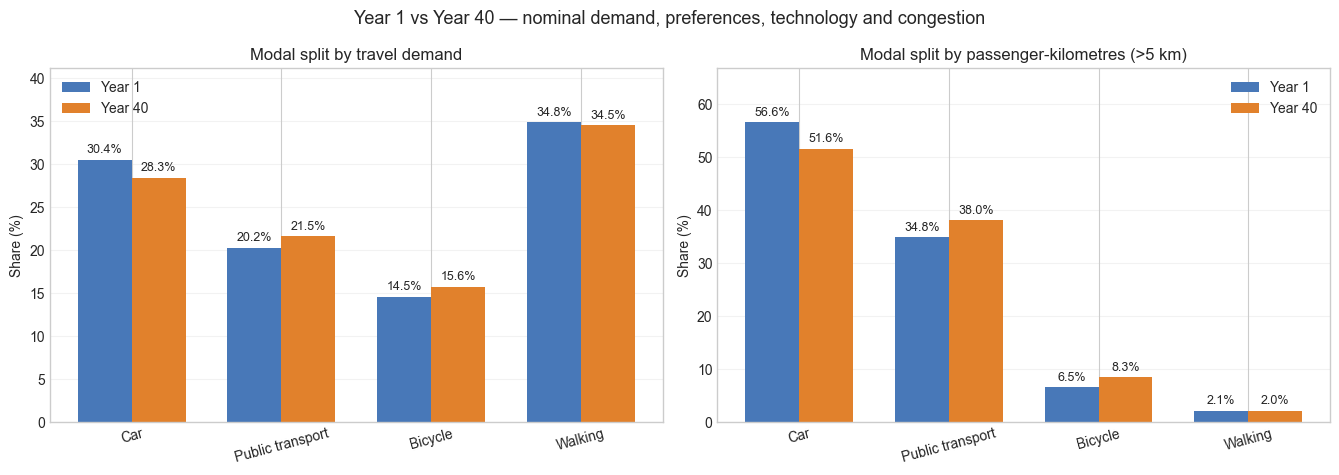

In [ ]:
# The same nominal transport paths are used in every Year-40 comparison.
NOMINAL_PATHS = uc.nominal_paths()
YEAR_CASES = {"Year 1": 0, "Year 40": p.N_YEARS - 1}
PARALLEL_YEAR_RUNS = True
base_mode_result = res_stage0
YEAR_ASSIGNMENT_CACHE = globals().get("YEAR_ASSIGNMENT_CACHE", {})

YEAR_INPUTS = {
    label: uc.native_transport_inputs({
        key: uc.year_parameters(NOMINAL_PATHS, index)[key]
        for key in uc.TRANSPORT_BINDINGS
    })
    for label, index in YEAR_CASES.items()
}

def cache_key(label):
    return (
        id(ctx), id(MEHRSPUR), id(base_mode_result),
        tuple(sorted((key, repr(value)) for key, value in ASSIGNMENT_OPTIONS.items())),
        tuple(sorted(YEAR_INPUTS[label].items())),
    )

def compatible_baseline(assignment):
    if assignment is None or assignment.mode_result is None:
        return False
    nominal_inputs = YEAR_INPUTS["Year 1"]
    return (
        tuple(assignment.mode_result.cache_key) == (*base_mode_result.cache_key, "coupled_msa")
        and tmi.assignment_settings_match(assignment.diagnostics, ASSIGNMENT_OPTIONS,
                                         passthrough_fraction=tmi.DEFAULT_PASSTHROUGH_FRACTION)
        and np.isclose(nominal_inputs["passenger_demand_multiplier"], 1.0)
        and np.isclose(nominal_inputs["road_freight_multiplier"], 1.0)
        and np.isclose(nominal_inputs["pt_asc_shift"], 0.0)
        and np.isclose(nominal_inputs["bike_asc_shift"], 0.0)
        and np.isclose(nominal_inputs["ebike_share"], base_mode_result.scenario["ebike_share"])
    )

candidate = globals().get("coupled_assignment")
if compatible_baseline(candidate):
    YEAR_ASSIGNMENT_CACHE.setdefault(cache_key("Year 1"), candidate)

def run_case(label):
    state = tmi.acquire_native_transport_state(
        ctx, base_mode_result, stage=0,
        corridor_municipalities=corridor_municipalities,
        corridor_context=MEHRSPUR, assignment_settings=ASSIGNMENT_OPTIONS,
        **YEAR_INPUTS[label],
    )
    return label, state["assignment_result"]

missing = [label for label in YEAR_CASES if cache_key(label) not in YEAR_ASSIGNMENT_CACHE]
started = time.perf_counter()
if len(missing) > 1 and PARALLEL_YEAR_RUNS:
    n_jobs = min(len(missing), max(1, (os.cpu_count() or 2) - 1))
    new_results = Parallel(n_jobs=n_jobs, backend="loky")(delayed(run_case)(label) for label in missing)
else:
    n_jobs = 1 if missing else 0
    new_results = [run_case(label) for label in missing]
for label, assignment in new_results:
    YEAR_ASSIGNMENT_CACHE[cache_key(label)] = assignment
YEAR_ASSIGNMENTS = {label: YEAR_ASSIGNMENT_CACHE[cache_key(label)] for label in YEAR_CASES}
assignment_y1, assignment_y40 = YEAR_ASSIGNMENTS.values()
print(f"Calculated {len(missing)} missing case(s) using {n_jobs} worker(s) in {time.perf_counter() - started:.1f} s.")

# Retain numeric transport states for the later stage and plan comparisons.
YEAR_SNAPSHOTS = globals().get("YEAR_SNAPSHOTS", {})
for label, index in YEAR_CASES.items():
    year_params = uc.year_parameters(NOMINAL_PATHS, index)
    tmi.stage_year_snapshot(ctx, base_mode_result, stage_spec=stages[0],
        corridor_context=MEHRSPUR, year_idx=index,
        g_cum=float(year_params["PASSENGER_DEMAND_GROWTH"]), params=year_params,
        assignment_settings=ASSIGNMENT_OPTIONS, snapshots=YEAR_SNAPSHOTS,
        transport_state=tmi.transport_state_from_mode(
            ctx, YEAR_ASSIGNMENTS[label].mode_result, MEHRSPUR.zone_ids))

def corridor_mask(matrix):
    labels = matrix.index.astype(str).to_numpy()
    internal = np.isin(labels, np.asarray(MEHRSPUR.zone_ids, dtype=str))
    return internal[:, None] | internal[None, :]

def weighted_minutes(od, times):
    if times is None:
        return np.nan
    times = times.reindex(index=od.index, columns=od.columns)
    demand, minutes = od.to_numpy(float), times.to_numpy(float)
    valid = corridor_mask(od) & np.isfinite(demand) & np.isfinite(minutes) & (demand > 0)
    return float((demand[valid] * minutes[valid]).sum())

def pt_times(times, access):
    combined = times.get(f"pt_{access}")
    if combined is not None:
        return combined

    ivt = times.get(f"ivt_pt_{access}")
    ovt = times.get(f"ovt_pt_{access}")

    if ivt is None or ovt is None:
        return None
    return ivt + ovt

MODE_ORDER = ["Car passengers", "Public Transport", "Bicycle", "Walking"]

def mode_breakdown(assignment, car_co2_kg_per_vehicle_km):
    result, od, tt = assignment.mode_result, assignment.mode_result.od_by_mode, assignment.mode_result.travel_times
    matrices = {
        "Car passengers": od["drive"],
        "Public Transport": od["pt_walk"] + od["pt_bike"],
        "Bicycle": od["bike"],
        "Walking": od["walk"],
    }
    mask = corridor_mask(od["drive"])
    trips = {
        mode: float(matrix.to_numpy(float)[mask].sum())
        for mode, matrix in matrices.items()
    }
    minutes = {
        "Car passengers": weighted_minutes(od["drive"], tt.get("drive", tt.get("car"))),
        "Public Transport": (
            weighted_minutes(od["pt_walk"], pt_times(tt, "walk"))
            + weighted_minutes(od["pt_bike"], pt_times(tt, "bike"))
        ),
        "Bicycle": weighted_minutes(od["bike"], tt.get("bike")),
        "Walking": weighted_minutes(od["walk"], tt.get("walk")),
    }
    metrics = tmi.extract_corridor_metrics(
        ctx, result, corridor_zone_ids=MEHRSPUR.zone_ids,
        p_co2_kg_per_km=float(car_co2_kg_per_vehicle_km), min_distance_km=5.0,
    )
    shares = {
        "Car passengers": metrics["car_share"],
        "Public Transport": metrics["pt_share"],
        "Bicycle": metrics["bike_share"],
        "Walking": metrics["walk_share"],
    }
    total = sum(trips.values())
    delay = assignment.diagnostics["total_delay_hours"]
    rows = [{
        "Mode": mode,
        "Peak Trips": trips[mode],
        "Trip Share": trips[mode] / max(total, 1e-9),
        "PKM Share (>5 km)": shares[mode],
        "Mode-choice journey time": minutes[mode] / max(trips[mode], 1e-9),
        "Peak Road Congested Time (veh-h)": delay if mode == "Car passengers" else 0.0,
        "Peak Car CO2 (t)": metrics["car_co2_tonnes_peak"] if mode == "Car passengers" else 0.0,
    } for mode in MODE_ORDER]
    rows.append({
        "Mode": "--- Total / System Average ---",
        "Peak Trips": total,
        "Trip Share": 1.0,
        "PKM Share (>5 km)": 1.0,
        "Mode-choice journey time": sum(minutes.values()) / max(total, 1e-9),
        "Peak Road Congested Time (veh-h)": delay,
        "Peak Car CO2 (t)": metrics["car_co2_tonnes_peak"],
    })
    return pd.DataFrame(rows).set_index("Mode")

CAR_CO2_PATH = uc.get_trajectory("CAR_CO2_KG_PER_VEHICLE_KM")
df_y1 = mode_breakdown(assignment_y1, CAR_CO2_PATH[0])
exports.save_outputs("1_7_performance", tables={"year_1_peak": df_y1})
df_y40 = mode_breakdown(assignment_y40, CAR_CO2_PATH[-1])
exports.save_outputs("1_7_performance", tables={"year_40_peak": df_y40})

table_format = {
    "Peak Trips": "{:,.0f}",
    "Trip Share": "{:.2%}",
    "PKM Share (>5 km)": "{:.2%}",
    "Mode-choice journey time": "{:.1f} min",
    "Peak Road Congested Time (veh-h)": "{:,.1f} h",
    "Peak Car CO2 (t)": "{:,.1f} t",
}

print("Year 1 — evening peak-hour results")
_display_indicators(df_y1, table_format, na_rep="–")
print("\nYear 40 — evening peak-hour results")
_display_indicators(df_y40, table_format, na_rep="–")

print("\nComparison of modal split and corridor metrics between Year 1 and Year 40")
modal_comparison = pd.DataFrame({
    "Year 1 Trip Share": df_y1.loc[MODE_ORDER, "Trip Share"],
    "Year 40 Trip Share": df_y40.loc[MODE_ORDER, "Trip Share"],
    "Trip-share change (pp)": 100 * (
        df_y40.loc[MODE_ORDER, "Trip Share"] - df_y1.loc[MODE_ORDER, "Trip Share"]
    ),
    "Year 1 PKM Share": df_y1.loc[MODE_ORDER, "PKM Share (>5 km)"],
    "Year 40 PKM Share": df_y40.loc[MODE_ORDER, "PKM Share (>5 km)"],
    "PKM-share change (pp)": 100 * (
        df_y40.loc[MODE_ORDER, "PKM Share (>5 km)"]
        - df_y1.loc[MODE_ORDER, "PKM Share (>5 km)"]
    ),
})
exports.save_outputs("1_7_performance", tables={"modal_comparison": modal_comparison})
_display_indicators(modal_comparison, {
    "Year 1 Trip Share": "{:.2%}", "Year 40 Trip Share": "{:.2%}",
    "Trip-share change (pp)": "{:+.2f} pp",
    "Year 1 PKM Share": "{:.2%}", "Year 40 PKM Share": "{:.2%}",
    "PKM-share change (pp)": "{:+.2f} pp",
})

annualizers = m._annualizers(p.NOMINAL_PARAMS)
annual_factors = pd.Series({
    "Car passengers": annualizers["car"],
    "Public Transport": annualizers["pt"],
    "Bicycle": annualizers["bike"],
    "Walking": annualizers["walk"],
})
annual_trips_y1 = df_y1.loc[MODE_ORDER, "Peak Trips"] * annual_factors
annual_trips_y40 = df_y40.loc[MODE_ORDER, "Peak Trips"] * annual_factors
annual_trips_y1.loc["--- Total / System Average ---"] = annual_trips_y1.sum()
annual_trips_y40.loc["--- Total / System Average ---"] = annual_trips_y40.sum()
annual_comparison = pd.DataFrame({
    "Year 1 Annual Trips": annual_trips_y1,
    "Year 40 Annual Trips": annual_trips_y40,
    "Year 1 Avg TT": df_y1["Mode-choice journey time"],
    "Year 40 Avg TT": df_y40["Mode-choice journey time"],
    "Year 1 Annual Road Congested Time (veh-h)": df_y1["Peak Road Congested Time (veh-h)"] * annualizers["congestion"],
    "Year 40 Annual Road Congested Time (veh-h)": df_y40["Peak Road Congested Time (veh-h)"] * annualizers["congestion"],
    "Year 1 Annual Car CO2 (t)": df_y1["Peak Car CO2 (t)"] * annualizers["car"],
    "Year 40 Annual Car CO2 (t)": df_y40["Peak Car CO2 (t)"] * annualizers["car"],
})
exports.save_outputs("1_7_performance", tables={"annual_comparison": annual_comparison})
_display_indicators(annual_comparison, {
    "Year 1 Annual Trips": "{:,.0f}", "Year 40 Annual Trips": "{:,.0f}",
    "Year 1 Avg TT": "{:.1f} min", "Year 40 Avg TT": "{:.1f} min",
    "Year 1 Annual Road Congested Time (veh-h)": "{:,.0f} h",
    "Year 40 Annual Road Congested Time (veh-h)": "{:,.0f} h",
    "Year 1 Annual Car CO2 (t)": "{:,.0f} t",
    "Year 40 Annual Car CO2 (t)": "{:,.0f} t",
}, na_rep="–")

# Compare the selected modal-share indicators.
share_panels = [
    ("Trip Share", "Modal split by travel demand"),
    ("PKM Share (>5 km)", "Common-distance-weighted modal split (≥5 km)"),
]
share_panels = [(c, title) for c, title in share_panels if _indicator_group(c) in PERFORMANCE_INDICATORS]
if share_panels:
    x, width = np.arange(len(MODE_ORDER)), 0.36
    labels = ["Car", "Public transport", "Bicycle", "Walking"]
    fig, axes = plt.subplots(1, len(share_panels), figsize=(6.75 * len(share_panels), 4.8), squeeze=False)
    for ax, (column, title) in zip(axes[0], share_panels):
        y1 = 100 * df_y1.loc[MODE_ORDER, column].to_numpy(float)
        y40 = 100 * df_y40.loc[MODE_ORDER, column].to_numpy(float)
        bars1 = ax.bar(x - width / 2, y1, width, label="Year 1", color="#4878b8")
        bars40 = ax.bar(x + width / 2, y40, width, label="Year 40", color="#e1812c")
        ax.bar_label(bars1, [f"{v:.1f}%" for v in y1], padding=3, fontsize=9)
        ax.bar_label(bars40, [f"{v:.1f}%" for v in y40], padding=3, fontsize=9)
        ax.set(title=title, ylabel="Share (%)", xticks=x, xticklabels=labels)
        ax.tick_params(axis="x", rotation=15)
        ax.grid(axis="y", alpha=0.25)
        ax.legend()
        ax.set_ylim(0, max(y1.max(), y40.max(), 1) * 1.18)
    fig.suptitle("Year 1 vs Year 40 — nominal demand, preferences, technology and congestion", fontsize=13)
    fig.tight_layout()
    exports.save_outputs("1_7_year_comparison_modal_split", figure=fig)
    plt.show()


# Part 2 — Model Parameters & System Dynamics

Now that we have established our performance indicators, we examine **what drives them**.

The system is governed by three levels of input:

1. **Demand dynamics** (`code/parameters.py`): how much travel grows by Year 40 (`PASSENGER_DEMAND_GROWTH_Y40`), including the planning horizon and success thresholds.
2. **Mode preferences**: how attractive each mode is. Baseline coefficients (ASCs, time/cost betas, fares) are in `data/transport/config/mode_choice.json`. The Year-40 PT preference shift (`PT_ASC_SHIFT_Y40`) is in `code/parameters.py`. Baseline e-bike share and speed are also in `code/parameters.py`.
3. **Network and service attributes**: percentage changes to PT in-vehicle time, waiting, transfers, access, and egress on selected OD pairs. These encode infrastructure and service packages in `code/stages.py`. You set Stage 1 / Stage 2 values in Part 3.

**2.1** lists current values, grouped according to the 3 levels above. **2.2–2.3** allow an exploration of a subset of the parameters with sliders at **Stage 0**: demand growth, PT preference and e-bikes, and the PT time/quality `%` adjustments.

> **Coupled MSA.** The parameter playground runs mode choice and road assignment together. Each selected setting is compared with a nominal run, with completed calculations cached.

### 2.1 Core Parameter Overview (mandatory task)

Look at the tables below. You will eventually have to select and adapt some of the values to your own case study through the semester. The overview shows which assumptions feed the transport model, the physical indicators, and the later evaluation.

| Table | Level | Contents | File |
|---|---|---|---|
| 1 | Demand dynamics | Horizon, demand growth, success thresholds | `code/parameters.py` |
| 2 | Mode preferences | Year-40 PT preference shift and baseline e-bikes | `code/parameters.py` |
| 3 | Mode preferences | Baseline ASCs, time/cost betas, fares | `data/transport/config/mode_choice.json` |
| 4–5 | Outcome evaluation | Appraisal monetary values, peak hours, discount factor | `code/parameters.py` |
| 6 | Network and service | PT time/capacity `%` improvements | `code/stages.py` |


In [ ]:
import re


def _src(file, key):
    """Link to the line where `key` is defined in code/<file> (file-level link if not found)."""
    lines = (CODE_DIR / file).read_text(encoding="utf-8").splitlines()
    pattern = re.compile(rf'^\s*(?:"{key}"\s*:|{key}\s*=)')
    line = next((i for i, text in enumerate(lines, 1) if pattern.match(text)), None)
    anchor = f"#L{line}" if line else ""
    return f'<a href="../code/{file}{anchor}">{file}</a>'


def _transport_src(file):
    base = "../data/transport" if file.startswith("config/") else "../code/transport_core"
    return f'<a href="{base}/{file}">{file}</a>'


def _show(name, title, rows):
    columns = [
        "Parameter", "Where it is", "Definition", "Baseline Value",
        "Unit", "Spatial Scope", "Direct System Impact",
    ]
    table = pd.DataFrame(rows, columns=columns)
    exports.save_outputs(name, tables={"": table})
    display(HTML(f"<h4>{title}</h4>"))
    display(HTML(table.to_html(escape=False, index=False)))
    return table


stage0 = stages_module.get_stages(p.NOMINAL_PARAMS)[0]

# 1. Macro demand and planning horizon.
demand_rows = [
    ("N_YEARS", _src("parameters.py", "N_YEARS"), "Planning horizon", f"{p.N_YEARS}", "years", "Global", "Length of Year 1 → Year 40 comparison"),
    ("PASSENGER_DEMAND_GROWTH_Y40", _src("parameters.py", "PASSENGER_DEMAND_GROWTH_Y40"), "Total corridor demand growth by Year 40", f"{p.PASSENGER_DEMAND_GROWTH_Y40:.0%}", "fraction", "All 1,223 Canton Zürich zones", "Drives Year 40 traffic volume and congestion"),
    ("MAX_AVG_TT", _src("parameters.py", "MAX_AVG_TT"), "Maximum acceptable average motorized travel time", f"{p.MAX_AVG_TT:.0f}", "minutes", "Corridor-wide", "Acceptability / success threshold"),
    ("PT_SHARE_TARGET", _src("parameters.py", "PT_SHARE_TARGET"), "Target PT modal split", f"{p.PT_SHARE_TARGET:.0%}", "fraction", "Corridor-wide", "Acceptability / success threshold"),
]
demand_df = _show("2_1_demand_dynamics", "1. Demand dynamics (parameters.py)", demand_rows)

# 2. Mode preferences: Year-40 PT shift and Stage 0 e-bikes.
behavior_rows = [
    ("PT_ASC_SHIFT_Y40", _src("parameters.py", "PT_ASC_SHIFT_Y40"), "Common additive shift to both PT ASCs by Year 40", f"{p.PT_ASC_SHIFT_Y40:g}", "utility", "All PT alternatives", "Year-40 PT preference"),
    ("EBIKE_SHARE", _src("parameters.py", "EBIKE_SHARE"), "Share of bicycles that are e-bikes", f"{p.EBIKE_SHARE:.0%}", "fraction", "All corridor travel demand", "Raises effective average bicycle speed"),
    ("EBIKE_SPEED_MULTIPLIER", _src("parameters.py", "EBIKE_SPEED_MULTIPLIER"), "Speed advantage of e-bikes over conventional bicycles", f"{stage0['EBIKE_SPEED_MULTIPLIER']:.1f}x", "multiplier", "All corridor travel demand", "Raises effective average bicycle speed"),
]
behavior_df = _show("2_1_mode_preferences", "2. Mode preferences — Year-40 PT shift and Stage 0 e-bikes", behavior_rows)

# 3. Native FSM utility, time, and cost coefficients.
mode_choice_baseline = ctx.modules["mode_choice_zurich"].load_mode_choice_parameters()

mode_choice_rows = [
    ("ASC_CAR", _transport_src("config/mode_choice.json"), "Base preference for car, independent of time and cost", f"{mode_choice_baseline['ASC_CAR']:g}", "utility", "All mode-choice segments", "Sets baseline logit utility"),
    ("ASC_WALK", _transport_src("config/mode_choice.json"), "Base preference for walking", f"{mode_choice_baseline['ASC_WALK']:g}", "utility", "All mode-choice segments", "Sets baseline logit utility"),
    ("ASC_BIKE", _transport_src("config/mode_choice.json"), "Base preference for bicycle", f"{mode_choice_baseline['ASC_BIKE']:g}", "utility", "All mode-choice segments", "Sets baseline logit utility"),
    ("ASC_PT_WALK", _transport_src("config/mode_choice.json"), "Base preference for PT accessed by walking", f"{mode_choice_baseline['ASC_PT_WALK']:g}", "utility", "All mode-choice segments", "Sets baseline logit utility"),
    ("ASC_PT_BIKE", _transport_src("config/mode_choice.json"), "Base preference for PT accessed by bicycle", f"{mode_choice_baseline['ASC_PT_BIKE']:g}", "utility", "All mode-choice segments", "Sets baseline logit utility"),
    ("B_CAR_TIME", _transport_src("config/mode_choice.json"), "Utility penalty per minute of car travel time", f"{mode_choice_baseline['B_CAR_TIME']:g}", "utility/min", "All mode-choice segments", "Sets baseline logit utility"),
    ("B_WALK_TIME", _transport_src("config/mode_choice.json"), "Utility penalty per minute of walking time", f"{mode_choice_baseline['B_WALK_TIME']:g}", "utility/min", "All mode-choice segments", "Sets baseline logit utility"),
    ("B_BIKE_TIME", _transport_src("config/mode_choice.json"), "Utility penalty per minute of bicycle time", f"{mode_choice_baseline['B_BIKE_TIME']:g}", "utility/min", "All mode-choice segments", "Sets baseline logit utility"),
    ("B_PT_IVT", _transport_src("config/mode_choice.json"), "Utility penalty per minute of PT in-vehicle time", f"{mode_choice_baseline['B_PT_IVT']:g}", "utility/min", "All mode-choice segments", "Sets baseline logit utility"),
    ("B_PT_OVT", _transport_src("config/mode_choice.json"), "Utility penalty per minute of PT out-of-vehicle time", f"{mode_choice_baseline['B_PT_OVT']:g}", "utility/min", "All mode-choice segments", "Sets baseline logit utility"),
    ("B_TRANSFER", _transport_src("config/mode_choice.json"), "Utility penalty per PT transfer", f"{mode_choice_baseline['B_TRANSFER']:g}", "utility/transfer", "All mode-choice segments", "Sets baseline logit utility"),
    ("B_COST", _transport_src("config/mode_choice.json"), "Utility penalty per CHF of car cost", f"{mode_choice_baseline['B_COST']:g}", "utility/CHF", "All mode-choice segments", "Sets baseline logit utility"),
    ("B_PT_FARE", _transport_src("config/mode_choice.json"), "Utility penalty per CHF of PT fare", f"{mode_choice_baseline['B_PT_FARE']:g}", "utility/CHF", "All mode-choice segments", "Sets baseline logit utility"),
    ("CAR_COST_CHF_PER_KM", _transport_src("config/mode_choice.json"), "Car operating cost", f"{mode_choice_baseline['CAR_COST_CHF_PER_KM']:g}", "CHF/km", "All corridor travel demand", "Sets baseline car cost"),
    ("PT_MIN_FARE_CHF", _transport_src("config/mode_choice.json"), "Minimum PT fare", f"{mode_choice_baseline['PT_MIN_FARE_CHF']:g}", "CHF", "All corridor travel demand", "Sets baseline PT fare floor"),
    ("PT_FARE_CHF_PER_KM", _transport_src("config/mode_choice.json"), "PT distance-based fare", f"{mode_choice_baseline['PT_FARE_CHF_PER_KM']:g}", "CHF/km", "All corridor travel demand", "Sets baseline PT fare"),
    ("PT_MAX_FARE_CHF", _transport_src("config/mode_choice.json"), "Maximum PT fare", f"{mode_choice_baseline['PT_MAX_FARE_CHF']:g}", "CHF", "All corridor travel demand", "Sets baseline PT fare ceiling"),
]
mode_choice_df = _show("2_1_baseline_coefficients", "3. Mode preferences — baseline coefficients (mode_choice.json)", mode_choice_rows)

# 4. Economic and environmental valuation.
# General values are defined in NOMINAL_PARAMS in parameters.py.
econ_rows = [
    ("DISCOUNT_RATE", _src("parameters.py", "DISCOUNT_RATE"), "Social discount rate", f"{p.DISCOUNT_RATE:.1%}", "fraction", "Corridor-wide CBA", "Discounts future costs and benefits to present value"),
    ("CAR_CO2_KG_PER_VEHICLE_KM", _src("parameters.py", "CAR_CO2_KG_PER_VEHICLE_KM"), "Car fleet emission factor", f"{p.CAR_CO2_KG_PER_VEHICLE_KM:.3f}", "kg CO₂/vehicle-km", "Car travel", "Converts vehicle-km to physical emissions"),
    ("CO2_VALUE_CHF_PER_TONNE", _src("parameters.py", "CO2_VALUE_CHF_PER_TONNE"), "Carbon value in reference year", f"{p.CO2_VALUE_CHF_PER_TONNE:.1f}", "CHF/tonne CO₂", "Car and rail", "Values each mode at the same carbon price"),
    ("CO2_REFERENCE_YEAR", _src("parameters.py", "CO2_REFERENCE_YEAR"), "Carbon valuation reference year", f"{p.CO2_REFERENCE_YEAR:g}", "calendar year", "Car and rail", "Starting year for carbon-price escalation"),
    ("CO2_VALUE_ANNUAL_GROWTH", _src("parameters.py", "CO2_VALUE_ANNUAL_GROWTH"), "Annual carbon-price growth", f"{p.CO2_VALUE_ANNUAL_GROWTH:.1%}", "fraction/year", "Car and rail", "Compounds the carbon value by calendar year"),
    ("APPRAISAL_START_YEAR", _src("parameters.py", "APPRAISAL_START_YEAR"), "Calendar year of appraisal Year 1", f"{p.APPRAISAL_START_YEAR:g}", "calendar year", "Corridor-wide CBA", "Aligns annual carbon values with the appraisal horizon"),
    ("C_TT_CAR", _src("parameters.py", "C_TT_CAR"), "Value of car travel time", f"{p.C_TT_CAR:.1f}", "CHF/h", "Car travel demand", "Monetizes car travel-time savings"),
    ("C_TT_PT", _src("parameters.py", "C_TT_PT"), "Value of in-vehicle PT travel time", f"{p.C_TT_PT:.2f}", "CHF/person-hour", "PT passengers", "Monetizes PT in-vehicle time savings"),
    ("C_TT_PT_WAITING", _src("parameters.py", "C_TT_PT_WAITING"), "Value of PT waiting time", f"{p.C_TT_PT_WAITING:.2f}", "CHF/person-hour", "PT passengers", "Values initial and transfer waiting"),
    ("C_TT_PT_ACCESS", _src("parameters.py", "C_TT_PT_ACCESS"), "Value of station access and egress", f"{p.C_TT_PT_ACCESS:.2f}", "CHF/person-hour", "PT passengers", "Values access and egress time"),
    ("C_TT_PT_TRANSFER", _src("parameters.py", "C_TT_PT_TRANSFER"), "Value of transfer walking", f"{p.C_TT_PT_TRANSFER:.2f}", "CHF/person-hour", "PT passengers", "Values walking between services"),
]
econ_df = _show("2_1_appraisal_prices", "4. Later evaluation — appraisal prices (parameters.py)", econ_rows)
# 5. Fixed physical and engineering assumptions.
fixed_rows = [
    ("RAIL_ENERGY_WH_PER_GROSS_TONNE_KM", _src("parameters.py", "RAIL_ENERGY_WH_PER_GROSS_TONNE_KM"), "Rail traction energy intensity", f"{p.RAIL_ENERGY_WH_PER_GROSS_TONNE_KM:g}", "Wh/gross tonne-km", "Train services", "Converts supplied train movement and mass to electricity use"),
    ("RAIL_ELECTRICITY_CO2_G_PER_KWH", _src("parameters.py", "RAIL_ELECTRICITY_CO2_G_PER_KWH"), "Rail electricity emission factor", f"{p.RAIL_ELECTRICITY_CO2_G_PER_KWH:.2f}", "g CO₂/kWh", "Train services", "Converts rail electricity use to physical emissions"),
    ("PT_PEAK_SHARE", _src("parameters.py", "PT_PEAK_SHARE"), "PT peak-hour share of weekday trips", f"{p.PT_PEAK_SHARE:.2%}", "fraction", "PT travel demand", "Converts PT peak trips to daily trips"),
    ("CAR_PEAK_SHARE", _src("parameters.py", "CAR_PEAK_SHARE"), "Car peak-hour share of weekday trips", f"{p.CAR_PEAK_SHARE:.2%}", "fraction", "Car travel demand", "Converts car peak trips to daily trips"),
    ("EQUIVALENT_DAYS_PER_YEAR", _src("parameters.py", "EQUIVALENT_DAYS_PER_YEAR"), "Equivalent operating days per year", f"{p.EQUIVALENT_DAYS_PER_YEAR:g}", "days/year", "All modes", "Converts daily flows to annual flows"),
    ("NUMBER_OF_PEAK_HOURS", _src("parameters.py", "NUMBER_OF_PEAK_HOURS"), "Hours with peak congestion and crowding", f"{p.NUMBER_OF_PEAK_HOURS:g}", "hours/day", "Road and PT", "Sets annual exposure to peak delays"),
    ("PT_HEADWAY_BASELINE", _src("parameters.py", "PT_HEADWAY_BASELINE"), "Baseline interval between PT services", f"{stages_module.stage_headway(0, p.NOMINAL_PARAMS):.0f}", "minutes", "Selected rail service", "Reference for frequency and waiting-time changes"),
    ("PT_CAPACITY_BASELINE", _src("parameters.py", "PT_CAPACITY_BASELINE"), "Baseline section comfort threshold", f"{stages_module.stage_capacity(0, p.NOMINAL_PARAMS):,.0f}", "persons/peak hour", "Counting section", "Reference for excess crowding penalties"),
    ("C_NOISE_CAR", _src("parameters.py", "C_NOISE_CAR"), "Noise external cost, car", f"{p.C_NOISE_CAR:.3f}", "CHF/veh-km", "Road network", "NIBA external cost of car travel"),
    ("C_AIR_CAR", _src("parameters.py", "C_AIR_CAR"), "Air-pollution external cost, car", f"{p.C_AIR_CAR:.3f}", "CHF/veh-km", "Road network", "NIBA external cost of car travel"),
    ("C_ACCIDENT_CAR", _src("parameters.py", "C_ACCIDENT_CAR"), "Accident external cost, car", f"{p.C_ACCIDENT_CAR:.3f}", "CHF/veh-km", "Road network", "NIBA external cost of car travel"),
]
fixed_df = _show("2_1_physical_assumptions", "5. Later evaluation — daily conversion, PT service and comfort threshold, NIBA costs", fixed_rows)

# 6. Network and service attributes (Stage 0 baseline = 0%).
intervention_rows = [
    ("travel_time_reduction_pct", _transport_src("interventions.py"), "PT in-vehicle time reduction", "0%", "%", "Targeted OD pairs (e.g. Zürich ↔ Winterthur)", "Shortens PT in-vehicle time"),
    ("speed_increase_pct", _transport_src("interventions.py"), "Operating speed increase", "0%", "%", "Selected bicycle or PT OD pairs", "Reduces travel time on those OD pairs"),
    ("distance_reduction_pct", _transport_src("interventions.py"), "Path-distance / shortcut reduction", "0%", "%", "Selected OD pairs with shorter modeled paths", "Shortens the modelled path"),
    ("initial_wait_reduction_pct", _transport_src("interventions.py"), "Initial waiting-time reduction", "0%", "%", "Corridor rail lines and connecting bus feeders", "Shortens first-board waiting time"),
    ("transfer_wait_reduction_pct", _transport_src("interventions.py"), "Transfer waiting-time reduction (timetable coordination)", "0%", "%", "Transfer hubs (e.g. Winterthur HB, Stadelhofen)", "Shortens wait at transfers"),
    ("transfer_time_reduction_pct", _transport_src("interventions.py"), "Physical transfer-time reduction (platform walking)", "0%", "%", "Upgraded interchange station facilities", "Shortens walk between platforms"),
    ("access_time_reduction_pct", _transport_src("interventions.py"), "First-mile station access-time reduction", "0%", "%", "Station catchment (walk/bicycle radius)", "Shortens access to the station"),
    ("egress_time_reduction_pct", _transport_src("interventions.py"), "Last-mile station egress-time reduction", "0%", "%", "Destination municipal employment zones", "Shortens egress from the station"),
]
intervention_df = _show(
    "2_1_network_service_attributes",
    "6. Network and service attributes (Stage 0 = 0%; Stage 1–2 in Part 3)",
    intervention_rows,
)

print("* Baseline values are loaded directly from data/transport/config/mode_choice.json.")
print("* Table 6 is the Stage 0 baseline (0%). Part 3 sets the Stage 1–2 values.")


Parameter,Where it is,Definition,Baseline Value,Unit,Spatial Scope,Direct System Impact
N_YEARS,parameters.py,Planning horizon,40,years,Global,Length of Year 1 → Year 40 comparison
PASSENGER_DEMAND_GROWTH_Y40,parameters.py,Total corridor demand growth by Year 40,20%,fraction,"All 1,223 Canton Zürich zones",Drives Year 40 traffic volume and congestion
MAX_AVG_TT,parameters.py,Maximum acceptable average motorized travel time,15,minutes,Corridor-wide,Acceptability / success threshold
PT_SHARE_TARGET,parameters.py,Target PT modal split,35%,fraction,Corridor-wide,Acceptability / success threshold


Parameter,Where it is,Definition,Baseline Value,Unit,Spatial Scope,Direct System Impact
PT_ASC_SHIFT_Y40,parameters.py,Common additive shift to both PT ASCs by Year 40,0.1,utility,All PT alternatives,Year-40 PT preference
EBIKE_SHARE,parameters.py,Share of bicycles that are e-bikes,25%,fraction,All corridor travel demand,Raises effective average bicycle speed
EBIKE_SPEED_MULTIPLIER,parameters.py,Speed advantage of e-bikes over conventional bicycles,1.5x,multiplier,All corridor travel demand,Raises effective average bicycle speed


Parameter,Where it is,Definition,Baseline Value,Unit,Spatial Scope,Direct System Impact
ASC_CAR,config/mode_choice.json,"Base preference for car, independent of time and cost",0.5,utility,All mode-choice segments,Sets baseline logit utility
ASC_WALK,config/mode_choice.json,Base preference for walking,2.4,utility,All mode-choice segments,Sets baseline logit utility
ASC_BIKE,config/mode_choice.json,Base preference for bicycle,-0.1,utility,All mode-choice segments,Sets baseline logit utility
ASC_PT_WALK,config/mode_choice.json,Base preference for PT accessed by walking,0,utility,All mode-choice segments,Sets baseline logit utility
ASC_PT_BIKE,config/mode_choice.json,Base preference for PT accessed by bicycle,-1.5,utility,All mode-choice segments,Sets baseline logit utility
B_CAR_TIME,config/mode_choice.json,Utility penalty per minute of car travel time,-0.075,utility/min,All mode-choice segments,Sets baseline logit utility
B_WALK_TIME,config/mode_choice.json,Utility penalty per minute of walking time,-0.1,utility/min,All mode-choice segments,Sets baseline logit utility
B_BIKE_TIME,config/mode_choice.json,Utility penalty per minute of bicycle time,-0.1,utility/min,All mode-choice segments,Sets baseline logit utility
B_PT_IVT,config/mode_choice.json,Utility penalty per minute of PT in-vehicle time,-0.045,utility/min,All mode-choice segments,Sets baseline logit utility
B_PT_OVT,config/mode_choice.json,Utility penalty per minute of PT out-of-vehicle time,-0.08,utility/min,All mode-choice segments,Sets baseline logit utility


Parameter,Where it is,Definition,Baseline Value,Unit,Spatial Scope,Direct System Impact
DISCOUNT_RATE,parameters.py,Social discount rate,2.0%,fraction,Corridor-wide CBA,Discounts future costs and benefits to present value
CAR_CO2_KG_PER_VEHICLE_KM,parameters.py,Car fleet emission factor,0.139,kg CO₂/vehicle-km,Car travel,Converts vehicle-km to physical emissions
CO2_VALUE_CHF_PER_TONNE,parameters.py,Carbon value in reference year,123.2,CHF/tonne CO₂,Car and rail,Values each mode at the same carbon price
CO2_REFERENCE_YEAR,parameters.py,Carbon valuation reference year,2015,calendar year,Car and rail,Starting year for carbon-price escalation
CO2_VALUE_ANNUAL_GROWTH,parameters.py,Annual carbon-price growth,3.0%,fraction/year,Car and rail,Compounds the carbon value by calendar year
APPRAISAL_START_YEAR,parameters.py,Calendar year of appraisal Year 1,2026,calendar year,Corridor-wide CBA,Aligns annual carbon values with the appraisal horizon
C_TT_CAR,parameters.py,Value of car travel time,42.5,CHF/h,Car travel demand,Monetizes car travel-time savings
C_TT_PT,parameters.py,Value of in-vehicle PT travel time,26.52,CHF/person-hour,PT passengers,Monetizes PT in-vehicle time savings
C_TT_PT_WAITING,parameters.py,Value of PT waiting time,26.52,CHF/person-hour,PT passengers,Values initial and transfer waiting
C_TT_PT_ACCESS,parameters.py,Value of station access and egress,26.52,CHF/person-hour,PT passengers,Values access and egress time


Parameter,Where it is,Definition,Baseline Value,Unit,Spatial Scope,Direct System Impact
RAIL_ENERGY_WH_PER_GROSS_TONNE_KM,parameters.py,Rail traction energy intensity,30,Wh/gross tonne-km,Train services,Converts supplied train movement and mass to electricity use
RAIL_ELECTRICITY_CO2_G_PER_KWH,parameters.py,Rail electricity emission factor,19.58,g CO₂/kWh,Train services,Converts rail electricity use to physical emissions
PT_PEAK_SHARE,parameters.py,PT peak-hour share of weekday trips,9.46%,fraction,PT travel demand,Converts PT peak trips to daily trips
CAR_PEAK_SHARE,parameters.py,Car peak-hour share of weekday trips,10.49%,fraction,Car travel demand,Converts car peak trips to daily trips
EQUIVALENT_DAYS_PER_YEAR,parameters.py,Equivalent operating days per year,300,days/year,All modes,Converts daily flows to annual flows
NUMBER_OF_PEAK_HOURS,parameters.py,Hours with peak congestion and crowding,4,hours/day,Road and PT,Sets annual exposure to peak delays
PT_HEADWAY_BASELINE,parameters.py,Baseline interval between PT services,20,minutes,Selected rail service,Reference for frequency and waiting-time changes
PT_CAPACITY_BASELINE,parameters.py,Baseline section comfort threshold,"11,352",persons/peak hour,Counting section,Reference for excess crowding penalties
C_NOISE_CAR,parameters.py,"Noise external cost, car",0.015,CHF/veh-km,Road network,NIBA external cost of car travel
C_AIR_CAR,parameters.py,"Air-pollution external cost, car",0.019,CHF/veh-km,Road network,NIBA external cost of car travel


Parameter,Where it is,Definition,Baseline Value,Unit,Spatial Scope,Direct System Impact
travel_time_reduction_pct,interventions.py,PT in-vehicle time reduction,0%,%,Targeted OD pairs (e.g. Zürich ↔ Winterthur),Shortens PT in-vehicle time
speed_increase_pct,interventions.py,Operating speed increase,0%,%,Selected bicycle or PT OD pairs,Reduces travel time on those OD pairs
distance_reduction_pct,interventions.py,Path-distance / shortcut reduction,0%,%,Selected OD pairs with shorter modeled paths,Shortens the modelled path
initial_wait_reduction_pct,interventions.py,Initial waiting-time reduction,0%,%,Corridor rail lines and connecting bus feeders,Shortens first-board waiting time
transfer_wait_reduction_pct,interventions.py,Transfer waiting-time reduction (timetable coordination),0%,%,"Transfer hubs (e.g. Winterthur HB, Stadelhofen)",Shortens wait at transfers
transfer_time_reduction_pct,interventions.py,Physical transfer-time reduction (platform walking),0%,%,Upgraded interchange station facilities,Shortens walk between platforms
access_time_reduction_pct,interventions.py,First-mile station access-time reduction,0%,%,Station catchment (walk/bicycle radius),Shortens access to the station
egress_time_reduction_pct,interventions.py,Last-mile station egress-time reduction,0%,%,Destination municipal employment zones,Shortens egress from the station


* Baseline values are loaded directly from data/transport/config/mode_choice.json.
* Table 6 is the Stage 0 baseline (0%). Part 3 sets the Stage 1–2 values.


### 2.2 Parameter Playground — Year 1 vs. Year 40 (tutorial/supporting task)

Use the sliders to see how the **three levels** in 2.1 play out from **Year 1** to **Year 40** on the **current network (Stage 0)**.

- **Demand** (`PASSENGER_DEMAND_GROWTH_Y40`) — cumulative travel demand by Year 40. Year 1 stays at today’s demand. As roads near capacity, Year 40 congested time can rise sharply.
- **Preferences and cycling technology** (`PT_ASC_SHIFT_Y40`, `EBIKE_SHARE`) — a stronger PT preference, or faster cycling, shifts travel off the car, which lowers $\text{CO}_2$ and can ease road congestion.
- **Network and service** (the six PT `%` cuts: in-vehicle time, initial wait, transfer wait, transfer walk, access, egress) — shorter PT times also shift mode shares.

**Interaction:** the same demand growth produces more delay when car stays attractive than when PT preference or PT quality improves.

Choose tab names and supported controls in `PLAYGROUND_TABS` below. Expand **Supported controls** to see the available keys. Omitted controls keep their nominal values; configuration errors appear above the tabs. Use **Run coupled MSA** to calculate the selected settings. Save Stage 1 / Stage 2 packages in Part 3.

The e-bike-share slider sets the Year-40 share; Year 1 retains the configured baseline share. Other nominal transport paths come from `parameters.py`.


In [ ]:
# Choose the tabs and controls; supported keys are listed in the dashboard.
PLAYGROUND_TABS = {
    "Demand": ["PASSENGER_DEMAND_GROWTH_Y40"],
    "Mode preferences": ["PT_ASC_SHIFT_Y40"],
    "Cycling": ["EBIKE_SHARE"],
    "PT infrastructure and service": [
        "travel_time_reduction_pct", "initial_wait_reduction_pct",
        "transfer_wait_reduction_pct", "transfer_time_reduction_pct",
        "access_time_reduction_pct", "egress_time_reduction_pct",
    ],
}

PARAMETER_STAGE_SPECS = stages_module.get_stages(p.NOMINAL_PARAMS)

if callable(globals().get("PARAMETER_STATE", {}).get("close")):
    PARAMETER_STATE["close"]()

PARAMETER_UI, PARAMETER_STATE = tmi.parameter_playground_dashboard(
    ctx,
    PARAMETER_STAGE_SPECS,
    corridor_zone_ids=corridor_zones,
    corridor_municipalities=p.CORRIDOR_MUNICIPALITIES,
    demand_growth_y40=p.PASSENGER_DEMAND_GROWTH_Y40,
    simulation_params=p.NOMINAL_PARAMS,
    reference_mode_result=res_stage0,
    reference_year_assignments=YEAR_ASSIGNMENTS,
    control_groups=PLAYGROUND_TABS,
)

display(PARAMETER_UI)


## 2.3 Sensitivity dashboard (tutorial/supporting task)

The following cell runs a one-at-a-time sensitivity sweep of the Section 2.2 Stage 0 controls: each parameter is varied while the others stay at their defaults, and the figures show how Year-40 indicators respond.

- **Demand:** `PASSENGER_DEMAND_GROWTH_Y40`
- **Mode preferences:** `PT_ASC_SHIFT_Y40`, `EBIKE_SHARE`, `EBIKE_SPEED_MULTIPLIER`
- **Network and service:** `travel_time_reduction_pct`, `initial_wait_reduction_pct`, `transfer_wait_reduction_pct`, `transfer_time_reduction_pct`, `access_time_reduction_pct`, `egress_time_reduction_pct`

**What you get**

1. A **heatmap** — each cell is the largest relative change of one indicator when that slider is moved over its range. Darker means a stronger response. Rows include the Part 1 indicators (`avg_travel_time_min`, `congestion_delay_hours`, `co2_tonnes`, `total_demand`) plus modal shares and car-km.
2. A **dropdown** — pick one slider to see Year-40 curves versus that slider. The dotted line is the default value.

### What to look for

1. **Steep vs flat** — which indicators respond most strongly to each slider.
2. **Demand growth** — `PASSENGER_DEMAND_GROWTH_Y40` changes final-year travel demand and congestion.
3. **Mode-choice levers** — `PT_ASC_SHIFT_Y40`, e-bikes, and the PT `%` cuts change modal split, travel time, and $\text{CO}_2$.
4. **Curves** — near capacity, extra demand can raise delay faster than proportionally.
5. **What to document** — large heatmap cells are assumptions to source.

The sweep runs coupled mode choice and road assignment at Year 40, reusing the prepared corridor and matching nominal result. Independent points are distributed across `SWEEP_WORKERS`; completed-point messages show progress and convergence. Set `RUN_PARAMETER_SWEEP = True` to run this optional analysis. Allow tens of minutes for a multi-parameter sweep. Results remain in `SWEEP_RESULTS` for plotting.


In [ ]:
RUN_PARAMETER_SWEEP = False  # Optional native calculations; allow tens of minutes.
SWEEP_WORKERS = 4

if RUN_PARAMETER_SWEEP:
    
    SWEEP_PARAMETERS = [
        "PASSENGER_DEMAND_GROWTH_Y40",
        "PT_ASC_SHIFT_Y40",
        "EBIKE_SHARE",
        "travel_time_reduction_pct",
        #"initial_wait_reduction_pct",
        #"transfer_wait_reduction_pct",
        #"transfer_time_reduction_pct",
        #"access_time_reduction_pct",
        #"egress_time_reduction_pct",
    ]

    REFERENCE_MODE_RESULT = res_stage0

    SWEEP_RESULTS = tmi.parameter_objective_sweeps(
        ctx,
        PARAMETER_STAGE_SPECS,
        SWEEP_PARAMETERS,
        corridor_zone_ids=corridor_zones,
        corridor_municipalities=p.CORRIDOR_MUNICIPALITIES,
        slider_specs=PARAMETER_STATE["slider_specs"],
        n_points=5,
        simulation_params=p.NOMINAL_PARAMS,
        assignment_method="MSA",
        reference_mode_result=REFERENCE_MODE_RESULT,
        corridor_context=MEHRSPUR,
        precomputed_year_assignments=YEAR_ASSIGNMENTS,
        simulation_assignment_settings=ASSIGNMENT_OPTIONS,
        n_jobs=SWEEP_WORKERS,
    )

    SWEEP_UI = tmi.plot_parameter_objective_sweeps(
        SWEEP_RESULTS,
        PARAMETER_STATE["slider_specs"],
    )
    display(SWEEP_UI)
else:
    print("Optional native sensitivity sweep skipped. Set RUN_PARAMETER_SWEEP = True to calculate it.")


Optional native sensitivity sweep skipped. Set RUN_PARAMETER_SWEEP = True to calculate it.


# Part 3 — Infrastructure stages

### 3.1 Infrastructure Stage Specification (mandatory task)

A **stage** is a distinct physical and operational state of the transport system. 

Each stage bundles a coordinated set of physical interventions that modify certain parameters in the Canton Zürich transport model.

Define two independently deployable packages for your project in the named `PACKAGES['stations']` and `PACKAGES['tunnel']` entries in `code/stages.py`. Keep each package's `railway_expansions`, `mobility_hubs` and `appraisal` assumptions together. `COMBINED_EFFECTS["railway_expansions"]` below them defines railway bonuses available only when both packages operate. Replace their contents with your own interventions. The model assembles four transport configurations: baseline, either package alone, and both together.

When specifying each package in `code/stages.py`, you should consider:
1. **Physical scope: what actually gets built or changed.** 
    - Every stage is a bundle of interventions represented by one or more of the four keys that the transport model consumes ([`intervention_keys` in transport_model_interface.py](../code/transport_model_interface.py)): [`railway_expansions`](../code/stages.py) (PT network), [`bike_highways`](../code/stages.py) (bicycle network), [`road_capacity`](../code/stages.py) (car network), and [`mobility_hubs`](../code/stages.py) (station access/transfer). 
    - A stage does not need all four keys. `section_time_saving_min` also applies a fixed saving to the mode and routes selected by `parameters.SECTION`, including through journeys whose endpoints lie outside the municipal corridor.

    >**IMPORTANT: Mode-specific interventions are represented in different ways in the model.**
    >- **Public transport:** [`railway_expansions`](../code/transport_core/interventions.py) modify selected PT travel time skim and distance skim components, including in-vehicle, waiting, transfer, access, egress, and distance values.
    >   - They only rescale OD pairs that already have a PT connection in the baseline travel time skims. A genuinely new line serving a currently unserved OD pair cannot be represented this way and would require regenerating the underlying PT travel time skims.
    >- **Bicycle:** [`bike_highways`](../code/transport_core/interventions.py) modify bicycle travel time skims and distance skims for selected OD pairs.
    >   - Same limitation as PT: only OD pairs already reachable by bicycle in the baseline travel time skims can be rescaled. A route through a currently unreachable area cannot be created this way.
    >- **Walking and station access:** [`mobility_hubs`](../code/transport_core/interventions.py) modify walking or bicycle access, egress, waiting, and transfer time of PT alternatives around selected stations. 
    >   - Mobility hubs do not change standalone walking times. For a fixed saving on an existing walking route, select `SECTION['mode'] = 'WALK'`, prepare its coverage, and set `section_time_saving_min`. A new connection still requires updated network/skims.
    >- **Road (cars):** [`road_capacity`](../code/stages.py) edits **individual links** on an explicit car network (capacity, speed, free-flow time). Car traffic assignment then loads demand onto those links, so a local change can reroute vehicles and change congestion elsewhere. This is unlike PT and bicycle stages simply rescale selected OD travel-time skim cells. 
    >   - See Section 3.2 for instructions on identifying, modifying, and validating road links.  
2. **Spatial scope: where the effect applies.** 
    - Interventions are targeted either via [`area_pairs`](../code/stages.py) (specific OD pairs, e.g. a rail upgrade between two municipalities) or [`zones`](../code/stages.py) (a station's catchment area, e.g. improved access/egress at one hub). 
    - Be explicit about which OD pairs or zones are affected. An intervention without the required spatial selector normally does not affect OD pairs, and does not automatically apply corridor-wide.
3. **Magnitude: how large the effect is, and why.**
    - Every `*_reduction_pct` / `*_increase_pct` value should trace back to something concrete: an engineering estimate, a comparable completed project, or a timetable/waiting-time calculation.
    - Document the source in your final report.
4. **Behavioral response follows the physical intervention.**
    - MehrSpur uses the same baseline ASCs, time/cost sensitivities and e-bike share in every stage. An individual station upgrade does not change preferences across the whole model.
    - Model its benefits through the affected journey components instead. Common future scenario conditions apply to all alternatives; stages modify physical journey components.
5. **Independent packages and physical configurations.**
    - Stage 1 is the station package; Stage 2 is the tunnel package. Either can open first, and construction can overlap.
    - The four transport configurations are baseline (`0`), stations only (`1`), tunnel only (`2`), and both packages (`3`). These IDs identify configurations, not construction order.
    - Each configuration starts from baseline skims. Section savings are **1 minute** for stations, **4 minutes** for the tunnel, and **6 minutes** combined (including a one-minute combined-package bonus), capped by available in-vehicle time. Comfort-capacity additions are **10%**, **15%**, and **30%** of baseline.
    - Headway reductions are 1 minute for stations, 3 minutes for the tunnel, and 5 minutes combined, including a one-minute combined-package bonus. From the 20-minute baseline these give headways of 19, 17 and 15 minutes. Existing initial and transfer waiting skims on the selected service OD pairs are reduced proportionally by 5%, 15% and 25%. With an ideal half-headway wait, these correspond to savings of 0.5, 1.5 and 2.5 minutes; actual OD savings depend on the baseline skim. The `capacity_increase` values in each package's `railway_expansions` entries add fractions of `PT_CAPACITY_BASELINE`. Hub access, egress and transfer improvements use their own location selectors. 
6. **Costs follow the packages that open (these will be used in future notebooks).**
    - Each package's `appraisal["capital_cost_chf"]` sets its investment: stations cover A3–A5; the tunnel/Winterthur package covers A0–A2. The model derives the runtime `C_INV_STAGE1` and `C_INV_STAGE2` values from these entries. Annual operating and maintenance costs are each open package's base investment × `OPEX_RATE` × `OPEX_MULTIPLIER`.
    - Set each package's `appraisal["construction_co2_tonnes"]` in `stages.py`; an omitted entry means zero. These are separate physical tonnes, valued at the common carbon price; operating train emissions remain separate. Plans determine when construction emissions occur.
    - Set `lifetime_years` and `capital_share` in each package's `appraisal` block to value the remaining life of eligible construction capital at the appraisal horizon. A zero `capital_share` gives no residual credit. These assumptions affect appraisal, not transport.
7. **Deliverability timing: when could this stage plausibly exist?** 
    - You don't set this here (that's a plan decision in Part 4 — see the Parameter/Stage/Plan distinction there), but a stage's assumptions should be realistic for *some* deliverable year. Therefore, don't assume technology or capacity that wouldn't exist yet.
8. **Internal consistency: check results in Section 3.3 before moving on.** 
    - After defining a stage, run [`compare_stages_summary`](../code/transport_model_interface.py) and sanity-check that travel time, modal split, and congested time move in the direction you'd expect. An implausible result usually means an effect was applied to the wrong OD pairs/zones or an unrealistic magnitude.


---

Below is a description of the stages specified for this notebook's example. [`code/stages.py`](../code/stages.py) is the source of truth for the detailed selectors and percentages.

* **Stage 0 (Baseline / Do Nothing):** Prepared demand and multimodal skims, no project saving. The timetable scaling uses a 20-minute reference headway. For section crowding, the baseline comfort threshold is **11,352 passengers per peak hour**, equivalent to the assumed 120,000 daily passengers at the 9.46% peak share. This is a calibrated comfort threshold, not measured seating capacity.
* **Stage 1 – Local Stations & Access Package (configuration 1):** One minute of section PT saving and +10% comfort capacity. Dietlikon, Bassersdorf and Wallisellen receive their configured hub access, egress and transfer improvements. The reference headway falls from 20 to 19 minutes.
* **Stage 2 - Tunnel & Winterthur Hub only (configuration 2):** Four minutes of section PT saving and +15% comfort capacity, plus the Winterthur hub. A 17-minute headway replaces the 20-minute reference, reducing initial and transfer waiting on the selected railway OD pairs.
* **Both stages - Tunnel and Hubs (configuration 3):** Six minutes of section PT saving, +30% comfort capacity, a 15-minute headway and all four hubs. Each hub retains its own package's improvements.

The fixed section saving affects modeled and supplementary passengers. Hub access/egress, waiting and transfer effects continue to apply through their existing selectors to modeled journeys, they are not automatically added to the supplementary through cohort. Ordinary time savings are valued throughout the day, while excess section crowding and road congestion are valued for four peak hours over 300 equivalent days per year.

In [ ]:
# Use the stage definitions loaded for this kernel.
STAGE_SPECS = stages_module.get_stages(p.NOMINAL_PARAMS)
STAGE_OVERVIEW, STAGE_INTERVENTIONS = tmi.stage_specification_tables(
    STAGE_SPECS, p.NOMINAL_PARAMS
)
exports.save_outputs("3_1_stage_specifications", tables={
    "overview": STAGE_OVERVIEW, "interventions": STAGE_INTERVENTIONS,
})
display(STAGE_OVERVIEW)
display(STAGE_INTERVENTIONS)


,Name,Rail,Bike,Hubs,Road,Headway (min),Section saving (min),PT capacity,Incremental CAPEX (CHF),Incremental OPEX (CHF/year),Construction emissions (total tCO2e)
Stage,,,,,,,,,,,
0,Stage 0 – Baseline Network,0,0,0,0,20.0,0.0,11352.0,0.000000e+00,0.0,0.0
1,Stage 1 – Local Stations & Access Package,1,0,1,0,19.0,1.0,12487.2,9.250000e+08,18500000.0,0.0
2,Stage 2 - Tunnel & Winterthur Hub only,1,0,1,0,17.0,4.0,13054.8,2.302600e+09,46052000.0,300000.0
3,Both stages - Tunnel and Hubs,1,0,2,0,15.0,6.0,14757.6,3.227600e+09,64552000.0,300000.0


,Stage,Type,Intervention,Spatial scope,Effects
0,1,railway_expansions,Corridor service frequency,136 area pairs | both directions,"initial_wait_reduction_pct=5.000000000000004, ..."
1,1,mobility_hubs,"Station Upgrades (Dietlikon, Bassersdorf, Wall...",municipality_name=Dietlikon; municipality_name...,"access_time_reduction_pct=25.0, transfer_time_..."
2,2,railway_expansions,Corridor service frequency,136 area pairs | both directions,"initial_wait_reduction_pct=15.000000000000002,..."
3,2,mobility_hubs,Winterthur Multimodal Hub (A1),municipality_name=Winterthur,"access_time_reduction_pct=25.0, transfer_time_..."
4,3,railway_expansions,Corridor service frequency,136 area pairs | both directions,"initial_wait_reduction_pct=25.0, transfer_wait..."
5,3,mobility_hubs,"Station Upgrades (Dietlikon, Bassersdorf, Wall...",municipality_name=Dietlikon; municipality_name...,"access_time_reduction_pct=25.0, transfer_time_..."
6,3,mobility_hubs,Winterthur Multimodal Hub (A1),municipality_name=Winterthur,"access_time_reduction_pct=25.0, transfer_time_..."


The dashboard below simulates each stage. The left map shows the resulting values, and the right map isolates percentage changes from Stage 0. Switch between road, PT, bicycle, walking, and PT-access attributes, and aggregate OD desire lines by municipality or display individual FSM zones.
PT attributes show the journey with walking access to stations. **Total PT journey time** includes in-vehicle and out-of-vehicle components; it is not walking time. Choose a setting once and wait for the status to finish.


In [ ]:
if callable(globals().get("STAGE_MAP_STATE", {}).get("close")):
    STAGE_MAP_STATE["close"]()

# Compare actual stage values with changes from the Stage 0 baseline.
STAGE_MAP_UI, STAGE_MAP_STATE = tmi.stage_value_variation_dashboard(
    ctx, MEHRSPUR, STAGE_SPECS
)
display(STAGE_MAP_UI)

### 3.2 Editing stage interventions (tutorial/supporting task + mandatory task)

Explore temporary changes to the packages in `code/stages.py`. **Edit package** selects a package; its changes also update every state containing that package. **Combined-only additions** affect the combined state only. The available pages follow the intervention types configured in the packages. Use **Add page** to try another supported type.

1. Select a package and an intervention page. Add a named intervention, or select an existing entry and use **Update selected**. Check the intervention list and confirmation. **Enabled** switches an entry off/on without deleting it; **Reset** restores that page's loaded definitions.
2. For PT and bicycle effects, choose the origin, destination and percentage change. For hubs, choose the catchment area and access/egress/transfer effect. Updating one effect preserves the entry's other effects and selectors. Section/service settings are shown but edited in `stages.py`.
3. For roads, search for directed links, select the required directions and apply capacity, lanes or speed. Check the before/after audit.
4. Maps are optional: click **Preview map** when needed. Editing and comparison tables work without a map.

These changes stay in memory. `EDITED_STAGE_SPECS` and `ROAD_STAGE_CORRIDORS` feed Section 3.3, which calculates transport outcomes. Save final package definitions in `code/stages.py`; the editor's expandable definitions box provides text to copy. Rerunning the editor cell or restarting the kernel discards temporary edits.


> Run the editor cell once, then use its controls. Rerun the comparison cell freely; it preserves the editor's working copy. After saving final changes in `stages.py`, restart the kernel and run the notebook to load them.


In [ ]:
# Pages follow the configured packages. Optionally select supported keys:
# ["railway_expansions", "bike_highways", "mobility_hubs", "road_capacity"]
EDITOR_INTERVENTION_TYPES = None

if callable(globals().get("STAGE_EDIT_STATE", {}).get("close")):
    STAGE_EDIT_STATE["close"]()

STAGE_EDIT_UI, STAGE_EDIT_STATE = tmi.stage_intervention_editor(
    ctx, MEHRSPUR, STAGE_SPECS,
    packages=stages_module.PACKAGES,
    combined_effects=stages_module.COMBINED_EFFECTS,
    assemble_stages=lambda packages, combined: stages_module.get_stages(
        p.NOMINAL_PARAMS, packages=packages, combined_effects=combined
    ),
    intervention_types=EDITOR_INTERVENTION_TYPES,
)
EDITED_STAGE_SPECS = STAGE_EDIT_STATE["stage_specs"]
ROAD_STAGE_CORRIDORS = STAGE_EDIT_STATE["corridors"]
ROAD_STAGE_LINK_AUDITS = STAGE_EDIT_STATE["road_audits"]
display(STAGE_EDIT_UI)


#### Compare the edited inputs

Select a state and attribute, then click **Compare values**. The default reference is the **original selected stage**, so the table isolates your edits. Select **Stage 0** to compare the whole package against baseline. Switch an intervention off/on in the editor and compare again to inspect its contribution.

The table shows changed input values. Municipality values are unweighted averages of changed OD cells, not passenger-weighted outcomes. **Preview map** draws an optional static map of the largest changes; it can show the reference values, edited values or differences. A notice marks results as outdated after edits. Use Section 3.3 to calculate modal shares, delays and other outcomes.


In [ ]:
if callable(globals().get("STAGE_CHANGE_STATE", {}).get("close")):
    STAGE_CHANGE_STATE["close"]()

STAGE_CHANGE_UI, STAGE_CHANGE_STATE = tmi.stage_value_variation_dashboard(
    ctx, MEHRSPUR, EDITED_STAGE_SPECS,
    road_contexts=ROAD_STAGE_CORRIDORS,
    original_stage_specs=STAGE_EDIT_STATE["original_stage_specs"],
    original_road_contexts=STAGE_EDIT_STATE["original_road_contexts"],
    editor_state=STAGE_EDIT_STATE,
)
display(STAGE_CHANGE_UI)


## 3.3 Comparing Performance Indicators Across Stages (mandatory task)

The maps above verify what was changed, and this section evaluates what those changes do to the transport system. Results reflect two interacting forces:

1. **Nominal year-specific assumptions:** passenger demand, PT preference, e-bike share, road freight and car emissions factors.
2. **Stage configuration:** the original or interactively edited travel time skims, mobility hubs and link-level road network.

- **Year 1** compares complete stage packages at reference demand.
- **Year 40** tests the same packages under the nominal demand, PT preference, e-bike and freight paths, with congestion and modal feedback.

The calculation automatically uses `EDITED_STAGE_SPECS` and `ROAD_STAGE_CORRIDORS` when Section 3.2 has been run. Otherwise, it uses the definitions from `stages.py` and the Stage 0 road network.

> Execution has two phases: Year-1 stage assignments, then any missing Year-40 assignments. Both show progress and use up to `N_JOBS` worker processes. Each phase can take several minutes; completed Year-40 snapshots are reused.
All states and both years use the same buffered reporting zones. The tables report peak-hour person-trips, physical car/PT in-vehicle time (car time includes passenger road delay), passenger delay in person-hours and car-only CO2. The system time average covers car and PT; it excludes active-mode time and PT access/waiting. These measures differ from the perceived journey times and background-inclusive vehicle delay in Section 1.7. Existing Year-40 states are reused.

The tables retain absolute results. Charts show **alternative minus the same-year baseline**: negative time, delay and emissions changes mean reductions; modal-share changes are percentage points. Trip totals and modal-share shifts remain contextual. Each subplot has its own axis range: compare the printed values and units, not bar lengths across different indicators.

Active-mode shares in the table and plots refer to Year 1; active-mode trip totals are available for both years.

The project indicators show section reference-pair in-vehicle time, load/capacity and peak crowding discomfort, expressed in equivalent minutes; these are not additional physical travel minutes. Section load includes modeled and supplementary passengers. Waiting (initial plus transfer), access, egress and transfer walking use the **same baseline OD/submode passengers in each year** across all alternatives; supplementary passengers receive no hub-component assumptions. Component averages include all modeled baseline PT trips, so benefits concentrated at a few hubs can appear small in these corridor-wide means. The section reference uses its fixed nominal reference-pair weights. These physical indicators are not a replacement for the matched welfare appraisal.

Run the calculation cell once, then use the separate display cell to change indicators without repeating assignments. Missing or inactive indicators appear as `n/a`. Use `STAGE_PLOT_INDICATORS` and `PROJECT_PLOT_INDICATORS` in Section 1.7 to choose individual subplots.


In [ ]:
# 1. Simulate expansion stages (Stage 1, Stage 2, ...) in parallel worker
# processes -- same joblib/loky pattern as the MSA convergence test (§1.6)
# and the parameter sensitivity sweep (§Part 2).
# Reuse the nominal Year-1 assignment from Section 1.7.
baseline_stage_result = assignment_y1.mode_result
stage_results = {0: baseline_stage_result}
stage_metrics = {0: tmi.extract_corridor_metrics(ctx, baseline_stage_result, MEHRSPUR.zone_ids)}
ACTIVE_STAGE_SPECS = globals().get("EDITED_STAGE_SPECS", STAGE_SPECS)

stage_ids = [s for s in sorted(ACTIVE_STAGE_SPECS) if s != 0]
N_JOBS = min(max(1, len(stage_ids)), 4, max(1, (os.cpu_count() or 2) - 1))

def _simulate_stage(s):
    stage_name = ACTIVE_STAGE_SPECS[s].get("name", f"Stage {s}")
    stage_corridor = globals().get("ROAD_STAGE_CORRIDORS", {}).get(s, MEHRSPUR)
    res, metrics = tmi.run_simulation(
        ctx,
        stage=s,
        stage_specs=ACTIVE_STAGE_SPECS,
        corridor_municipalities=corridor_municipalities,
        corridor_context=stage_corridor,
        assignment_settings=ASSIGNMENT_OPTIONS,
    )
    return s, stage_name, res, metrics

print(f"Year 1: simulating {len(stage_ids)} infrastructure stage(s) ({N_JOBS} worker(s))...")
from joblib import parallel_config
with parallel_config(backend="loky", inner_max_num_threads=1):
    outcomes = Parallel(n_jobs=N_JOBS, verbose=5)(
        delayed(_simulate_stage)(s) for s in stage_ids
    )

for s, stage_name, res, metrics in sorted(outcomes, key=lambda item: item[0]):
    print(f"  {stage_name}: Year-1 assignment complete.")
    stage_results[s] = res
    stage_metrics[s] = metrics

print("\nYear-1 stages complete. Preparing the Year-40 comparisons...")

# 2. Generate the four side-by-side indicator tables ourselves (display_tables=False)
# so we can interleave each one with a bar chart of the same values, right below it.
df_car, df_pt, df_active, df_system = tmi.compare_stages_summary(
    context=ctx,
    stage_specs=ACTIVE_STAGE_SPECS,
    corridor_zone_ids=MEHRSPUR.zone_ids,
    corridor_municipalities=p.CORRIDOR_MUNICIPALITIES,
    stage_results=stage_results,
    corridor_contexts_by_stage={
        s: globals().get("ROAD_STAGE_CORRIDORS", {}).get(s, MEHRSPUR)
        for s in ACTIVE_STAGE_SPECS
    },
    display_tables=False,
    assignment_settings=ASSIGNMENT_OPTIONS,
    year_snapshots=YEAR_SNAPSHOTS,
    n_jobs=N_JOBS, progress=True,
    reporting_references={0: assignment_y1.mode_result, p.N_YEARS - 1: assignment_y40.mode_result},
)

exports.save_outputs("3_3_stage_indicators", tables={
    "car": df_car, "pt": df_pt, "active": df_active, "system": df_system,
})

for name, frame in (("car", df_car), ("pt", df_pt), ("active", df_active), ("system", df_system)):
    exports.save_outputs(f"3_3_stage_{name}_changes", tables={"": _baseline_change_table(
        frame, ACTIVE_STAGE_SPECS[0]["name"],
        percentage_point_columns=[column for column in frame if "Share" in column],
    )})

# Retain compact section and fixed-passenger component indicators for plotting.
STAGE_PROJECT_ROWS = {}
for stage, specification in ACTIVE_STAGE_SPECS.items():
    row = {}
    for label, year in (("Year 1", 0), ("Year 40", p.N_YEARS - 1)):
        matches = [entry for key, entry in YEAR_SNAPSHOTS.items() if key[:2] == (stage, year)]
        if len(matches) != 1:
            raise ValueError(f"Expected one current snapshot for configuration {stage}, {label}.")
        row.update({f"{label} {key}": value for key, value in _project_indicator_row(matches[0]).items()})
    STAGE_PROJECT_ROWS[specification["name"]] = row
STAGE_PROJECT_INDICATORS = pd.DataFrame.from_dict(STAGE_PROJECT_ROWS, orient="index")

exports.save_outputs("3_3_stage_indicators", tables={"project": STAGE_PROJECT_INDICATORS})

exports.save_outputs("3_3_stage_project_changes", tables={"": _baseline_change_table(
    STAGE_PROJECT_INDICATORS, ACTIVE_STAGE_SPECS[0]["name"],
    percentage_point_columns=[c for c in STAGE_PROJECT_INDICATORS if c.endswith("Section load/capacity")],
)})


Year 1: simulating 3 infrastructure stage(s) (3 worker(s))...


[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:  2.1min finished


  Stage 1 – Local Stations & Access Package: Year-1 assignment complete.
  Stage 2 - Tunnel & Winterthur Hub only: Year-1 assignment complete.
  Both stages - Tunnel and Hubs: Year-1 assignment complete.

Year-1 stages complete. Preparing the Year-40 comparisons...
Stage 0 – Baseline Network, Year 1: reused calculated transport state.
Stage 0 – Baseline Network, Year 40: reused calculated transport state.
Stage 1 – Local Stations & Access Package, Year 1: reused calculated transport state.
Stage 2 - Tunnel & Winterthur Hub only, Year 1: reused calculated transport state.
Both stages - Tunnel and Hubs, Year 1: reused calculated transport state.
Stage comparison: 3 missing year-state(s), 3 worker(s).
Stage 1 – Local Stations & Access Package, Year 40: 24 iterations, road gap 1.85%, 124.4s.
Stage 2 - Tunnel & Winterthur Hub only, Year 40: 24 iterations, road gap 1.82%, 126.1s.
Both stages - Tunnel and Hubs, Year 40: 24 iterations, road gap 1.79%, 125.5s.


Car passengers — absolute results


,Year 1 Trips,Year 40 Trips,Year 1 Trip Share,Year 40 Trip Share,Year 1 PKM Share (>5km),Year 40 PKM Share (>5km),Year 1 TT,Year 40 TT,Year 1 Delay,Year 40 Delay,Year 1 CO2,Year 40 CO2
Stage,,,,,,,,,,,,
Stage 0 – Baseline Network,"128,265 trips","143,404 trips",30.4%,28.3%,56.6%,51.6%,14.8 min,15.2 min,"11,178 h","13,847 h",139.9 t,55.2 t
Stage 1 – Local Stations & Access Package,"128,072 trips","143,133 trips",30.4%,28.3%,56.5%,51.4%,14.7 min,15.1 min,"11,084 h","13,732 h",139.6 t,55.0 t
Stage 2 - Tunnel & Winterthur Hub only,"127,655 trips","142,674 trips",30.3%,28.2%,56.1%,51.1%,14.6 min,15.0 min,"10,893 h","13,497 h",138.7 t,54.7 t
Both stages - Tunnel and Hubs,"127,281 trips","142,211 trips",30.2%,28.1%,55.8%,50.7%,14.6 min,14.9 min,"10,738 h","13,317 h",137.9 t,54.4 t


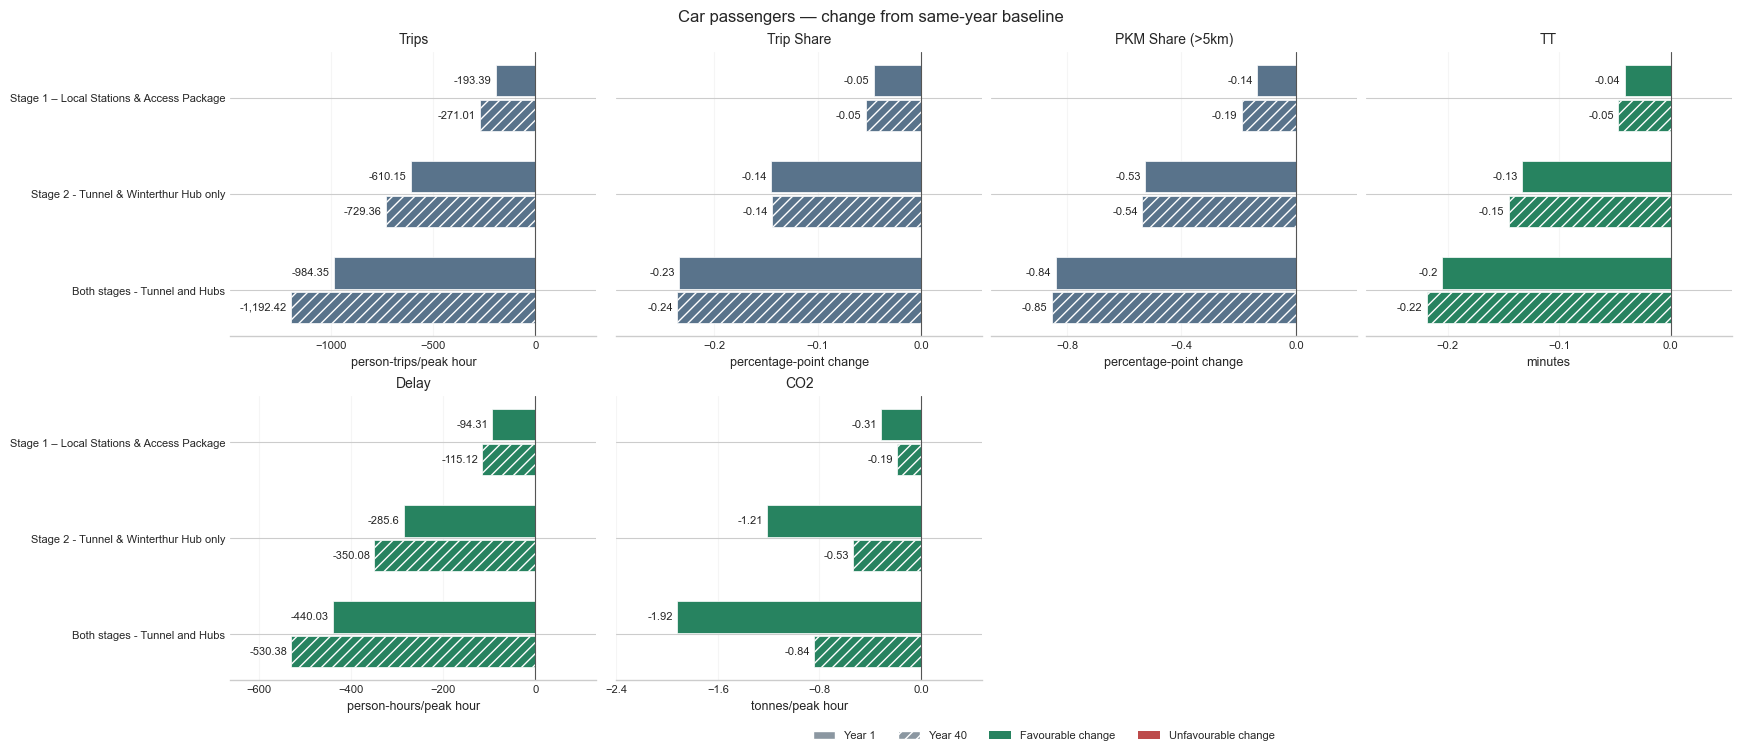

Public transport — absolute results


,Year 1 Trips,Year 40 Trips,Year 1 Trip Share,Year 40 Trip Share,Year 1 PKM Share (>5km),Year 40 PKM Share (>5km),Year 1 TT,Year 40 TT
Stage,,,,,,,,
Stage 0 – Baseline Network,"85,329 trips","109,003 trips",20.2%,21.5%,34.8%,38.0%,12.8 min,12.8 min
Stage 1 – Local Stations & Access Package,"85,616 trips","109,416 trips",20.3%,21.6%,35.0%,38.3%,12.7 min,12.8 min
Stage 2 - Tunnel & Winterthur Hub only,"86,196 trips","110,106 trips",20.4%,21.8%,35.4%,38.7%,12.6 min,12.6 min
Both stages - Tunnel and Hubs,"86,724 trips","110,783 trips",20.6%,21.9%,35.8%,39.0%,12.5 min,12.5 min


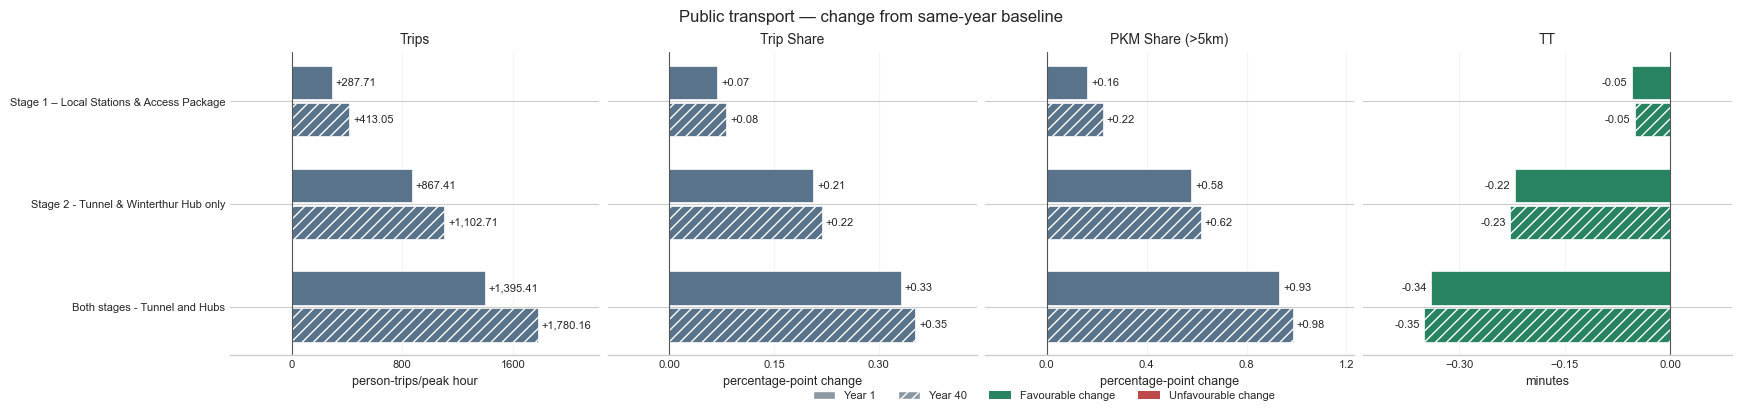

Active mobility — absolute results


,Year 1 Bike Trips,Year 40 Bike Trips,Bike Trip Share,Bike PKM Share,Year 1 Walk Trips,Year 40 Walk Trips,Walk Trip Share,Walk PKM Share
Stage,,,,,,,,
Stage 0 – Baseline Network,"61,106 trips","79,114 trips",14.5%,6.5%,"146,876 trips","174,371 trips",34.8%,2.1%
Stage 1 – Local Stations & Access Package,"61,042 trips","79,012 trips",14.5%,6.5%,"146,846 trips","174,331 trips",34.8%,2.1%
Stage 2 - Tunnel & Winterthur Hub only,"60,948 trips","78,868 trips",14.5%,6.4%,"146,777 trips","174,243 trips",34.8%,2.1%
Both stages - Tunnel and Hubs,"60,841 trips","78,713 trips",14.4%,6.4%,"146,730 trips","174,184 trips",34.8%,2.1%


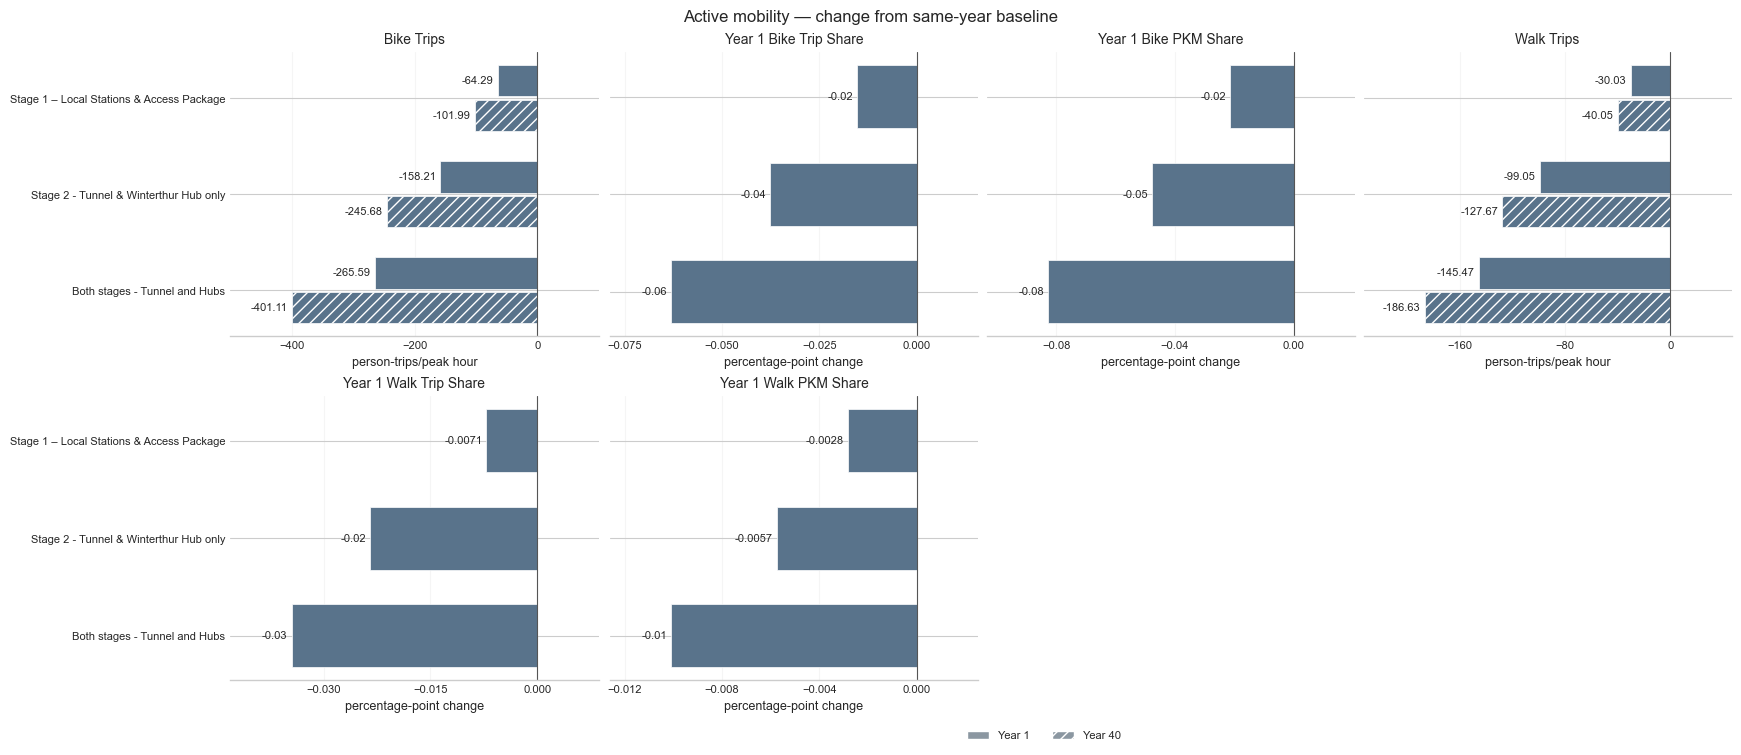

Overall system — absolute results


,Year 1 Total Demand,Year 40 Total Demand,Year 1 System Avg TT,Year 40 System Avg TT,Year 1 Peak Delay,Year 40 Peak Delay,Year 1 Peak CO2,Year 40 Peak CO2
Stage,,,,,,,,
Stage 0 – Baseline Network,"421,576 trips","505,891 trips",14.0 min,14.2 min,"11,178 h","13,847 h",139.9 t,55.2 t
Stage 1 – Local Stations & Access Package,"421,576 trips","505,891 trips",13.9 min,14.1 min,"11,084 h","13,732 h",139.6 t,55.0 t
Stage 2 - Tunnel & Winterthur Hub only,"421,576 trips","505,891 trips",13.8 min,14.0 min,"10,893 h","13,497 h",138.7 t,54.7 t
Both stages - Tunnel and Hubs,"421,576 trips","505,891 trips",13.7 min,13.9 min,"10,738 h","13,317 h",137.9 t,54.4 t


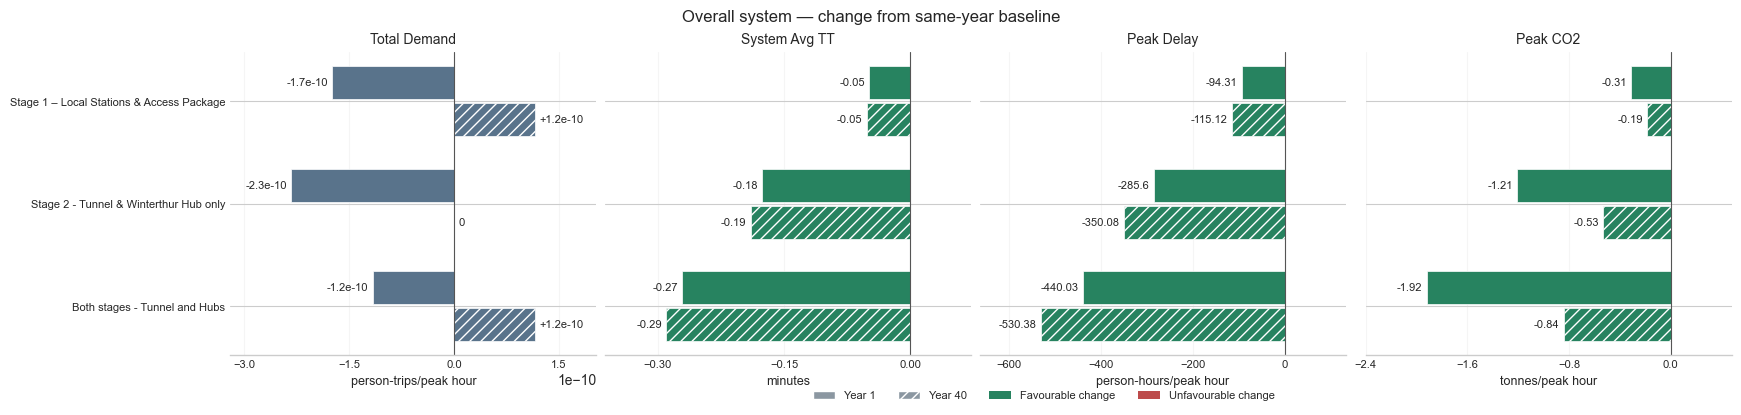

Section and PT components — absolute results


,Year 1 Section reference time,Year 1 Section modeled passengers,Year 1 Section supplementary passengers,Year 1 Section combined passengers,Year 1 Section comfort capacity,Year 1 Section load/capacity,Year 1 Section crowding multiplier,Year 1 Section crowding penalty,Year 1 PT waiting,Year 1 PT access,Year 1 PT egress,Year 1 PT transfer walking,Year 40 Section reference time,Year 40 Section modeled passengers,Year 40 Section supplementary passengers,Year 40 Section combined passengers,Year 40 Section comfort capacity,Year 40 Section load/capacity,Year 40 Section crowding multiplier,Year 40 Section crowding penalty,Year 40 PT waiting,Year 40 PT access,Year 40 PT egress,Year 40 PT transfer walking
Stage 0 – Baseline Network,23.62 minutes,"56,957.77 passengers/day","54,815.41 passengers/day","111,773.18 passengers/day","11,352.00 passengers/peak hour",0.93 ratio,1.00 multiplier,0.00 extra minutes at peak,4.39 minutes/baseline PT trip,5.11 minutes/baseline PT trip,4.85 minutes/baseline PT trip,1.09 minutes/baseline PT trip,23.62 minutes,"75,106.40 passengers/day","65,778.49 passengers/day","140,884.89 passengers/day","11,352.00 passengers/peak hour",1.17 ratio,1.35 multiplier,8.22 extra minutes at peak,4.43 minutes/baseline PT trip,5.04 minutes/baseline PT trip,4.78 minutes/baseline PT trip,1.09 minutes/baseline PT trip
Stage 1 – Local Stations & Access Package,22.62 minutes,"58,007.64 passengers/day","54,815.41 passengers/day","112,823.04 passengers/day","12,487.20 passengers/peak hour",0.85 ratio,1.00 multiplier,0.00 extra minutes at peak,4.35 minutes/baseline PT trip,5.10 minutes/baseline PT trip,4.84 minutes/baseline PT trip,1.08 minutes/baseline PT trip,22.62 minutes,"76,595.57 passengers/day","65,778.49 passengers/day","142,374.06 passengers/day","12,487.20 passengers/peak hour",1.08 ratio,1.16 multiplier,3.56 extra minutes at peak,4.39 minutes/baseline PT trip,5.03 minutes/baseline PT trip,4.77 minutes/baseline PT trip,1.09 minutes/baseline PT trip
Stage 2 - Tunnel & Winterthur Hub only,19.62 minutes,"61,423.98 passengers/day","54,815.41 passengers/day","116,239.39 passengers/day","13,054.80 passengers/peak hour",0.84 ratio,1.00 multiplier,0.00 extra minutes at peak,4.27 minutes/baseline PT trip,5.08 minutes/baseline PT trip,4.83 minutes/baseline PT trip,1.08 minutes/baseline PT trip,19.62 minutes,"80,732.66 passengers/day","65,778.49 passengers/day","146,511.15 passengers/day","13,054.80 passengers/peak hour",1.06 ratio,1.12 multiplier,2.42 extra minutes at peak,4.31 minutes/baseline PT trip,5.02 minutes/baseline PT trip,4.76 minutes/baseline PT trip,1.08 minutes/baseline PT trip
Both stages - Tunnel and Hubs,17.62 minutes,"63,750.50 passengers/day","54,815.41 passengers/day","118,565.91 passengers/day","14,757.60 passengers/peak hour",0.76 ratio,1.00 multiplier,0.00 extra minutes at peak,4.19 minutes/baseline PT trip,5.07 minutes/baseline PT trip,4.82 minutes/baseline PT trip,1.08 minutes/baseline PT trip,17.62 minutes,"83,515.01 passengers/day","65,778.49 passengers/day","149,293.50 passengers/day","14,757.60 passengers/peak hour",0.96 ratio,1.00 multiplier,0.00 extra minutes at peak,4.23 minutes/baseline PT trip,5.01 minutes/baseline PT trip,4.75 minutes/baseline PT trip,1.08 minutes/baseline PT trip


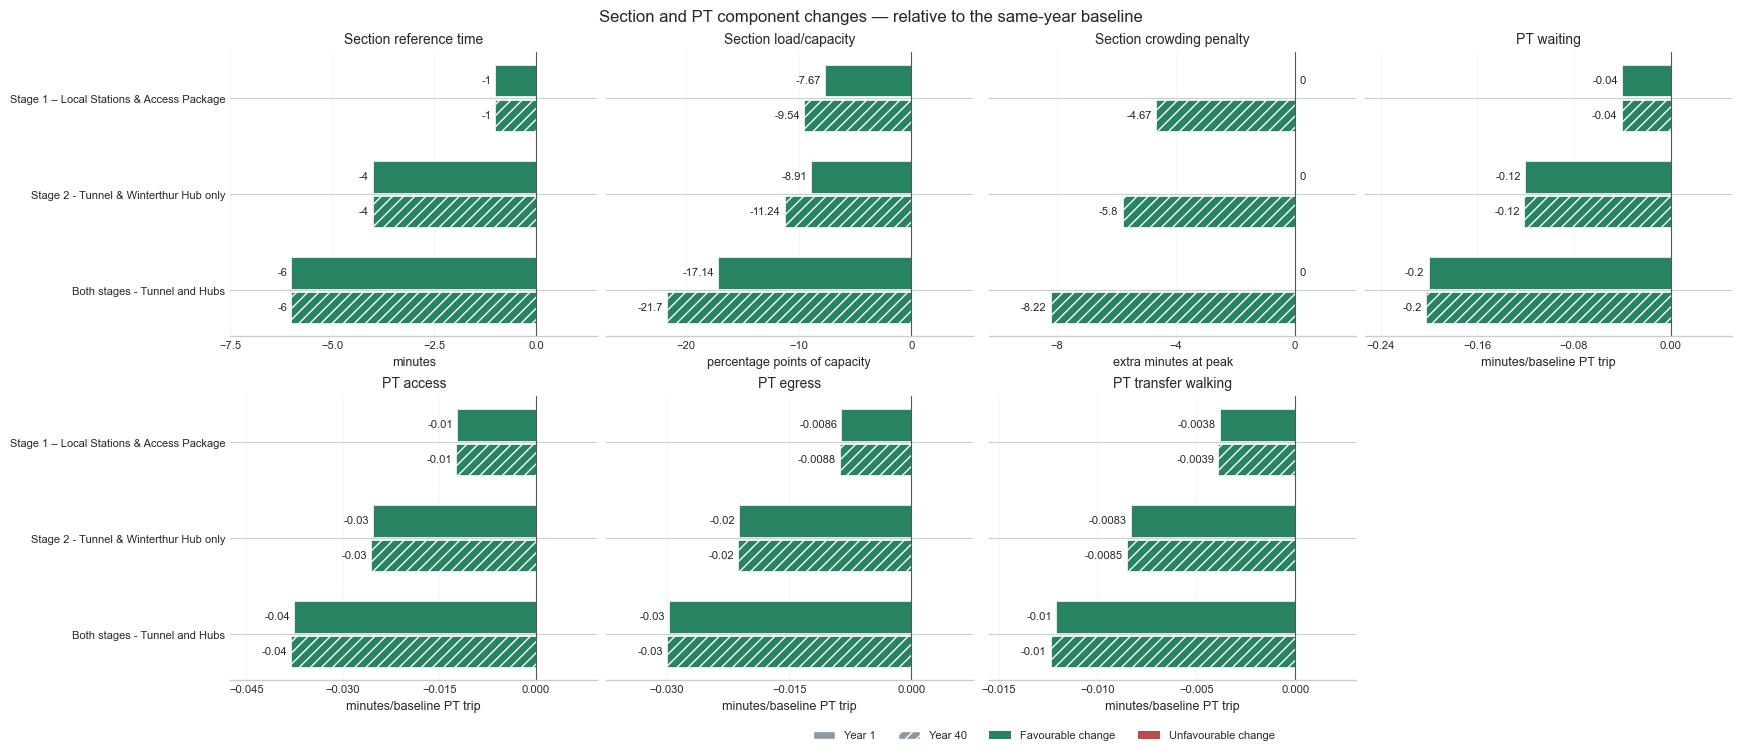

In [ ]:
from additional import transport_display as td

# Formats for the absolute result tables.
_CAR_FORMAT = {
    "Year 1 Trips": "{:,.0f} trips", "Year 40 Trips": "{:,.0f} trips",
    "Year 1 Trip Share": "{:.2%}", "Year 40 Trip Share": "{:.2%}",
    "Year 1 PKM Share (>5km)": "{:.2%}", "Year 40 PKM Share (>5km)": "{:.2%}",
    "Year 1 TT": "{:.2f} min", "Year 40 TT": "{:.2f} min",
    "Year 1 Delay": "{:,.0f} h", "Year 40 Delay": "{:,.0f} h",
    "Year 1 CO2": "{:,.1f} t", "Year 40 CO2": "{:,.1f} t",
}
_PT_FORMAT = {
    "Year 1 Trips": "{:,.0f} trips", "Year 40 Trips": "{:,.0f} trips",
    "Year 1 Trip Share": "{:.2%}", "Year 40 Trip Share": "{:.2%}",
    "Year 1 PKM Share (>5km)": "{:.2%}", "Year 40 PKM Share (>5km)": "{:.2%}",
    "Year 1 TT": "{:.2f} min", "Year 40 TT": "{:.2f} min",
}
_ACTIVE_FORMAT = {
    "Year 1 Bike Trips": "{:,.0f} trips", "Year 40 Bike Trips": "{:,.0f} trips",
    "Year 1 Bike Trip Share": "{:.2%}", "Year 1 Bike PKM Share": "{:.2%}",
    "Year 1 Walk Trips": "{:,.0f} trips", "Year 40 Walk Trips": "{:,.0f} trips",
    "Year 1 Walk Trip Share": "{:.2%}", "Year 1 Walk PKM Share": "{:.2%}",
}
_SYSTEM_FORMAT = {
    "Year 1 Total Demand": "{:,.0f} trips", "Year 40 Total Demand": "{:,.0f} trips",
    "Year 1 System Avg TT": "{:.2f} min", "Year 40 System Avg TT": "{:.2f} min",
    "Year 1 Peak Delay": "{:,.0f} h", "Year 40 Peak Delay": "{:,.0f} h",
    "Year 1 Peak CO2": "{:,.1f} t", "Year 40 Peak CO2": "{:,.1f} t",
}


BASELINE_STAGE_NAME = ACTIVE_STAGE_SPECS[0]["name"]
active_display = df_active.rename(columns={
    c: f"Year 1 {c}" for c in ("Bike Trip Share", "Bike PKM Share", "Walk Trip Share", "Walk PKM Share")
})

def _stage_change_charts(frame, title, export_name):
    if not len(frame.columns):
        return
    panels, units, scales, directions = {}, {}, {}, {}
    for column in frame:
        metric = column.removeprefix("Year 1 ").removeprefix("Year 40 ")
        panels.setdefault(metric, []).append(column)
        if "Share" in metric:
            scales[column] = 100.0
            units[metric] = "percentage-point change"
        else:
            units[metric] = (
                "person-trips/peak hour" if "Trips" in metric or "Demand" in metric else
                "person-hours/peak hour" if "Delay" in metric else
                "tonnes/peak hour" if "CO2" in metric else "minutes"
            )
        directions[metric] = "low" if any(word in metric for word in ("TT", "Delay", "CO2")) else "context"
    metric_labels = {
        "Trips": "Passenger trips", "Trip Share": "Share of passenger trips",
        "PKM Share (>5km)": "Distance-weighted share (≥5 km)", "TT": "In-vehicle travel time",
        "Delay": "Passenger road delay", "CO2": "Passenger-car operating CO2",
        "System Avg TT": "Car/PT in-vehicle travel time", "Peak Delay": "Passenger road delay",
        "Peak CO2": "Passenger-car operating CO2", "Total Demand": "Total passenger demand",
        "Bike PKM Share": "Bicycle distance-weighted share (≥5 km)",
        "Walk PKM Share": "Walking distance-weighted share (≥5 km)",
    }
    labels = {key: (f"Year 1 {metric_labels.get(key, key)}" if all(c.startswith("Year 1 ") for c in cols) else metric_labels.get(key, key))
              for key, cols in panels.items()}
    fig = td.plot_baseline_changes(frame, BASELINE_STAGE_NAME, title=title + " — change from same-year baseline",
                             panels=panels, labels=labels, units=units, scales=scales, directions=directions,
                             ncols=CHANGE_PLOT_COLUMNS, fontsize=CHANGE_PLOT_FONT_SIZE)
    exports.save_outputs(export_name, figure=fig)
    plt.show()

for frame, title, fmt, export_name in [
    (df_car, "Car passengers", _CAR_FORMAT, "3_3_stage_car_changes"),
    (df_pt, "Public transport", _PT_FORMAT, "3_3_stage_pt_changes"),
    (active_display, "Active mobility", _ACTIVE_FORMAT, "3_3_stage_active_changes"),
    (df_system, "Overall system", _SYSTEM_FORMAT, "3_3_stage_system_changes"),
]:
    print(title + " — absolute results")
    selected = _display_indicators(frame, fmt)
    plot_columns = _plot_columns(frame, STAGE_PLOT_INDICATORS[title])
    _stage_change_charts(frame[plot_columns], title, export_name)

print("Section and PT components — absolute results")
project_formats = {
    f"{year} {key}": "{:,.2f} " + units
    for year in ("Year 1", "Year 40") for key, units in PROJECT_INDICATOR_UNITS.items()
}
selected_project = _display_indicators(STAGE_PROJECT_INDICATORS, project_formats, na_rep="n/a")
focus_columns = _plot_columns(STAGE_PROJECT_INDICATORS, PROJECT_PLOT_INDICATORS)
if focus_columns:
    fig = td.plot_baseline_changes(selected_project[focus_columns], BASELINE_STAGE_NAME,
        title="Section and PT component changes — relative to the same-year baseline",
        units={**PROJECT_INDICATOR_UNITS, "Section load/capacity": "percentage points of capacity"},
        scales={c: 100.0 for c in focus_columns if c.endswith("Section load/capacity")},
        directions=PROJECT_INDICATOR_DIRECTIONS,
        ncols=CHANGE_PLOT_COLUMNS, fontsize=CHANGE_PLOT_FONT_SIZE)
    exports.save_outputs("3_3_stage_project_changes", figure=fig)
    plt.show()


### 3.4 Preparing for uncertainty analysis (mandatory task)

Notebook 03 defines the uncertainty ranges and uses them to train the shared transport surrogate and prepare its response table. Save the intended interventions in the named packages in `code/stages.py` before continuing there; temporary changes in the interactive editor apply only within this notebook.



### 3.5 Optional section count and external-flow calibration (tutorial/supporting task)

Configure `SECTION` in `parameters.py` to estimate flow through a PT approach, along a cycling route or at a PT stop. Fixed inferred routes connect the modeled OD quantities to the selected location; this is not a separate PT or cycling assignment.

| Definition | Student inputs | Count |
|---|---|---|
| `pt_approach` | Station and a station indicating the approach direction | Journeys using service connections on that side of the station, including express services |
| `bike_route` | Two endpoint locations | Midpoint-link flow and unique users of any selected route link |
| `pt_stop` | Station name | Access, egress and represented walking transfers, reported separately |

The supplied MehrSpur coverage is loaded directly. Missing coverage or changed definitions/inputs are regenerated automatically from the shared routing inputs; preparation can take a few minutes. For another project, select a new `coverage_file` in `SECTION`, or use `None` for an automatic cache. PT connections do not contain physical railway alignments; a station approach can include other branches on the same side. Same-platform train changes are not fully identified. Cycling counts use fixed shortest paths and exclude cycling access to PT.

**Calibrate once against nominal Stage 0:**

1. Check that the observation matches the mode, location, directions, time period and count definition. A cycle counter measures flow at one link, not everyone using part of a route. Station entries, exits and transfers are different counts.
2. Run the next cell. It reuses the **Year-1 coupled Stage 0** result from Section 1.7 and reports the achieved assignment convergence. Set `OBSERVED_SECTION_TRIPS_DAILY = None` for a count without an observed target.
3. If justified, copy the reported nonnegative residual into `EXTERNAL_FLOW['additional_trips_daily']`. The report does not edit configuration. Retain that cohort across alternatives; only its configured growth applies.

**MehrSpur:** count the Winterthur approach facing Effretikon, in both directions. **120,000 passengers/day** is the assumed target; it is not evidence that an observed count uses precisely this definition. The residual can include missing external journeys, model error and measurement differences.

`EXTERNAL_FLOW` adds existing passengers after mode choice for appraisal; it does not load roads or generate municipal OD demand. A counting definition can be used without this supplementary cohort. Stop-specific hub benefits use `station` in the hub intervention: access and egress affect their respective users, while transfer-walking reductions apply only to represented physical walking at that stop.

**Other projects:** disable or omit both `SECTION` and `EXTERNAL_FLOW` if unused, and replace any section-dependent stage effects or adaptive triggers. To retain counts without supplementary passengers, set `EXTERNAL_FLOW['enabled'] = False`. See `python code/additional/section_flows.py --help` for preparation and calibration options.


In [ ]:
from additional import section_flows as sf

section_config = sf.section_config()
if section_config["active"]:
    AVAILABLE_SECTIONS = sf.available_sections()
    exports.save_outputs("3_5_available_sections", tables={"": AVAILABLE_SECTIONS})
    display(AVAILABLE_SECTIONS)
    OBSERVED_SECTION_TRIPS_DAILY = 120_000  # Comparable observed person-trips/day; None skips calibration.
    SECTION_CALIBRATION = sf.calibrate_section(
        ctx, assignment_y1.mode_result,
        observed_trips_daily=OBSERVED_SECTION_TRIPS_DAILY, params=p.NOMINAL_PARAMS,
    )
    diag = assignment_y1.diagnostics
    reference_ready = (
        diag.get("stopping_rule") == "road_relative_gap"
        and bool(diag.get("stopping_rule_met", False))
        and diag.get("road_gap_threshold", np.inf) <= 0.02
        and diag.get("od_threshold_veh_h", np.inf) == 0.0
    )
    external_config = sf.external_flow_config()
    configured = external_config["additional_trips_daily"] if external_config["enabled"] else 0.0
    SECTION_CALIBRATION_TABLE = pd.DataFrame({"Calibration": {
        "Modeled passengers/day": SECTION_CALIBRATION["modeled_trips_daily"],
        "Observed passengers/day": OBSERVED_SECTION_TRIPS_DAILY,
        "Suggested supplementary passengers/day": SECTION_CALIBRATION["additional_trips_daily"],
        "Configured supplementary passengers/day": configured,
        "Modeled + configured supplementary/day": SECTION_CALIBRATION["modeled_trips_daily"] + configured,
        "Suggested comfort capacity/peak hour": SECTION_CALIBRATION["suggested_comfort_capacity_peak"],
        "Road relative gap": diag.get("final_road_relative_gap_feasible_averaged_od"),
        "Iterations": diag.get("iterations"),
        "OD cutoff (vehicles/hour)": diag.get("od_threshold_veh_h"),
        "Termination": diag.get("termination_reason"),
        "Reference settings and convergence satisfied": reference_ready,
    }})
    exports.save_outputs("3_5_section_calibration", tables={"": SECTION_CALIBRATION_TABLE})
    display(SECTION_CALIBRATION_TABLE)
    if SECTION_CALIBRATION.get("component_counts_daily"):
        SECTION_COMPONENT_COUNTS = pd.Series(SECTION_CALIBRATION["component_counts_daily"], name="Journeys/day").to_frame()
        exports.save_outputs("3_5_section_calibration", tables={"component_counts": SECTION_COMPONENT_COUNTS})
        display(SECTION_COMPONENT_COUNTS)
    if not reference_ready:
        print("Illustrative count only: use zero OD cutoff and reach the 2% road-gap target before adopting a residual.")
    if SECTION_CALIBRATION["warning"]:
        print(SECTION_CALIBRATION["warning"])
else:
    print("Section counting and external flows are inactive for this project.")


# Part 4 — Deployment Plans

A **plan** specifies the initial infrastructure stage and any fixed or trigger-based rules for moving to later stages. A **pathway** is the resulting evolution of the system through time when that plan is evaluated under a scenario.

As a refresher, we reproduce the following distinctions in the terminology we use:

| Concept | Question | Example |
|---|---|---|
| Parameter | What numerical assumption controls a relationship? | Tunnel section travel-time saving = 4 minutes; both packages = 6 minutes |
| Stage | What transport intervention / package is in place? | Stations + tunnel: Brüttenertunnel, station upgrades and 15-minute service |
| Plan | When, and under which rules, are stages deployed? | Stage 1 in Year 1, Stage 2 in Year 25 |

Plan definitions live in [`code/adaptive_planning.py`](../code/adaptive_planning.py), stage definitions in [`code/stages.py`](../code/stages.py), and uncertain assumptions in [`code/parameters.py`](../code/parameters.py).

This notebook introduces three deterministic plans with no later transitions: a do-nothing baseline and two static plans, one partial and one full build.

| Plan | Stage from Year 1 | Later transition? |
|---|---|---|
| `baseline` | Stage 0 — do nothing | No |
| `static1` | Stage 1 — partial intervention | No |
| `static2` | Stages 1 + 2 — stations and tunnel (complete intervention) | No |

### 4.1 Static plan definition (mandatory task)

During the course, we use four plan types:

| Plan type | Deployment rule |
|---|---|
| **Baseline** | Keep Stage 0 for the complete horizon. |
| **Static** | Deploy one selected stage in Year 1 and retain it. |
| **Staged** | Deploy later stages in years predetermined at the outset, regardless of observed conditions. |
| **Adaptive** | Deploy later stages based on specific rules, i.e. only after predefined signposts cross their trigger thresholds, persistence requirements, and lead times. |

*Mandatory task*
>Define the three deterministic alternatives used here: **Baseline**, which retains Stage 0 throughout the simulation; **Static 1**, which deploys the partial Stage 1 intervention in Year 1 until the end of the simulation; and **Static 2**, which deploys both packages (Stages 1 + 2, the complete intervention) in Year 1 until the end of the simulation.

Notebook 02 compares `baseline`, `static1`, and `static2`. Predetermined (staged) and flexible/adaptive plans are examined in the following notebooks.
<br>
<br>
**Packages describe what is built; plans describe when.** `static1` opens the station package in Year 1. `static2` opens both station and tunnel packages in Year 1. 

---

Open [`code/adaptive_planning.py`](../code/adaptive_planning.py) and edit the student-facing `PLAN_DEFINITIONS` dictionary near the top:

1. Adapt `baseline`, `static1`, and `static2` as necessary for your project. Set `name` and `initial_packages`: `[]` for baseline, `['stations']` for Static 1, and `['stations', 'tunnel']` for Static 2. Keep `stations: None` and `tunnel: None` for these static plans, since no package is added later.
2. Leave `staged1`, `staged2`, and `flexible` unchanged for now. Their `stations` and `tunnel` entries schedule later openings, for example `{'type': 'fixed', 'opening_year': 9}` or `{'type': 'trigger', 'trigger': 'trigger1'}`. Trigger rules are configured in `DEFAULT_TRIGGERS`.
3. Set package construction costs, lifetimes and construction emissions in `PACKAGES` in `stages.py`. A general OPEX cost- `OPEX_RATE` and the cost of flexibility - `C_FLEX` are in `parameters.py`. The model derives costs and transport-state IDs from the named packages. An additional independently scheduled package requires extending the plan engine and transport states.
4. After saving plan or package changes, restart the kernel and Run All. `PLAN_SUBSET` below selects the static plans to display.

## 4.2 Visualizing plans and their system pathways (tutorial/supporting task)

The metro-style map compares the plans by showing the infrastructure-stage pathway that each plan produces over the 40-year horizon:

- read from left to right as time advances.
- horizontal lines show the active physical stage.
- a solid dot marks the initial Year-1 commitment.
- later dots or branches, introduced in Notebook 04, represent stage transitions.

The three plans shown here have no later transition: `baseline` remains at Stage 0, `static1` remains at Stage 1, and `static2` remains at Stages 1 + 2 (both packages).

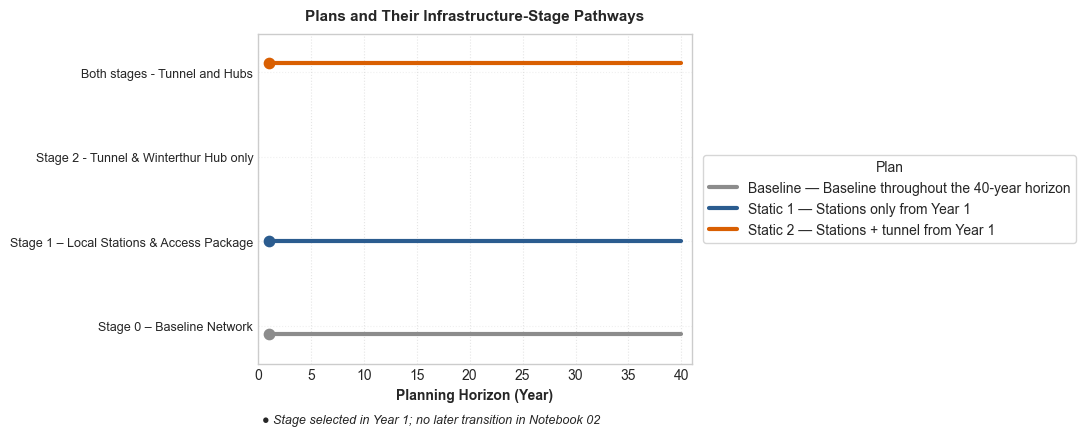

In [ ]:
PLAN_SUBSET = ["baseline", "static1", "static2"]
PLANS = {name: adaptive_planning.PLANS[name] for name in PLAN_SUBSET}
PLAN_COLORS = ["#8c8c8c", "#2b5c8f", "#d95f02", "#2ca02c", "#7570b3"]


def draw_plan_metromap(
    plans,
    horizon=p.N_YEARS,
):
    fig, ax = plt.subplots(figsize=(11, 4.5))

    plan_offsets = np.linspace(-0.10, 0.10, max(len(plans), 2))

    for plan_idx, ((plan_name, plan), plan_offset) in enumerate(
        zip(plans.items(), plan_offsets)
    ):
        color = PLAN_COLORS[plan_idx % len(PLAN_COLORS)]
        display_name = plan.get("name", plan_name)

        if plan["to1"] is not None or plan["to2"] is not None:
            raise ValueError(f"{plan_name!r} is not a static plan")

        stage = plan["initial_stage"]
        ax.plot(
            [1, horizon],
            [stage + plan_offset, stage + plan_offset],
            color=color,
            linewidth=3,
            label=display_name,
        )
        ax.scatter(1, stage + plan_offset, color=color, s=55, zorder=5)

    stage_ticks = sorted(ACTIVE_STAGE_SPECS)
    ax.set_yticks(stage_ticks)
    ax.set_yticklabels([ACTIVE_STAGE_SPECS[s].get("name", f"Stage {s}") for s in stage_ticks], fontsize=9)

    ax.set_xlim(0, horizon + 1)
    ax.set_ylim(min(stage_ticks) - 0.45, max(stage_ticks) + 0.45)
    ax.set_xlabel("Planning Horizon (Year)", fontweight="bold")
    ax.set_title("Plans and Their Infrastructure-Stage Pathways", fontweight="bold", fontsize=11, pad=10)

    ax.grid(axis="x", linestyle=":", alpha=0.5)
    ax.grid(axis="y", linestyle=":", alpha=0.3)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        title="Plan",
        frameon=True,)
    ax.text(
        0.01,
        -0.18,
        "● Stage selected in Year 1; no later transition in Notebook 02",
        transform=ax.transAxes,
        fontsize=9,
        style="italic",)

    plt.tight_layout()

    exports.save_outputs("4_2_plan_metromap", figure=fig)

    return fig, ax

draw_plan_metromap(PLANS)
plt.show()


## 4.3 Compare plan end states (mandatory task)

Compare the Year-40 system state for the do-nothing `baseline`, the stations-only `static1`, and the combined `static2` plans. Each plan reuses the matching transport state from Section 3.3, using the nominal Year-40 values from General parameters, including `PASSENGER_DEMAND_GROWTH_Y40`, `PT_ASC_SHIFT_Y40`, `EBIKE_SHARE_Y40` and `ROAD_FREIGHT_GROWTH_Y40`. No uncertainty draws or annual transport runs are needed.

The cost column is undiscounted investment plus 40 years of operating costs for these static plans. Annual CO2 is from car and rail operation; total package construction emissions are shown separately. Uncertainty trajectories and discounted appraisal follow in later notebooks.

Modal shares use common-distance weighting for journeys of at least 5 km. The charts show each plan minus the Year-40 baseline in physical units; modal-share changes are percentage points. The section and PT component indicators use the definitions in Section 3.3. Absolute tables remain available, and `SHOW_ABSOLUTE_PARALLEL_COORDINATES` enables the optional absolute overview. The indicator-family selection in Section 1.7 also applies here; `PLAN_PLOT_INDICATORS` and `PROJECT_PLOT_INDICATORS` select individual subplots. Transport and operating indicators describe Year 40; construction emissions and infrastructure cost are totals over the stated period. Each subplot has its own axis range. Modal-share shifts are contextual, not welfare scores. Rerun only the display cell to redraw completed results.


In [ ]:
# Year-40 plan results from the completed stage snapshots.

NOMINAL_PATHS = uc.nominal_paths()
YEAR40_PARAMS = uc.year_parameters(NOMINAL_PATHS, p.N_YEARS - 1)
PLAN_RESULTS = {}
PLAN_INFRASTRUCTURE_COSTS = {}
PLAN_CONSTRUCTION_EMISSIONS = {}
PLAN_PROJECT_ROWS = {}

for key, plan in PLANS.items():
    if plan["to1"] is not None or plan["to2"] is not None:
        raise ValueError(f"{key!r} is not a static plan")
    stage = int(plan["initial_stage"])
    stations_active, tunnel_active = stages_module.stage_components(stage)
    investment = (
        stations_active * plan.get("inv_stage1", 0.0)
        + tunnel_active * plan.get("inv_stage2", 0.0)
    )
    annual_opex = (
        stations_active * plan.get("op_stage1", 0.0)
        + tunnel_active * plan.get("op_stage2", 0.0)
    )
    print(f"Using Year {p.N_YEARS} state: {plan['name']}...")
    snapshot = tmi.stage_year_snapshot(ctx, stage_results[stage],
        stage_spec=ACTIVE_STAGE_SPECS[stage],
        corridor_context=globals().get("ROAD_STAGE_CORRIDORS", {}).get(stage, MEHRSPUR),
        year_idx=p.N_YEARS - 1,
        g_cum=float(NOMINAL_PATHS["PASSENGER_DEMAND_GROWTH"][-1]), params=YEAR40_PARAMS,
        assignment_settings=ASSIGNMENT_OPTIONS, snapshots=YEAR_SNAPSHOTS)
    PLAN_PROJECT_ROWS[plan["name"]] = _project_indicator_row(snapshot)
    PLAN_RESULTS[key] = m.simulate_year(
        stage_metrics[stage], stage=stage, year_idx=p.N_YEARS - 1,
        g_cum=float(NOMINAL_PATHS["PASSENGER_DEMAND_GROWTH"][-1]), params=YEAR40_PARAMS,
        context=ctx, mode_result=stage_results[stage],
        corridor_municipalities=corridor_municipalities,
        corridor_context=globals().get("ROAD_STAGE_CORRIDORS", {}).get(stage, MEHRSPUR),
        inv_cost=0.0, op_cost=annual_opex,
        transport_state=snapshot["transport_state"],
    )
    PLAN_INFRASTRUCTURE_COSTS[key] = investment + p.N_YEARS * annual_opex
    PLAN_CONSTRUCTION_EMISSIONS[key] = sum(
        stages_module.construction_emissions_tonnes(package)
        for package, active in ((1, stations_active), (2, tunnel_active)) if active
    )

# 1. One row per plan, with every indicator we track ----------------------
DIRECTION = {                       # preferred direction for each axis
    "Stage (Y40)":          "-",    # contextual information, not a quality metric
    "Car %":                "-",
    "PT %":                 "-",
    "Bicycle %":            "-",
    "Walk %":               "-",
    "Car/PT in-vehicle time (min)":    "low",
    "Congestion (k person-h/yr)": "low",
    "Operating CO2 (t/yr)":           "low",
    "Annual trip equivalents (thousands)": "-",   # mode-specific conversion of fixed peak OD demand
    "Construction CO2 (t total)": "low",
    "40-yr cost (bn CHF)":  "low",
}

rows = {}
for key, y in PLAN_RESULTS.items():
    rows[PLANS[key]["name"]] = {
        "Stage (Y40)":          y["stage"],
        "Car %":                y["car_share"]  * 100,
        "PT %":                 y["pt_share"]   * 100,
        "Bicycle %":            y["bike_share"] * 100,
        "Walk %":               y["walk_share"] * 100,
        "Car/PT in-vehicle time (min)":    y["avg_tt_min"],
        "Congestion (k person-h/yr)": y["congestion_delay_hours"] / 1e3,
        "Operating CO2 (t/yr)":           y["co2_tonnes"],
        "Annual trip equivalents (thousands)": y["total_demand"] / 1e3,
        "Construction CO2 (t total)": PLAN_CONSTRUCTION_EMISSIONS[key],
        "40-yr cost (bn CHF)":  PLAN_INFRASTRUCTURE_COSTS[key] / 1e9,
    }
PLAN_OUTCOMES = pd.DataFrame(rows).T[list(DIRECTION)]
exports.save_outputs("4_3_plan_outcomes", tables={"": PLAN_OUTCOMES})

# Modal shares are already percentages; their differences are percentage points.
PLAN_OUTCOME_CHANGES = _baseline_change_table(PLAN_OUTCOMES, PLANS["baseline"]["name"])
PLAN_OUTCOME_CHANGES = PLAN_OUTCOME_CHANGES.rename(columns={
    f"{mode} % change (original units)": f"{mode} share change (percentage points)"
    for mode in ("Car", "PT", "Bicycle", "Walk")
})
exports.save_outputs("4_3_plan_outcomes_changes", tables={"": PLAN_OUTCOME_CHANGES})

PLAN_PROJECT_INDICATORS = pd.DataFrame.from_dict(PLAN_PROJECT_ROWS, orient="index")

exports.save_outputs("4_3_plan_project_indicators", tables={"": PLAN_PROJECT_INDICATORS})

exports.save_outputs("4_3_plan_project_changes", tables={"": _baseline_change_table(
    PLAN_PROJECT_INDICATORS, PLANS["baseline"]["name"],
    percentage_point_columns=["Section load/capacity"],
)})


Using Year 40 state: Baseline — Baseline throughout the 40-year horizon...
Using Year 40 state: Static 1 — Stations only from Year 1...
Using Year 40 state: Static 2 — Stations + tunnel from Year 1...


Year-40 plans — absolute results


,Stage (Y40),Car %,PT %,Bicycle %,Walk %,Car/PT in-vehicle time (min),Congestion (k person-h/yr),Operating CO2 (t/yr),Annual trip equivalents (thousands),Construction CO2 (t total),40-yr cost (bn CHF)
Baseline — Baseline throughout the 40-year horizon,0,51.6,38.0,8.3,2.0,14.16,"16,617.0","160,499","1,262,760.2",0,0.00
Static 1 — Stations only from Year 1,1,51.4,38.3,8.3,2.0,14.10,"16,478.8","160,099","1,263,011.0",0,1.67
Static 2 — Stations + tunnel from Year 1,3,50.7,39.0,8.2,2.0,13.87,"15,980.5","158,938","1,263,819.9","300,000",5.81


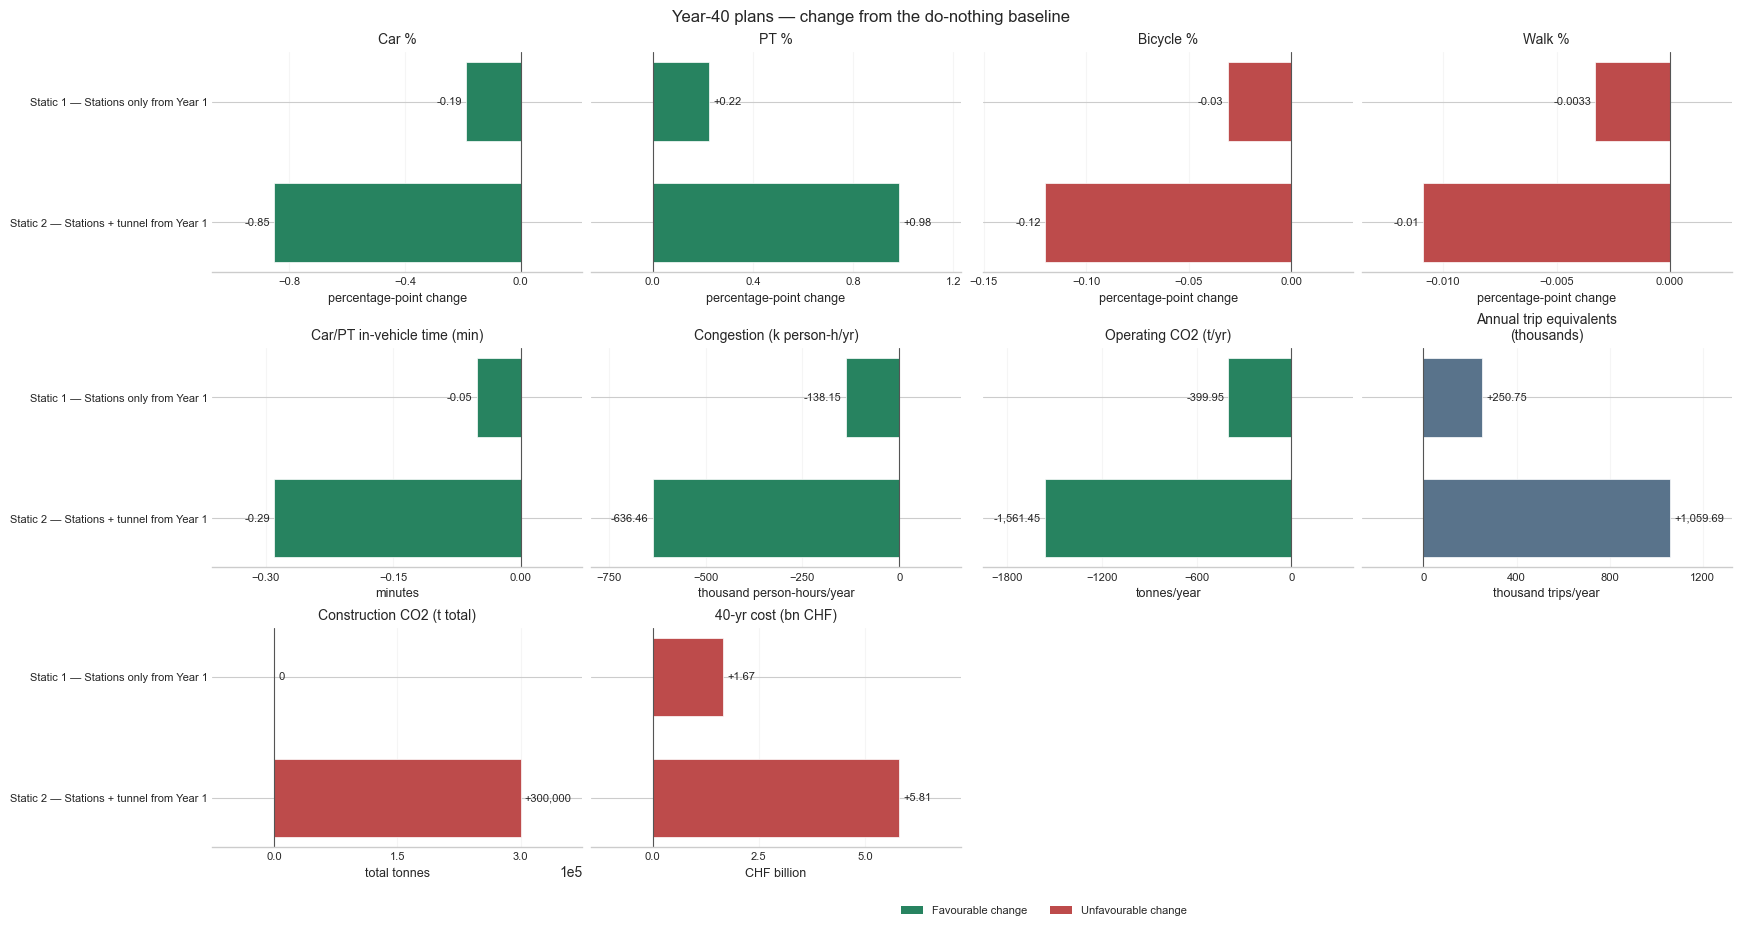

Year-40 section and PT components — absolute results


,Section reference time,Section modeled passengers,Section supplementary passengers,Section combined passengers,Section comfort capacity,Section load/capacity,Section crowding multiplier,Section crowding penalty,PT waiting,PT access,PT egress,PT transfer walking
Baseline — Baseline throughout the 40-year horizon,23.62 minutes,"75,106.40 passengers/day","65,778.49 passengers/day","140,884.89 passengers/day","11,352.00 passengers/peak hour",1.17 ratio,1.35 multiplier,8.22 extra minutes at peak,4.43 minutes/baseline PT trip,5.04 minutes/baseline PT trip,4.78 minutes/baseline PT trip,1.09 minutes/baseline PT trip
Static 1 — Stations only from Year 1,22.62 minutes,"76,595.57 passengers/day","65,778.49 passengers/day","142,374.06 passengers/day","12,487.20 passengers/peak hour",1.08 ratio,1.16 multiplier,3.56 extra minutes at peak,4.39 minutes/baseline PT trip,5.03 minutes/baseline PT trip,4.77 minutes/baseline PT trip,1.09 minutes/baseline PT trip
Static 2 — Stations + tunnel from Year 1,17.62 minutes,"83,515.01 passengers/day","65,778.49 passengers/day","149,293.50 passengers/day","14,757.60 passengers/peak hour",0.96 ratio,1.00 multiplier,0.00 extra minutes at peak,4.23 minutes/baseline PT trip,5.01 minutes/baseline PT trip,4.75 minutes/baseline PT trip,1.08 minutes/baseline PT trip


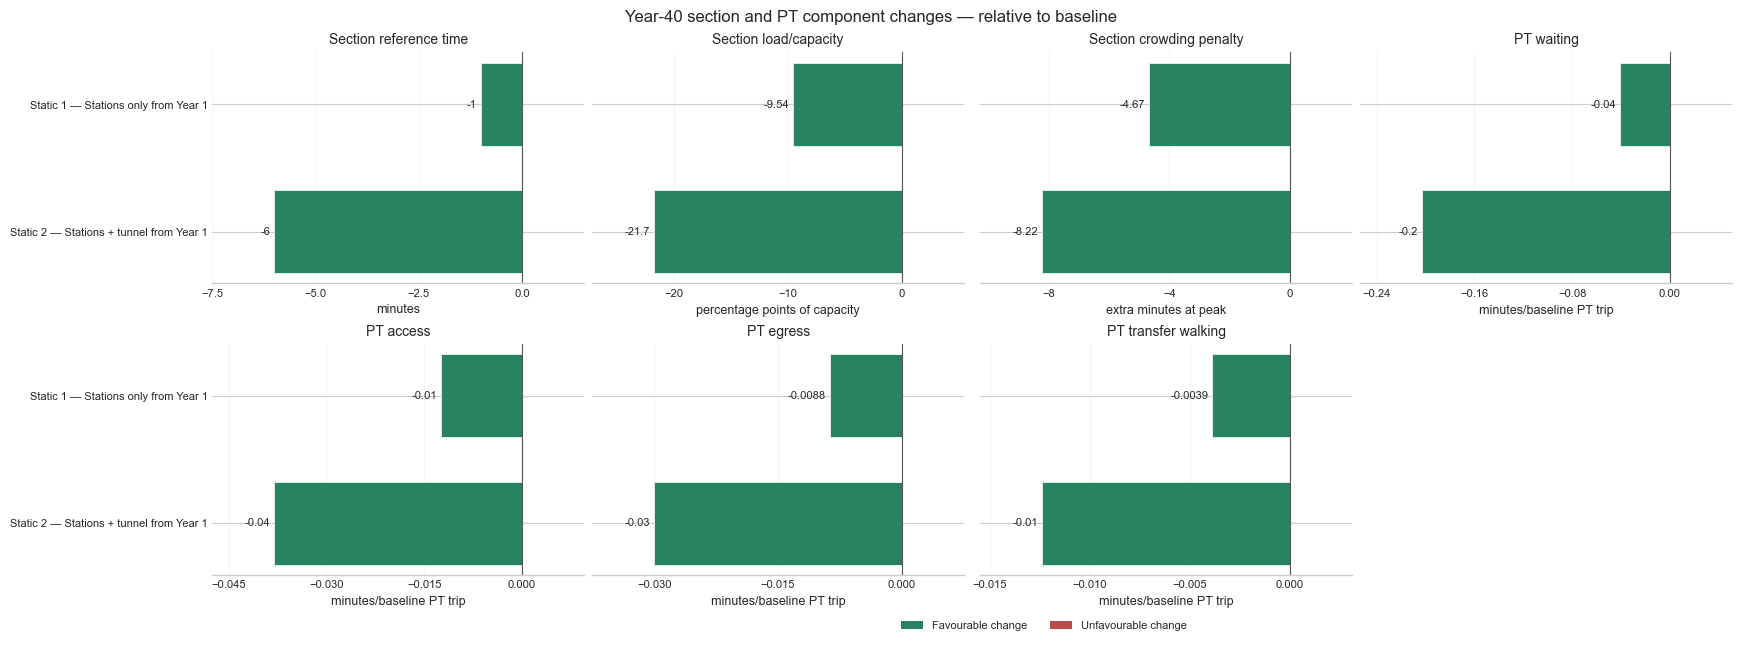

In [ ]:
from additional import transport_display as td

SHOW_ABSOLUTE_PARALLEL_COORDINATES = False  # Optional overview of the absolute values.
BASELINE_PLAN_NAME = PLANS["baseline"]["name"]
PLOT_DIRECTIONS = {key: "context" if key in {"Car %", "PT %", "Bicycle %", "Walk %"}
                   or value not in {"low", "high"} else value for key, value in DIRECTION.items()}

print("Year-40 plans — absolute results")
selected_outcomes = _display_indicators(PLAN_OUTCOMES, {
    "Stage (Y40)": "{:.0f}", "Car %": "{:.1f}", "PT %": "{:.1f}", "Bicycle %": "{:.1f}",
    "Walk %": "{:.1f}", "Car/PT in-vehicle time (min)": "{:.2f}", "Congestion (k person-h/yr)": "{:,.1f}",
    "Construction CO2 (t total)": "{:,.0f}",
    "Operating CO2 (t/yr)": "{:,.0f}", "Annual trip equivalents (thousands)": "{:,.1f}", "40-yr cost (bn CHF)": "{:.2f}",
})

if SHOW_ABSOLUTE_PARALLEL_COORDINATES and len(selected_outcomes.columns):
    # 2. Normalize each axis to 0..1 and reverse axes where lower is better, so
    #    a higher line is preferable on benefit axes; context axes are not scores.
    cols   = list(selected_outcomes.columns)
    X      = selected_outcomes.to_numpy(dtype=float)
    lo, hi = X.min(0), X.max(0)
    span   = np.where(hi > lo, hi - lo, 1.0)
    Z      = (X - lo) / span
    Z[:, hi <= lo] = 0.5                       # identical values are placed at the center
    for j, c in enumerate(cols):
        if PLOT_DIRECTIONS[c] == "low":
            Z[:, j] = 1.0 - Z[:, j]

    # 3. Plot ---------------------------------------------------------------------
    colors = globals().get("PLAN_COLORS", ["#8c8c8c", "#2b5c8f", "#d95f02", "#2ca02c", "#7570b3"])
    xs = np.arange(len(cols))

    def _fmt(v):
        if abs(v) >= 1000: return f"{v:,.0f}"
        if abs(v) >= 10:   return f"{v:.2f}"
        return f"{v:.2f}"

    fig, ax = plt.subplots(figsize=(max(8.0, 1.4 * len(cols)), 6.0))
    for j in xs:
        ax.axvline(j, color="0.85", lw=1, zorder=1)
    for i, plan in enumerate(PLAN_OUTCOMES.index):
        ax.plot(xs, Z[i], "-o", lw=2.4, ms=6, color=colors[i % len(colors)], label=plan, zorder=3)

    for j, c in enumerate(cols):
        top, bot = (lo[j], hi[j]) if PLOT_DIRECTIONS[c] == "low" else (hi[j], lo[j])
        ax.text(j,  1.04, _fmt(top), ha="center", va="bottom", fontsize=11, color="0.4")
        ax.text(j, -0.04, _fmt(bot), ha="center", va="top",    fontsize=11, color="0.4")

    axis_labels = {
        "Stage (Y40)": "Stage\nYear 40",
        "Car %": "Car\n(%)", "PT %": "Public transport\n(%)",
        "Bicycle %": "Bicycle\n(%)", "Walk %": "Walking\n(%)",
        "Car/PT in-vehicle time (min)": "Car/PT in-vehicle time\n(minutes)",
        "Congestion (k person-h/yr)": "Road delay\n(thousand person-h/year)",
        "Operating CO2 (t/yr)": "Operating CO2\n(tonnes/year)",
        "Annual trip equivalents (thousands)": "Annual trip equivalents\n(thousands)",
        "Construction CO2 (t total)": "Construction CO2\n(total tonnes)",
        "40-yr cost (bn CHF)": "40-year infrastructure cost\n(CHF billion)",
    }
    ax.set_xticks(xs)
    ax.set_xticklabels([axis_labels[c] for c in cols], fontsize=11)
    ax.set_yticks([])
    ax.set_ylim(-0.16, 1.16)
    ax.set_xlim(-0.5, len(cols) - 0.5)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.set_title("Plan outcomes (each axis has its own range; context axes are not scores)",
                 fontsize=14, fontweight="bold", pad=24)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.30),
              ncol=len(PLAN_OUTCOMES), frameon=False, fontsize=10)

    plt.tight_layout()
    exports.save_outputs("4_3_plan_outcomes_parallel_coordinates", figure=fig)
    plt.show()

# Changes in physical units; the configuration ID stays in the absolute table.
relative_columns = _plot_columns(PLAN_OUTCOMES, PLAN_PLOT_INDICATORS)
if relative_columns:
    plan_units = {
        "Car %": "percentage-point change", "PT %": "percentage-point change",
        "Bicycle %": "percentage-point change", "Walk %": "percentage-point change",
        "Car/PT in-vehicle time (min)": "minutes", "Congestion (k person-h/yr)": "thousand person-hours/year",
        "Operating CO2 (t/yr)": "tonnes/year", "Annual trip equivalents (thousands)": "thousand trips/year",
        "Construction CO2 (t total)": "total tonnes", "40-yr cost (bn CHF)": "CHF billion",
    }
    fig = td.plot_baseline_changes(selected_outcomes[relative_columns], BASELINE_PLAN_NAME,
        title="Plan outcomes — change from the do-nothing baseline", units=plan_units,
        labels={"Car %": "Car distance-weighted share\n(≥5 km)",
                "PT %": "PT distance-weighted share\n(≥5 km)",
                "Bicycle %": "Bicycle distance-weighted share\n(≥5 km)",
                "Walk %": "Walking distance-weighted share\n(≥5 km)",
                "Congestion (k person-h/yr)": "Annual passenger road delay",
                "Operating CO2 (t/yr)": "Annual operating CO2",
                "Construction CO2 (t total)": "Total construction CO2",
                "40-yr cost (bn CHF)": "40-year infrastructure cost"},
        ncols=CHANGE_PLOT_COLUMNS, fontsize=CHANGE_PLOT_FONT_SIZE,
        directions=PLOT_DIRECTIONS)
    exports.save_outputs("4_3_plan_outcomes_changes", figure=fig)
    plt.show()

print("Year-40 section and PT components — absolute results")
selected_project = _display_indicators(PLAN_PROJECT_INDICATORS,
    {key: "{:,.2f} " + units for key, units in PROJECT_INDICATOR_UNITS.items()}, na_rep="n/a")
focus_columns = _plot_columns(PLAN_PROJECT_INDICATORS, PROJECT_PLOT_INDICATORS)
if focus_columns:
    fig = td.plot_baseline_changes(selected_project[focus_columns], BASELINE_PLAN_NAME,
        title="Year-40 section and PT component changes — relative to baseline",
        units={**PROJECT_INDICATOR_UNITS, "Section load/capacity": "percentage points of capacity"},
        scales={c: 100.0 for c in focus_columns if c == "Section load/capacity"},
        directions=PROJECT_INDICATOR_DIRECTIONS,
        ncols=CHANGE_PLOT_COLUMNS, fontsize=CHANGE_PLOT_FONT_SIZE)
    exports.save_outputs("4_3_plan_project_changes", figure=fig)
    plt.show()


In [ ]:
# Total runtime notebook02
print(f"__NOTEBOOK_RUNTIME_SECONDS__={time.perf_counter() - _NB_START:.3f}")
print(f"__NOTEBOOK_RUNTIME_MINUTES__={(time.perf_counter() - _NB_START) / 60:.3f}")

__NOTEBOOK_RUNTIME_SECONDS__=913.424
__NOTEBOOK_RUNTIME_MINUTES__=15.224


# Summary - you're done with Phase 02!
Below is a quick overview of what we've done in this notebook/phase 02.
In the next notebook we will explore the impact of uncertainty on our project's indicators. Here's a quick summary of all the tasks

Task types:
1. **M** = mandatory (should be part of final code + report)
2. **T** = tutorial/supporting (optional, builds understanding) 
3. **A** = advanced (optional extension)

| § | Aspect touched | Task type |
|---|---|---|
| **Part 1 — How the system model works** | | |
| 1.1 | System boundary, 4-step structure, calculation chain | T |
| 1.2 | FSM input preflight and data-readiness check | T |
| 1.3 | Cantonal road network map and cordon reduction with gates | T + M |
| 1.4 | Baseline OD matrix, desire lines, and internal / gate / pass-through demand | T + M |
| 1.5 | Stage-0 modal split (trip & PKM) and utility / β exploration | M + T |
| 1.6 | Car traffic assignment (AoN + MSA + BPR), congestion → mode-choice feedback, MSA convergence, and optional calibration | T + M (+ A) |
| 1.7 | Physical indicators: travel time, congested time, CO₂, travel demand, and Stage-0 Year 1 vs Year 40 | M |
| **Part 2 — Model parameters & system dynamics** | | |
| 2.1 | Core parameter register (value, unit, spatial scope, model role, evidence) | M |
| 2.2 | Parameter playground: coupled mode choice and road assignment | T |
| 2.3 | Optional one-at-a-time sensitivity sweep with coupled MSA | T |
| **Part 3 — Infrastructure stages** | | |
| 3.1 | Named packages in `code/stages.py`: physical & spatial scope, magnitude, common behavior, package costs and asset lifetimes | M |
| 3.2 | Interactive editing of OD / hub / road-link interventions → `EDITED_STAGE_SPECS`, `ROAD_STAGE_CORRIDORS` | T + M |
| 3.3 | Stage comparison Year 1 & Year 40: modal split, indicators, causal chains, trade-offs | M (+ T) |
| 3.4 | Save stage definitions for the uncertainty analysis in Notebook 03 | M |
| 3.5 | Optional section-count and external-cohort calibration | T |
| **Part 4 — Deployment plans** | | |
| 4.1 | `PLAN_DEFINITIONS` in `code/adaptive_planning.py`: `initial_packages`, `stations`/`tunnel` schedules, package costs | M |
| 4.2 | Metro-style map of the active stage over the 40-year horizon | T |
| 4.3 | Native Year-40 plan end states and undiscounted static-plan costs | M |

Use the marked tasks and summary above to check your work. Contact the TAs if you have questions.
